### Spatial correlation analysis

In [12]:
# ============================================================
# DATASET-WIDE ANALYSIS:
#   Embedding similarity vs spatial correlation
#
# FULL EDITED VERSION WITH:
#   - GLOBAL-MEAN-CENTERED COSINE
#   - EXAMPLE PAIRS PADDED TO SQUARE WITH ZERO PADDING
#   - IF RESIZING IS EVER NEEDED, USE NEAREST-NEIGHBOR
#   - ONLY TWO EXAMPLE GROUPS:
#       (1) high embedding + high spatial
#       (2) low embedding  + low spatial
#
# Saves:
#   - pairwise_results.csv
#   - tile_summary.csv
#   - binned_curve_stats.csv
#   - tile_summary_sorted_by_r.csv
#   - selected_tiles.txt
#   - global_hexbin__emb_vs_spatial.png
#   - tile_emb_spatial_corr_distribution.png
#   - binned_curve__emb_vs_spatial.png
#   - top_vs_bottom_spatial_pairs__emb_cos.png
#   - example_pairs.csv
#   - example_pair_01__<group>__*.png, ...
#
# Key terminology:
#   spatial correlation:
#       Pearson correlation between two MSI channel images within a tile
#
#   embedding–spatial correlation:
#       Pearson correlation between:
#           [pairwise embedding similarities]
#       and
#           [pairwise spatial correlations]
#       within one tile
#
#   Spearman rank correlation:
#       Same relationship computed on ranks
#
# Embedding similarity mode used here:
#   - Global-mean-centered cosine similarity
# ============================================================

from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

DATA_ROOT = Path(r"Y:\coskun-lab\Efe\MSI Foundation Model")

CHAN_PQ = DATA_ROOT / "metaspace_images_dump" / "channels_with_candidates.parquet"
TILE_STACK_ROOT = DATA_ROOT / "metaspace_images_dump" / "msi_fm_samples5"

FUSED_DIR = DATA_ROOT / "spatial_metabolomics_atlas" / "channel_embeddings"
FUSED_KIND = "fused_all"   # e.g. fused_all, fused_chan, fused_tile, fused_msi, msi_chan_only

FUSED_NPY = FUSED_DIR / f"{FUSED_KIND}__MAE-MSI.npy"
_FAM = (
    "all" if FUSED_KIND == "fused_all"
    else "tile" if FUSED_KIND == "fused_tile"
    else "msi_chan_only" if FUSED_KIND == "msi_chan_only"
    else "fused_msi" if FUSED_KIND == "fused_msi"
    else "chan"
)
ROWIDS_NPY = FUSED_DIR / f"row_ids__{_FAM}__MAE-MSI.npy"

OUT_ROOT = DATA_ROOT / "spatial_metabolomics_atlas" / "benchmarks" / "embedding_vs_spatial_datasetwide" / FUSED_KIND
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Channel parquet columns
# ----------------------------
SAMPLE_PATH_COL = "sample_path"
CHAN_IDX_COL    = "channel_idx"
MZ_COL          = "mz"
FORMULA_COL     = "sum_formula_clean"
ADDUCT_COL      = "adduct_clean"

# ----------------------------
# Analysis settings
# ----------------------------
BACKGROUND_Q = 0.10
MIN_VALID_PIXELS = 16
MIN_CHANNELS_PER_TILE = 8

EXCLUDE_CLOSE_MZ_PAIRS = False
MZ_DIFF_MIN = 0.01

MAX_CHANNELS_PER_TILE = None
MAX_TILES = 2000
RANDOM_SEED = 6740

# ----------------------------
# Embedding similarity settings
# ----------------------------
EMB_SIM_MODE = "global_centered_cosine"   # fixed in this script

# ----------------------------
# Plot settings
# ----------------------------
FIG_DPI = 300
PNG_FACE = "white"

GLOBAL_HEXBIN_GRIDSIZE = 70
GLOBAL_HEXBIN_VMAX = 200
BINS_FOR_CURVE = 20
MIN_BIN_PAIRS = 50

TOP_FRAC = 0.05
BOTTOM_FRAC = 0.05

FIGSIZE_HEXBIN = (6.4, 5.4)
FIGSIZE_TILE_HIST = (6.0, 4.6)
FIGSIZE_CURVE = (6.0, 4.8)
FIGSIZE_BOX = (5.8, 4.8)
FIGSIZE_EXAMPLE_PAIR = (6.8, 3.4)

FS_TITLE = 12
FS_LABEL = 11
FS_TICK = 10
FS_LEGEND = 10

# ----------------------------
# Example MSI pair export
# ----------------------------
SAVE_EXAMPLE_PAIRS = True
N_EXAMPLES_PER_GROUP = 5

# Only keep:
#   1) high embedding + high spatial
#   2) low embedding + low spatial
HIGH_EMB_THR = 0.97
HIGH_SPATIAL_THR = 0.70

LOW_EMB_THR = 0.80
LOW_SPATIAL_THR = 0.10

EXAMPLE_CMAP = "viridis"
EXAMPLE_CLIP_PCT = (1, 99)

# If you ever want a fixed display size for example images, set this.
# The code will still use nearest-neighbor for resizing.
# Set to None to keep original (square-padded) size.
EXAMPLE_TARGET_SIZE = None   # e.g. 128

# ============================================================
# PLOTTING STYLE
# ============================================================

plt.rcParams.update({
    "figure.dpi": FIG_DPI,
    "savefig.dpi": FIG_DPI,
    "savefig.facecolor": PNG_FACE,
    "figure.facecolor": PNG_FACE,
    "axes.titlesize": FS_TITLE,
    "axes.labelsize": FS_LABEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# ============================================================
# HELPERS
# ============================================================

_SUP_PLUS = "⁺"
_SUP_MINUS = "⁻"

_TILE_RE = re.compile(r"^(?P<tile>.+)_r(?P<r>\d+)_c(?P<c>\d+)_C\d+\.npz$", flags=re.IGNORECASE)


def _clean_str(x) -> str | None:
    if x is None:
        return None
    try:
        if pd.isna(x):
            return None
    except Exception:
        pass
    s = str(x).strip()
    return s if s else None


def sanitize_label_text(x) -> str:
    s = _clean_str(x)
    if s is None:
        return ""
    return " ".join(str(s).split())


def truncate_label(s: str, max_len: int = 50) -> str:
    s = str(s)
    return s if len(s) <= max_len else (s[: max_len - 1] + "…")


def format_formula_adduct(formula: str | None, adduct: str | None) -> str | None:
    f = _clean_str(formula)
    a = _clean_str(adduct)

    if f is None and a is None:
        return None
    if f is None:
        return a
    if a is None:
        return f"[{f}]"

    a0 = a.replace(" ", "")
    if a0.startswith("+"):
        ion = a0[1:]
        return f"[{f} + {ion}]{_SUP_PLUS}" if ion else f"[{f}]{_SUP_PLUS}"
    if a0.startswith("-"):
        ion = a0[1:]
        return f"[{f} - {ion}]{_SUP_MINUS}" if ion else f"[{f}]{_SUP_MINUS}"

    return f"[{f} {a}]"


def extract_tile_name_from_sample_path(sample_path: str) -> str:
    name = Path(str(sample_path)).name
    stem = name.replace(".npz", "")
    if "_r" in stem:
        return stem.split("_r", 1)[0]
    return Path(stem).stem


def parse_tile_npz_name(npz_path: Path) -> tuple[str, int, int]:
    m = _TILE_RE.match(npz_path.name)
    if not m:
        raise ValueError(f"Could not parse tile NPZ name: {npz_path.name}")
    return m.group("tile"), int(m.group("r")), int(m.group("c"))


def build_npz_lookup(npz_paths: list[Path]) -> dict[tuple[str, int, int], Path]:
    out = {}
    for p in npz_paths:
        try:
            key = parse_tile_npz_name(p)
            out[key] = p
        except Exception:
            continue
    return out


def load_tile_stack(npz_path: Path) -> np.ndarray:
    z = np.load(npz_path)
    if "patch" not in z:
        raise KeyError(f"{npz_path} missing 'patch'. Keys={list(z.keys())}")
    patch = np.asarray(z["patch"], dtype=np.float32)
    if patch.ndim != 3:
        raise RuntimeError(f"{npz_path}: expected patch (C,H,W), got {patch.shape}")
    return patch


def make_background_mask(img: np.ndarray, q: float) -> np.ndarray | None:
    if q <= 0:
        return None
    x = np.asarray(img, dtype=np.float32)
    thr = float(np.quantile(x, q))
    return x > thr


def flatten_with_mask(img: np.ndarray, mask: np.ndarray | None) -> np.ndarray:
    x = np.asarray(img, dtype=np.float32)
    if mask is None:
        return x.reshape(-1)
    return x[np.asarray(mask, dtype=bool)].reshape(-1)


def pearson_corr_vec(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    b = np.asarray(b, dtype=np.float32).reshape(-1)

    m = np.isfinite(a) & np.isfinite(b)
    a = a[m]
    b = b[m]

    if a.size < MIN_VALID_PIXELS:
        return np.nan

    a = a - a.mean()
    b = b - b.mean()
    denom = float(np.sqrt((a * a).sum()) * np.sqrt((b * b).sum()))
    if denom <= 0:
        return np.nan
    return float((a * b).sum() / denom)


def robust_pearson(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if x.size < 3:
        return np.nan
    x = x - x.mean()
    y = y - y.mean()
    denom = float(np.sqrt((x * x).sum()) * np.sqrt((y * y).sum()))
    if denom <= 0:
        return np.nan
    return float((x * y).sum() / denom)


def spearman_from_ranks(x: np.ndarray, y: np.ndarray) -> float:
    x = pd.Series(np.asarray(x)).rank(method="average").to_numpy(dtype=np.float32)
    y = pd.Series(np.asarray(y)).rank(method="average").to_numpy(dtype=np.float32)
    return robust_pearson(x, y)


def safe_mean(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float32)
    if x.size == 0:
        return np.nan
    return float(np.nanmean(x))


def safe_median(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float32)
    if x.size == 0:
        return np.nan
    return float(np.nanmedian(x))


def pct_clip_for_display(img: np.ndarray, lo_hi=(1, 99)) -> np.ndarray:
    x = np.asarray(img, dtype=np.float32)
    lo, hi = np.percentile(x, lo_hi)
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo)
    return x.astype(np.float32)


def pad_to_square_zero(img: np.ndarray) -> np.ndarray:
    x = np.asarray(img, dtype=np.float32)
    if x.ndim != 2:
        raise ValueError(f"pad_to_square_zero expects 2D array, got shape {x.shape}")

    h, w = x.shape
    s = max(h, w)

    pad_h = s - h
    pad_w = s - w

    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    return np.pad(x, ((top, bottom), (left, right)), mode="constant", constant_values=0.0)


def resize_nearest(img: np.ndarray, out_h: int, out_w: int) -> np.ndarray:
    """
    Nearest-neighbor resize without external dependencies.
    Only used if EXAMPLE_TARGET_SIZE is not None.
    """
    x = np.asarray(img, dtype=np.float32)
    if x.ndim != 2:
        raise ValueError(f"resize_nearest expects 2D array, got shape {x.shape}")

    in_h, in_w = x.shape
    if in_h == out_h and in_w == out_w:
        return x.copy()

    row_idx = np.floor(np.arange(out_h) * (in_h / out_h)).astype(int)
    col_idx = np.floor(np.arange(out_w) * (in_w / out_w)).astype(int)

    row_idx = np.clip(row_idx, 0, in_h - 1)
    col_idx = np.clip(col_idx, 0, in_w - 1)

    return x[row_idx[:, None], col_idx[None, :]]


def prepare_display_image(img: np.ndarray, clip_pct=(1, 99), target_size: int | None = None) -> np.ndarray:
    """
    1) percentile clip + normalize
    2) pad smaller side with zeros to make square
    3) optionally resize with nearest-neighbor
    """
    disp = pct_clip_for_display(img, clip_pct)
    disp = pad_to_square_zero(disp)

    if target_size is not None:
        disp = resize_nearest(disp, target_size, target_size)

    return disp.astype(np.float32)


def label_for_row(row: pd.Series, which: str) -> str:
    mz = row[f"mz_{which}"]
    lab = sanitize_label_text(row[f"label_{which}"])
    mz_txt = f"m/z={float(mz):.4f}" if np.isfinite(mz) else "m/z=?"
    if lab:
        return f"{mz_txt}\n{truncate_label(lab, 54)}"
    return mz_txt


def savefig_tight(path: Path):
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.close()


def choose_example_pairs(pair_df: pd.DataFrame, n_per_group: int = 2) -> pd.DataFrame:
    groups = []

    # --------------------------------------------------------
    # Group 1: high embedding + high spatial
    # --------------------------------------------------------
    g1 = pair_df[
        (pair_df["emb_cos"] >= HIGH_EMB_THR) &
        (pair_df["spatial_corr"] >= HIGH_SPATIAL_THR)
    ].copy()

    if not g1.empty:
        g1["group"] = "high_emb_high_spatial"
        g1["priority"] = (
            (g1["emb_cos"] - HIGH_EMB_THR) +
            (g1["spatial_corr"] - HIGH_SPATIAL_THR)
        )
        g1 = g1.sort_values("priority", ascending=False).head(n_per_group)
        groups.append(g1)

    # --------------------------------------------------------
    # Group 2: low embedding + low spatial
    # --------------------------------------------------------
    g2 = pair_df[
        (pair_df["emb_cos"] <= LOW_EMB_THR) &
        (pair_df["spatial_corr"] <= LOW_SPATIAL_THR)
    ].copy()

    if not g2.empty:
        g2["group"] = "low_emb_low_spatial"
        g2["priority"] = (
            (LOW_EMB_THR - g2["emb_cos"]) +
            (LOW_SPATIAL_THR - g2["spatial_corr"])
        )
        g2 = g2.sort_values("priority", ascending=False).head(n_per_group)
        groups.append(g2)

    if not groups:
        return pd.DataFrame(columns=list(pair_df.columns) + ["group", "priority"])

    out = pd.concat(groups, ignore_index=True)
    out = out.drop_duplicates(
        subset=["tile_name", "tile_r", "tile_c", "channel_i", "channel_j"]
    ).reset_index(drop=True)
    return out


def render_example_pair_figure(npz_path: Path, row: pd.Series, out_path: Path):
    patch_stack = load_tile_stack(npz_path)

    ch_i = int(row["channel_i"])
    ch_j = int(row["channel_j"])

    img_i = patch_stack[ch_i].astype(np.float32, copy=False)
    img_j = patch_stack[ch_j].astype(np.float32, copy=False)

    # Pad smaller side with zeros to make square.
    # If EXAMPLE_TARGET_SIZE is set, resize with nearest-neighbor only.
    disp_i = prepare_display_image(
        img_i,
        clip_pct=EXAMPLE_CLIP_PCT,
        target_size=EXAMPLE_TARGET_SIZE,
    )
    disp_j = prepare_display_image(
        img_j,
        clip_pct=EXAMPLE_CLIP_PCT,
        target_size=EXAMPLE_TARGET_SIZE,
    )

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_EXAMPLE_PAIR)

    axes[0].imshow(disp_i, cmap=EXAMPLE_CMAP, origin="upper", interpolation="nearest")
    axes[0].set_title(label_for_row(row, "i"), fontsize=9)
    axes[0].axis("off")

    axes[1].imshow(disp_j, cmap=EXAMPLE_CMAP, origin="upper", interpolation="nearest")
    axes[1].set_title(label_for_row(row, "j"), fontsize=9)
    axes[1].axis("off")

    sup = (
        f"{row['group']} | tile={row['tile_name']} r={int(row['tile_r'])} c={int(row['tile_c'])}\n"
        f"embedding similarity={row['emb_cos']:.3f} | spatial correlation={row['spatial_corr']:.3f}"
    )
    fig.suptitle(sup, y=1.03, fontsize=10)
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# LOAD GLOBAL INPUTS
# ============================================================

if not CHAN_PQ.exists():
    raise FileNotFoundError(f"Missing channel parquet:\n  {CHAN_PQ}")

if not FUSED_NPY.exists():
    raise FileNotFoundError(f"Missing fused embeddings:\n  {FUSED_NPY}")

if not ROWIDS_NPY.exists():
    raise FileNotFoundError(f"Missing row ids:\n  {ROWIDS_NPY}")

print("[LOAD] reading channel parquet...")
ch_df = pd.read_parquet(CHAN_PQ)

for col in [SAMPLE_PATH_COL, CHAN_IDX_COL, MZ_COL]:
    if col not in ch_df.columns:
        raise KeyError(f"Missing required column {col!r} in {CHAN_PQ}")

print("[LOAD] reading fused embeddings...")
Z_fused = np.load(FUSED_NPY, mmap_mode="r")
row_ids = np.load(ROWIDS_NPY).reshape(-1).astype(np.int64)

if Z_fused.ndim != 2:
    raise RuntimeError(f"Fused embeddings must be 2D, got shape {Z_fused.shape}")
if len(row_ids) != len(Z_fused):
    raise RuntimeError(f"row_ids length mismatch: {len(row_ids)} vs {len(Z_fused)}")

print("[PREP] computing global embedding mean...")
GLOBAL_EMB_MEAN = np.asarray(Z_fused, dtype=np.float32).mean(axis=0).astype(np.float32)

rid_to_pos = {int(rid): i for i, rid in enumerate(row_ids.tolist())}

print("[PREP] building row mappings...")
tile_names_all = ch_df[SAMPLE_PATH_COL].astype(str).map(extract_tile_name_from_sample_path)
ch_df = ch_df.copy()
ch_df["_tile_name"] = tile_names_all
ch_df["_rid_iloc"] = np.arange(len(ch_df), dtype=np.int64)

tile_to_df = {
    tile_name: sub.copy()
    for tile_name, sub in ch_df.groupby("_tile_name", sort=False)
}

npz_files = sorted(TILE_STACK_ROOT.glob("*_r*_c*_C*.npz"))
if not npz_files:
    raise FileNotFoundError(f"No NPZ tile stacks found in:\n  {TILE_STACK_ROOT}")

print(f"[DISCOVER] found {len(npz_files)} tile NPZ files before subsetting")

if MAX_TILES is not None and len(npz_files) > MAX_TILES:
    rng = np.random.default_rng(RANDOM_SEED)
    keep_idx = rng.choice(len(npz_files), size=MAX_TILES, replace=False)
    keep_idx = np.sort(keep_idx)
    npz_files = [npz_files[i] for i in keep_idx]
    print(f"[SUBSET] using random subset of {len(npz_files)} tiles (seed={RANDOM_SEED})")
else:
    print(f"[SUBSET] using all {len(npz_files)} tiles")

subset_manifest = OUT_ROOT / "selected_tiles.txt"
with open(subset_manifest, "w", encoding="utf-8") as f:
    for p in npz_files:
        f.write(str(p) + "\n")
print(f"[SAVE] selected tile list: {subset_manifest}")

npz_lookup = build_npz_lookup(npz_files)


# ============================================================
# MAIN LOOP
# ============================================================

pair_rows = []
tile_rows = []

for tile_idx, npz_path in enumerate(npz_files, start=1):
    try:
        tile_name, tile_r, tile_c = parse_tile_npz_name(npz_path)
    except Exception as e:
        print(f"[SKIP] could not parse tile file {npz_path.name}: {e}")
        continue

    if tile_name not in tile_to_df:
        print(f"[SKIP] no parquet rows for tile_name={tile_name}")
        continue

    try:
        patch_stack = load_tile_stack(npz_path)
    except Exception as e:
        print(f"[SKIP] failed loading {npz_path.name}: {e}")
        continue

    C, H, W = patch_stack.shape

    sel = tile_to_df[tile_name].copy()
    sel[CHAN_IDX_COL] = pd.to_numeric(sel[CHAN_IDX_COL], errors="coerce")
    sel = sel[sel[CHAN_IDX_COL].notna()].copy()
    sel[CHAN_IDX_COL] = sel[CHAN_IDX_COL].astype(int)

    sel = sel[(sel[CHAN_IDX_COL] >= 0) & (sel[CHAN_IDX_COL] < int(C))].copy()
    if sel.empty:
        print(f"[SKIP] {npz_path.name}: no channels survive NPZ bounds")
        continue

    sel["fused_pos"] = sel["_rid_iloc"].map(lambda rid: rid_to_pos.get(int(rid), -1))
    sel = sel[sel["fused_pos"] >= 0].copy()
    if sel.empty:
        print(f"[SKIP] {npz_path.name}: no channels present in fused outputs")
        continue

    sel = sel.sort_values(CHAN_IDX_COL).drop_duplicates(subset=[CHAN_IDX_COL], keep="first").reset_index(drop=True)

    if MAX_CHANNELS_PER_TILE is not None and len(sel) > MAX_CHANNELS_PER_TILE:
        sel = sel.iloc[:MAX_CHANNELS_PER_TILE].copy()

    if len(sel) < MIN_CHANNELS_PER_TILE:
        print(f"[SKIP] {npz_path.name}: only {len(sel)} channels after filtering")
        continue

    chs = sel[CHAN_IDX_COL].astype(int).tolist()
    fused_pos = sel["fused_pos"].astype(int).tolist()

    Z_sel = np.stack([np.asarray(Z_fused[p, :], dtype=np.float32) for p in fused_pos], axis=0)

    # --------------------------------------------------------
    # Global-mean-centered cosine similarity
    # --------------------------------------------------------
    Z_sel = Z_sel - GLOBAL_EMB_MEAN[None, :]
    Z_sel = Z_sel / (np.linalg.norm(Z_sel, axis=1, keepdims=True) + 1e-12)

    imgs = {}
    masks = {}
    mz_by_ch = {}
    label_by_ch = {}

    for _, rr in sel.iterrows():
        ch = int(rr[CHAN_IDX_COL])
        imgs[ch] = patch_stack[ch, :, :].astype(np.float32, copy=False)
        masks[ch] = make_background_mask(imgs[ch], BACKGROUND_Q)

        mzv = rr.get(MZ_COL)
        mz_by_ch[ch] = float(mzv) if mzv is not None and pd.notna(mzv) else np.nan

        pretty = format_formula_adduct(rr.get(FORMULA_COL, None), rr.get(ADDUCT_COL, None))
        label_by_ch[ch] = pretty if pretty is not None else (f"m/z={mz_by_ch[ch]:.4f}" if np.isfinite(mz_by_ch[ch]) else "unknown")

    tile_pair_emb = []
    tile_pair_spatial = []

    n = len(chs)
    for i in range(n):
        zi = Z_sel[i]
        chi = chs[i]
        img_i = imgs[chi]
        mask_i = masks[chi]
        mz_i = mz_by_ch[chi]
        label_i = label_by_ch[chi]

        for j in range(i + 1, n):
            chj = chs[j]
            img_j = imgs[chj]
            mask_j = masks[chj]
            mz_j = mz_by_ch[chj]
            label_j = label_by_ch[chj]

            if EXCLUDE_CLOSE_MZ_PAIRS and np.isfinite(mz_i) and np.isfinite(mz_j):
                if abs(mz_i - mz_j) < MZ_DIFF_MIN:
                    continue

            if mask_i is None and mask_j is None:
                m = None
            elif mask_i is None:
                m = mask_j
            elif mask_j is None:
                m = mask_i
            else:
                m = mask_i & mask_j

            x_i = flatten_with_mask(img_i, m)
            x_j = flatten_with_mask(img_j, m)
            spatial_corr = pearson_corr_vec(x_i, x_j)
            if not np.isfinite(spatial_corr):
                continue

            # Since Z_sel is already centered and normalized, cosine = dot product
            emb_cos = float(np.dot(zi, Z_sel[j]))

            tile_pair_emb.append(emb_cos)
            tile_pair_spatial.append(spatial_corr)

            pair_rows.append({
                "tile_name": tile_name,
                "tile_r": tile_r,
                "tile_c": tile_c,
                "tile_file": npz_path.name,
                "n_channels_in_tile": n,
                "channel_i": chi,
                "channel_j": chj,
                "mz_i": mz_i,
                "mz_j": mz_j,
                "label_i": label_i,
                "label_j": label_j,
                "emb_cos": emb_cos,
                "spatial_corr": spatial_corr,
                "abs_mz_diff": abs(mz_i - mz_j) if np.isfinite(mz_i) and np.isfinite(mz_j) else np.nan,
            })

    tile_pair_emb = np.asarray(tile_pair_emb, dtype=np.float32)
    tile_pair_spatial = np.asarray(tile_pair_spatial, dtype=np.float32)

    n_pairs = int(len(tile_pair_emb))
    if n_pairs == 0:
        print(f"[SKIP] {npz_path.name}: no valid channel pairs")
        continue

    emb_spatial_corr = robust_pearson(tile_pair_emb, tile_pair_spatial)
    emb_spatial_spearman = spearman_from_ranks(tile_pair_emb, tile_pair_spatial)

    tile_rows.append({
        "tile_name": tile_name,
        "tile_r": tile_r,
        "tile_c": tile_c,
        "tile_file": npz_path.name,
        "height": H,
        "width": W,
        "n_channels": n,
        "n_pairs": n_pairs,
        "embedding_spatial_correlation": emb_spatial_corr,
        "embedding_spatial_spearman": emb_spatial_spearman,
        "mean_emb_cos": safe_mean(tile_pair_emb),
        "median_emb_cos": safe_median(tile_pair_emb),
        "mean_spatial_corr": safe_mean(tile_pair_spatial),
        "median_spatial_corr": safe_median(tile_pair_spatial),
    })

    if tile_idx % 25 == 0 or tile_idx == len(npz_files):
        print(f"[PROGRESS] processed {tile_idx}/{len(npz_files)} tiles")


# ============================================================
# SAVE CSVS
# ============================================================

pair_df = pd.DataFrame(pair_rows)
tile_df = pd.DataFrame(tile_rows)

pair_csv = OUT_ROOT / "pairwise_results.csv"
tile_csv = OUT_ROOT / "tile_summary.csv"

pair_df.to_csv(pair_csv, index=False)
tile_df.to_csv(tile_csv, index=False)

print(f"[SAVE] pairwise CSV: {pair_csv}")
print(f"[SAVE] tile summary CSV: {tile_csv}")

if pair_df.empty:
    raise RuntimeError("No pairwise results were produced.")
if tile_df.empty:
    raise RuntimeError("No tile summary results were produced.")


# ============================================================
# PAPER-READY PLOTS
# ============================================================

# ------------------------------------------------------------
# 1) Global hexbin: embedding similarity vs spatial correlation
# ------------------------------------------------------------
x = pair_df["emb_cos"].to_numpy(dtype=np.float32)
y = pair_df["spatial_corr"].to_numpy(dtype=np.float32)
m = np.isfinite(x) & np.isfinite(y)
x = x[m]
y = y[m]

global_pearson = robust_pearson(x, y)
global_spearman = spearman_from_ranks(x, y)

plt.figure(figsize=FIGSIZE_HEXBIN)
hb = plt.hexbin(
    x,
    y,
    gridsize=GLOBAL_HEXBIN_GRIDSIZE,
    mincnt=1,
    vmax=GLOBAL_HEXBIN_VMAX,
    linewidths=0.0,
)
cb = plt.colorbar(hb)
cb.set_label("Pair count")

plt.xlabel("Embedding similarity")
plt.ylabel("Spatial correlation")
plt.title(
    "Embedding similarity vs spatial correlation\n"
)
savefig_tight(OUT_ROOT / "global_hexbin__emb_vs_spatial.png")

# ------------------------------------------------------------
# 2) Distribution of embedding–spatial correlation across tiles
# ------------------------------------------------------------
tile_corr = tile_df["embedding_spatial_correlation"].to_numpy(dtype=np.float32)
tile_corr = tile_corr[np.isfinite(tile_corr)]

plt.figure(figsize=FIGSIZE_TILE_HIST)
plt.hist(tile_corr, bins=20)
plt.axvline(np.median(tile_corr), linestyle=":", linewidth=1.4, label=f"Median = {np.median(tile_corr):.3f}")
plt.xlabel("Embedding–spatial correlation")
plt.ylabel("Number of tiles")
plt.title(f"Distribution of embedding–spatial correlation across tiles")
plt.legend(frameon=False)
savefig_tight(OUT_ROOT / "tile_emb_spatial_corr_distribution.png")

# ------------------------------------------------------------
# 3) Binned curve: mean spatial correlation vs embedding similarity
# ------------------------------------------------------------
bin_edges = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), BINS_FOR_CURVE + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
means = []
sems = []
counts = []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    if hi == bin_edges[-1]:
        mask = (x >= lo) & (x <= hi)
    else:
        mask = (x >= lo) & (x < hi)

    yy = y[mask]
    yy = yy[np.isfinite(yy)]

    counts.append(len(yy))
    if len(yy) == 0:
        means.append(np.nan)
        sems.append(np.nan)
    else:
        means.append(float(np.mean(yy)))
        sems.append(float(np.std(yy, ddof=1) / np.sqrt(len(yy))) if len(yy) > 1 else 0.0)

means = np.asarray(means, dtype=np.float32)
sems = np.asarray(sems, dtype=np.float32)
counts = np.asarray(counts, dtype=np.int64)

means[counts < MIN_BIN_PAIRS] = np.nan
sems[counts < MIN_BIN_PAIRS] = np.nan

plt.figure(figsize=FIGSIZE_CURVE)
plt.plot(bin_centers, means, marker="o", linewidth=1.5)
plt.fill_between(bin_centers, means - sems, means + sems, alpha=0.25)
plt.xlabel("Embedding similarity")
plt.ylabel("Mean spatial correlation")
plt.title("Spatial correlation as a function of embedding similarity")
savefig_tight(OUT_ROOT / "binned_curve__emb_vs_spatial.png")

bin_df = pd.DataFrame({
    "bin_left": bin_edges[:-1],
    "bin_right": bin_edges[1:],
    "bin_center": bin_centers,
    "n_pairs": counts,
    "mean_spatial_corr": means,
    "sem_spatial_corr": sems,
})
bin_df.to_csv(OUT_ROOT / "binned_curve_stats.csv", index=False)

# ------------------------------------------------------------
# 4) Top vs bottom spatial pairs: embedding similarity
# ------------------------------------------------------------
valid = pair_df[["emb_cos", "spatial_corr"]].dropna().copy()
valid = valid.sort_values("spatial_corr", ascending=False).reset_index(drop=True)

n_valid = len(valid)
n_top = max(1, int(round(TOP_FRAC * n_valid)))
n_bot = max(1, int(round(BOTTOM_FRAC * n_valid)))

top_vals = valid.iloc[:n_top]["emb_cos"].to_numpy(dtype=np.float32)
bot_vals = valid.iloc[-n_bot:]["emb_cos"].to_numpy(dtype=np.float32)

plt.figure(figsize=FIGSIZE_BOX)
plt.boxplot(
    [top_vals, bot_vals],
    tick_labels=[f"Top {TOP_FRAC*100:.0f}% spatial pairs", f"Bottom {BOTTOM_FRAC*100:.0f}% spatial pairs"],
    widths=0.55,
    showfliers=False,
)
plt.ylabel("Embedding similarity")
plt.title("Embedding similarity for highly vs weakly spatially correlated pairs")
savefig_tight(OUT_ROOT / "top_vs_bottom_spatial_pairs__emb_cos.png")

# ------------------------------------------------------------
# 5) Tile summary sorted by embedding–spatial correlation
# ------------------------------------------------------------
tile_df_sorted = tile_df.sort_values("embedding_spatial_correlation", ascending=False).reset_index(drop=True)
tile_df_sorted.to_csv(OUT_ROOT / "tile_summary_sorted_by_r.csv", index=False)

# ------------------------------------------------------------
# 6) Example MSI image pairs
# ------------------------------------------------------------
if SAVE_EXAMPLE_PAIRS:
    example_df = choose_example_pairs(pair_df, n_per_group=N_EXAMPLES_PER_GROUP).copy()

    example_csv = OUT_ROOT / "example_pairs.csv"
    example_df.to_csv(example_csv, index=False)
    print(f"[SAVE] example pair table: {example_csv}")

    if example_df.empty:
        print("[WARN] No example pairs matched the current thresholds.")
    else:
        for idx, (_, row) in enumerate(example_df.iterrows(), start=1):
            key = (str(row["tile_name"]), int(row["tile_r"]), int(row["tile_c"]))
            npz_path = npz_lookup.get(key)

            if npz_path is None:
                print(f"[SKIP] missing NPZ for example pair: {key}")
                continue

            out_name = (
                f"example_pair_{idx:02d}__{row['group']}"
                f"__tile_{row['tile_name']}_r{int(row['tile_r'])}_c{int(row['tile_c'])}"
                f"__ch{int(row['channel_i'])}_ch{int(row['channel_j'])}.png"
            )
            out_path = OUT_ROOT / out_name

            try:
                render_example_pair_figure(npz_path=npz_path, row=row, out_path=out_path)
                print(f"[SAVE] example pair image: {out_path.name}")
            except Exception as e:
                print(f"[SKIP] failed rendering example pair {idx}: {e}")

print("\n[DONE]")
print(f"Results saved to:\n  {OUT_ROOT}")

[LOAD] reading channel parquet...
[LOAD] reading fused embeddings...
[PREP] computing global embedding mean...
[PREP] building row mappings...


KeyboardInterrupt: 

### Filter by molecule

In [ ]:
# ============================================================
# STANDALONE (ROBUST MERGE):
#   Filter by molecule (cand_names) AND metadata from meta.csv
#
# PURPOSE
#   Explore one molecule across many heterogeneous MSI samples
#   WITHOUT assuming direct spatial comparability between samples.
#
# OUTPUTS
#   (1) SAVES ALL possible individual molecule images
#       - one PNG per matched row with valid embedding + valid tile stack
#       - subtitle row 1: annotation + m/z
#       - subtitle row 2: raw condition + organism part
#       - NO Tumor/Normal collapse
#       - pad images to SQUARE with zeros
#
#   (2) SAVES PCA2D scatter for ALL saved examples
#       - colored by configurable metadata field
#       - default: Organism_Part
#
#   (3) SAVES manifest CSV of all saved examples
#       - includes image summary metrics:
#           img_mean, img_std, img_p95, img_nonzero_fraction
#
#   (4) SAVES optional boxplot
#       - per-sample summary metric grouped by the same metadata field
#       - default metric: img_mean
#
# RECOMMENDED USE
#   - For diverse datasets with many different samples/orientations
#   - For literature-consistency exploration rather than direct region comparison
#
# KEY BEHAVIOR
#   ✅ uses pandas MERGE on dataset_id (no dict lookup)
#   ✅ saves individuals only (no combined grid)
#   ✅ PCA uses ALL saved examples for the queried molecule
#   ✅ no Tumor/Normal assumptions
#   ✅ PCA color is configurable:
#        "Organism_Part", "Condition", "organism", "dataset_id"
# ============================================================

from __future__ import annotations
from pathlib import Path
import re
import hashlib
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -------------------------
# CONFIG (EDIT THESE)
# -------------------------
SEED = 6740

DATA_ROOT = Path(r"Y:\coskun-lab\Efe\MSI Foundation Model")
CHAN_PQ = DATA_ROOT / "metaspace_images_dump" / "channels_with_candidates.parquet"
TILE_STACK_ROOT = DATA_ROOT / "metaspace_images_dump" / "msi_fm_samples5"

FUSED_DIR  = Path("spatial_metabolomics_atlas") / "channel_embeddings"
FUSED_KIND = "fused_all"
# options:
#   "fused_all"
#   "fused_chan"
#   "fused_tile"
#   "msi_chan_only"
#   "fused_msi"

FUSED_NPY = FUSED_DIR / f"{FUSED_KIND}__MAE-MSI.npy"

_FAM = (
    "all" if FUSED_KIND == "fused_all"
    else "tile" if FUSED_KIND == "fused_tile"
    else "msi_chan_only" if FUSED_KIND == "msi_chan_only"
    else "fused_msi" if FUSED_KIND == "fused_msi"
    else "chan"   # fused_chan
)

ROWIDS_NPY = FUSED_DIR / f"row_ids__{_FAM}__MAE-MSI.npy"

MSI_EMB_DIR  = Path("msi-vitmae_REBUILT2_2/embeddings")
MSI_META_CSV = MSI_EMB_DIR / "meta.csv"

OUT_ROOT = Path("spatial_metabolomics_atlas") / "molecule_examples"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ch_df columns
SAMPLE_PATH_COL = "sample_path"
CHAN_IDX_COL    = "channel_idx"
MZ_COL          = "mz"
CAND_NAMES_COL  = "cand_names"
ADDUCT_COL      = "adduct_clean"
FORMULA_COL     = "sum_formula_clean"

# Join key
DATASET_ID_COL = "dataset_id"

# meta.csv columns
META_ORGANISM_COL      = "organism"
META_ORGANISM_PART_COL = "Organism_Part"
META_CONDITION_COL     = "Condition"

# image settings
IMG_CLIP_PCT = (1, 99)
PAD_VALUE = 0.0
CMAP = "viridis"
SAVE_DPI = 220
PCA_DPI = 220
BOXPLOT_DPI = 220
MAX_IMAGES_TO_SAVE = 50

# safety/performance
MAX_MATCHES_SCAN = None   # None = scan all, or set e.g. 50000 if needed

# text formatting
TITLE_MAXLEN = 42
META_MAXLEN = 36

# PCA / summary settings
PCA_COLOR_BY = "Organism_Part"     # "Organism_Part", "Condition", "organism", "dataset_id"
MAX_GROUPS_IN_PCA_LEGEND = 15
SAVE_BOXPLOT = True
BOXPLOT_GROUP_BY = "Organism_Part" # same options as PCA_COLOR_BY
BOXPLOT_VALUE = "PC1"         # "img_mean", "img_std", "img_p95", "img_nonzero_fraction", "PC1", "PC2"
MIN_SAMPLES_PER_GROUP_FOR_BOXPLOT = 1

GLOBAL_GROUP_ORDER = [
    "Brain",
    "Liver",
    "Kidney",
    "Lung",
    "Breast",
    "Skin",
]

GLOBAL_GROUP_ORDER += ["Unknown"]

# -------------------------
# Helpers
# -------------------------
def _norm_str(x) -> str:
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x).strip()

def safe_filename(s: str, max_len: int = 140) -> str:
    s0 = "" if s is None else str(s)
    s1 = re.sub(r'[<>:"/\\|?*\x00-\x1F]', "_", s0)
    s1 = s1.strip(" .")
    s1 = re.sub(r"_+", "_", s1)
    if len(s1) <= max_len:
        return s1
    h = hashlib.sha1(s0.encode("utf-8")).hexdigest()[:10]
    return s1[: max_len - 11] + "_" + h

def pct_clip01(img: np.ndarray, lo_hi=(1, 99)) -> np.ndarray:
    x = np.asarray(img, dtype=np.float32)
    lo, hi = np.percentile(x, lo_hi)
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo)
    return x

def pad_to_square(img: np.ndarray, pad_value: float = 0.0) -> np.ndarray:
    x = np.asarray(img)
    if x.ndim != 2:
        raise ValueError(f"pad_to_square expects 2D array, got {x.shape}")
    h, w = x.shape
    if h == w:
        return x
    s = max(h, w)
    pad_h = s - h
    pad_w = s - w
    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left
    return np.pad(x, ((top, bottom), (left, right)), mode="constant", constant_values=pad_value)

def normalize_cand_names(x) -> str:
    if x is None:
        return ""
    if isinstance(x, (list, tuple, np.ndarray)):
        return " | ".join([str(t) for t in x])
    return str(x)

def extract_tile_name_from_sample_path(sample_path: str) -> str:
    name = Path(str(sample_path)).name
    stem = name.replace(".npz", "")
    if "_r" in stem:
        return stem.split("_r", 1)[0]
    return Path(stem).stem

def extract_rc_from_sample_path(sample_path: str) -> tuple[int | None, int | None]:
    s = Path(str(sample_path)).name
    m = re.search(r"_r(\d+)_c(\d+)_", s)
    if not m:
        m = re.search(r"_r(\d+)_c(\d+)\b", s)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))

def find_tile_stack_npz(tile_root: Path, tile_name: str, tile_r: int, tile_c: int) -> Path:
    pat = f"{tile_name}_r{int(tile_r)}_c{int(tile_c)}_C*.npz"
    hits = sorted(tile_root.glob(pat))
    if not hits:
        raise FileNotFoundError(f"No tile stack NPZ found:\n  dir={tile_root}\n  pattern={pat}")
    return hits[-1]

def load_tile_stack(npz_path: Path) -> np.ndarray:
    z = np.load(npz_path)
    if "patch" not in z:
        raise KeyError(f"{npz_path} missing 'patch'. Keys={list(z.keys())}")
    patch = np.asarray(z["patch"], dtype=np.float32)
    if patch.ndim != 3:
        raise RuntimeError(f"{npz_path}: expected patch (C,H,W), got {patch.shape}")
    return patch

def match_optional(value: str, query) -> bool:
    if query is None:
        return True

    v = str(value).lower()

    if isinstance(query, (list, tuple, set)):
        qs = [str(q).strip().lower() for q in query if str(q).strip()]
        if not qs:
            return True
        return any(q in v for q in qs)

    q = str(query).strip().lower()
    if not q:
        return True
    return q in v

def parse_dataset_id_from_sample_path(sample_path: str) -> str | None:
    p = Path(str(sample_path))
    parts = list(p.parts)
    if not parts:
        return None
    for seg in parts:
        s = str(seg)
        if s.endswith(":") or s in {"/", "\\"}:
            continue
        return s
    return None

def build_rid_to_pos(row_ids: np.ndarray) -> dict[int, int]:
    return {int(rid): i for i, rid in enumerate(row_ids.tolist())}

def _clean_str(x) -> str | None:
    if x is None:
        return None
    try:
        if pd.isna(x):
            return None
    except Exception:
        pass
    s = str(x).strip()
    return s if s else None

def sanitize_label_text(x: str | None) -> str:
    s = _clean_str(x)
    if s is None:
        return ""
    return " ".join(str(s).split())

def truncate_text(s: str, max_len: int) -> str:
    s = str(s)
    return s if len(s) <= max_len else (s[: max_len - 1] + "…")

_SUP_PLUS = "⁺"
_SUP_MINUS = "⁻"

def format_formula_adduct(formula: str | None, adduct: str | None) -> str | None:
    f = _clean_str(formula)
    a = _clean_str(adduct)
    if f is None and a is None:
        return None
    if f is None:
        return a
    if a is None:
        return f"[{f}]"

    a0 = a.replace(" ", "")
    if a0.startswith("+"):
        ion = a0[1:]
        return f"[{f} + {ion}]{_SUP_PLUS}" if ion else f"[{f}]{_SUP_PLUS}"
    if a0.startswith("-"):
        ion = a0[1:]
        return f"[{f} - {ion}]{_SUP_MINUS}" if ion else f"[{f}]{_SUP_MINUS}"

    return f"[{f} {a}]"

def make_title_line(annotation: str | None, mzv) -> str:
    ann = sanitize_label_text(annotation)
    ann = truncate_text(ann, TITLE_MAXLEN) if ann else "annotation=?"
    try:
        mz_txt = f"m/z={float(mzv):.4f}" if mzv is not None and not pd.isna(mzv) else "m/z=?"
    except Exception:
        mz_txt = "m/z=?"
    return f"{ann} | {mz_txt}"

def make_meta_line(condition_raw: str | None, organism_part: str | None) -> str:
    p = truncate_text(sanitize_label_text(organism_part) or "part=?", META_MAXLEN)
    return f"{p}"

def get_group_value_from_row(rr, color_by: str) -> str:
    if color_by == "Organism_Part":
        return _norm_str(rr.get(META_ORGANISM_PART_COL, ""))
    if color_by == "Condition":
        return _norm_str(rr.get(META_CONDITION_COL, ""))
    if color_by == "organism":
        return _norm_str(rr.get(META_ORGANISM_COL, ""))
    if color_by == "dataset_id":
        return _norm_str(rr.get(DATASET_ID_COL, ""))
    raise ValueError(f"Unknown grouping field: {color_by!r}")

def get_series_from_manifest(df: pd.DataFrame, group_by: str) -> pd.Series:
    if group_by == "Organism_Part":
        return df["organism_part"].map(_norm_str)
    if group_by == "Condition":
        return df["condition_raw"].map(_norm_str)
    if group_by == "organism":
        return df["organism"].map(_norm_str)
    if group_by == "dataset_id":
        return df["dataset_id"].map(_norm_str)
    raise ValueError(f"Unknown grouping field: {group_by!r}")

def add_image_summary_metrics(raw_img: np.ndarray) -> dict:
    x = np.asarray(raw_img, dtype=np.float32)
    return {
        "img_mean": float(np.mean(x)),
        "img_std": float(np.std(x)),
        "img_p95": float(np.percentile(x, 95)),
        "img_nonzero_fraction": float(np.mean(x > 0)),
    }

def query_to_tag(q) -> str:
    if q is None:
        return "ALL"
    if isinstance(q, (list, tuple, set)):
        vals = [safe_filename(str(x)) for x in q if str(x).strip()]
        return "__OR__".join(vals) if vals else "ALL"
    s = str(q).strip()
    return safe_filename(s) if s else "ALL"

# -------------------------
# MAIN
# -------------------------
def save_all_molecule_images_and_pca(
    *,
    molecule_query: str,
    organism_query: str | None = None,
    organism_part_query: str | None = None,
    condition_query: str | None = None,
    debug: bool = True,
):
    molecule_query = str(molecule_query).strip()
    if not molecule_query:
        raise ValueError("molecule_query is empty.")

    out_dir = OUT_ROOT / (
        f"molecule__{safe_filename(molecule_query)}"
        f"__organism__{query_to_tag(organism_query)}"
        f"__part__{query_to_tag(organism_part_query)}"
        f"__condition__{query_to_tag(condition_query)}"
        f"__emb__{safe_filename(FUSED_KIND)}"
        f"__pcaColorBy__{safe_filename(PCA_COLOR_BY)}"
    )
    out_dir.mkdir(parents=True, exist_ok=True)
    img_dir = out_dir / "individual_images"
    img_dir.mkdir(parents=True, exist_ok=True)

    # --- Load data ---
    if not CHAN_PQ.exists():
        raise FileNotFoundError(f"Missing: {CHAN_PQ}")
    ch_df = pd.read_parquet(CHAN_PQ)

    required = [SAMPLE_PATH_COL, CHAN_IDX_COL, MZ_COL, CAND_NAMES_COL, ADDUCT_COL]
    for col in required:
        if col not in ch_df.columns:
            raise KeyError(f"Missing col {col!r} in ch_df. Have: {list(ch_df.columns)}")

    if not MSI_META_CSV.exists():
        raise FileNotFoundError(f"Missing: {MSI_META_CSV}")
    meta = pd.read_csv(MSI_META_CSV)

    for col in [DATASET_ID_COL, META_ORGANISM_COL, META_ORGANISM_PART_COL, META_CONDITION_COL]:
        if col not in meta.columns:
            raise KeyError(f"meta.csv missing column {col!r}. Have: {list(meta.columns)}")

    # --- Ensure dataset_id exists in ch_df ---
    if DATASET_ID_COL not in ch_df.columns:
        ch_df = ch_df.copy()
        ch_df[DATASET_ID_COL] = ch_df[SAMPLE_PATH_COL].astype(str).map(parse_dataset_id_from_sample_path)

    # normalize join keys to strings
    ch_df[DATASET_ID_COL] = ch_df[DATASET_ID_COL].map(_norm_str)
    meta[DATASET_ID_COL]  = meta[DATASET_ID_COL].map(_norm_str)

    # drop blank ids
    ch_df = ch_df[ch_df[DATASET_ID_COL] != ""].copy()
    meta  = meta[meta[DATASET_ID_COL] != ""].copy()

    # dedupe meta by dataset_id
    meta = meta.drop_duplicates(subset=[DATASET_ID_COL], keep="first").copy()

    # --- Merge meta onto ch_df ---
    merged = ch_df.merge(
        meta[[DATASET_ID_COL, META_ORGANISM_COL, META_ORGANISM_PART_COL, META_CONDITION_COL]],
        on=DATASET_ID_COL,
        how="left",
        validate="m:1",
    )

    merged[META_ORGANISM_COL] = merged[META_ORGANISM_COL].map(_norm_str)
    merged[META_ORGANISM_PART_COL] = merged[META_ORGANISM_PART_COL].map(_norm_str)
    merged[META_CONDITION_COL] = merged[META_CONDITION_COL].map(_norm_str)

    if debug:
        n_total = len(merged)
        n_has_meta = (
            (merged[META_ORGANISM_COL] != "") |
            (merged[META_ORGANISM_PART_COL] != "") |
            (merged[META_CONDITION_COL] != "")
        ).sum()
        n_missing_meta = n_total - n_has_meta
        print(f"[MERGE] rows={n_total:,}  with_any_meta={n_has_meta:,}  missing_meta={n_missing_meta:,}")

        print("[META] top Organism_Part:")
        print(merged[META_ORGANISM_PART_COL].replace("", np.nan).dropna().value_counts().head(12).to_string())
        print("[META] top Condition:")
        print(merged[META_CONDITION_COL].replace("", np.nan).dropna().value_counts().head(12).to_string())

    # --- Meta filter (optional) ---
    mask_meta = (
        merged[META_ORGANISM_COL].map(lambda v: match_optional(v, organism_query)) &
        merged[META_ORGANISM_PART_COL].map(lambda v: match_optional(v, organism_part_query)) &
        merged[META_CONDITION_COL].map(lambda v: match_optional(v, condition_query))
    )
    mdf = merged[mask_meta].copy()

    if mdf.empty:
        print("[NO MATCH] Meta filter removed everything.")
        print(f"  organism_query={organism_query!r}")
        print(f"  organism_part_query={organism_part_query!r}")
        print(f"  condition_query={condition_query!r}")
        return

    # --- Molecule match ---
    names = mdf[CAND_NAMES_COL].map(normalize_cand_names)
    q = molecule_query.lower()

    if MAX_MATCHES_SCAN is not None and len(mdf) > MAX_MATCHES_SCAN:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(mdf), size=MAX_MATCHES_SCAN, replace=False)
        names_sub = names.iloc[idx]
        hit_sub = names_sub.str.lower().str.contains(re.escape(q), na=False)
        hits_df = mdf.iloc[idx][hit_sub].copy()
        print(f"[WARN] filtered df is large; scanned random subset of {MAX_MATCHES_SCAN:,} rows.")
    else:
        hit = names.str.lower().str.contains(re.escape(q), na=False)
        hits_df = mdf[hit].copy()

    if hits_df.empty:
        print(f"[NO MATCH] cand_names contains {molecule_query!r} after metadata filters.")
        return

    # --- Load fused embeddings + row_ids ---
    if not FUSED_NPY.exists():
        raise FileNotFoundError(f"Missing: {FUSED_NPY}")
    if not ROWIDS_NPY.exists():
        raise FileNotFoundError(f"Missing: {ROWIDS_NPY}")

    Z_fused = np.load(FUSED_NPY, mmap_mode="r")
    row_ids = np.load(ROWIDS_NPY).reshape(-1).astype(np.int64)
    if len(row_ids) != len(Z_fused):
        raise RuntimeError(f"row_ids mismatch: {row_ids.shape} vs fused {Z_fused.shape}")
    rid_to_pos = build_rid_to_pos(row_ids)

    # rid universe = iloc position in ORIGINAL ch_df
    ch_index_to_iloc = {idx: i for i, idx in enumerate(ch_df.index.tolist())}

    hits_df["rid_iloc"] = hits_df.index.map(lambda idx: int(ch_index_to_iloc.get(idx, -1))).astype(np.int64)
    hits_df["fused_pos"] = hits_df["rid_iloc"].map(lambda rid: rid_to_pos.get(int(rid), -1))

    before = len(hits_df)
    hits_df = hits_df[hits_df["fused_pos"] >= 0].copy()
    after = len(hits_df)

    print(f"[MATCH] molecule='{molecule_query}' rows={before} | with_fused={after}")
    print(f"[FILTERS] organism={organism_query!r} | part={organism_part_query!r} | condition={condition_query!r}")

    if hits_df.empty:
        print("[NOTE] All matches were missing from fused outputs (likely dropped during fusion).")
        return

    # --- Tile / NPZ addressing ---
    hits_df["tile_name"] = hits_df[SAMPLE_PATH_COL].astype(str).map(extract_tile_name_from_sample_path)
    rc = hits_df[SAMPLE_PATH_COL].astype(str).map(extract_rc_from_sample_path)
    hits_df["tile_r"] = [r for r, c in rc]
    hits_df["tile_c"] = [c for r, c in rc]
    hits_df = hits_df.dropna(subset=["tile_r", "tile_c"]).copy()
    hits_df["tile_r"] = hits_df["tile_r"].astype(int)
    hits_df["tile_c"] = hits_df["tile_c"].astype(int)
    hits_df[CHAN_IDX_COL] = pd.to_numeric(hits_df[CHAN_IDX_COL], errors="coerce")
    hits_df = hits_df.dropna(subset=[CHAN_IDX_COL]).copy()
    hits_df[CHAN_IDX_COL] = hits_df[CHAN_IDX_COL].astype(int)

    if hits_df.empty:
        print("[NO MATCH] Could not parse (r,c) or channel_idx for any matches.")
        return

    # --- Save all valid individual images + gather embeddings for PCA ---
    stack_cache: dict[tuple[str, int, int], np.ndarray] = {}
    pca_emb = []
    pca_group_values = []
    pca_rows = []
    manifest_rows = []

    saved_count = 0
    skipped_count = 0

    hits_df = hits_df.reset_index(drop=False).rename(columns={"index": "orig_index"})

    for i, rr in hits_df.iterrows():
        save_image = (MAX_IMAGES_TO_SAVE is None) or (saved_count < MAX_IMAGES_TO_SAVE)

        fp = int(rr["fused_pos"])
        emb_vec = np.asarray(Z_fused[fp], dtype=np.float32)

        pca_emb.append(emb_vec)

        group_value = get_group_value_from_row(rr, PCA_COLOR_BY)
        pca_group_values.append(group_value if group_value else "Unknown")

        pca_rows.append({
            "dataset_id": _norm_str(rr.get(DATASET_ID_COL, "")),
            "organism": _norm_str(rr.get(META_ORGANISM_COL, "")),
            "organism_part": _norm_str(rr.get(META_ORGANISM_PART_COL, "")),
            "condition_raw": _norm_str(rr.get(META_CONDITION_COL, "")),
            "sample_path": _norm_str(rr.get(SAMPLE_PATH_COL, "")),
            "tile_name": str(rr.get("tile_name", "")),
            "tile_r": rr.get("tile_r", np.nan),
            "tile_c": rr.get("tile_c", np.nan),
            "channel_idx": rr.get(CHAN_IDX_COL, np.nan),
            "mz": rr.get(MZ_COL, np.nan),
            "formula": _norm_str(rr.get(FORMULA_COL, "")),
            "adduct_clean": _norm_str(rr.get(ADDUCT_COL, "")),
            "rid_iloc": int(rr["rid_iloc"]),
            "fused_pos": int(rr["fused_pos"]),
            "pca_color_group": group_value if group_value else "Unknown",
        })

        if not save_image:
            continue

        tile_name = str(rr["tile_name"])
        tr = int(rr["tile_r"])
        tc = int(rr["tile_c"])
        ch = int(rr[CHAN_IDX_COL])
        fp = int(rr["fused_pos"])

        key = (tile_name, tr, tc)
        try:
            if key not in stack_cache:
                npz_path = find_tile_stack_npz(TILE_STACK_ROOT, tile_name, tr, tc)
                stack_cache[key] = load_tile_stack(npz_path)
            stack = stack_cache[key]
        except Exception as e:
            print(f"[WARN] stack load failed for row {i}: {type(e).__name__}: {e}")
            skipped_count += 1
            continue

        if stack.ndim != 3:
            print(f"[WARN] bad stack dims for row {i}: {stack.shape}")
            skipped_count += 1
            continue

        C = int(stack.shape[0])
        if not (0 <= ch < C):
            print(f"[WARN] channel out of bounds for row {i}: ch={ch}, C={C}")
            skipped_count += 1
            continue

        raw_img = np.asarray(stack[ch], dtype=np.float32)
        img = pct_clip01(raw_img, IMG_CLIP_PCT)
        img = pad_to_square(img, pad_value=PAD_VALUE)

        pretty = format_formula_adduct(rr.get(FORMULA_COL, None), rr.get(ADDUCT_COL, None))
        title_line = make_title_line(annotation=pretty, mzv=rr.get(MZ_COL))
        condition_raw = _norm_str(rr.get(META_CONDITION_COL, ""))
        organism_part = _norm_str(rr.get(META_ORGANISM_PART_COL, ""))
        meta_line = make_meta_line(
            condition_raw=condition_raw,
            organism_part=organism_part,
        )

        ds_txt = _norm_str(rr.get(DATASET_ID_COL, ""))
        mz_txt = "NA"
        try:
            mz_txt = f"{float(rr.get(MZ_COL)):.4f}"
        except Exception:
            pass

        group_value = get_group_value_from_row(rr, PCA_COLOR_BY)

        fname = (
            f"{saved_count+1:05d}"
            f"__{safe_filename(group_value or 'NA')}"
            f"__{safe_filename(organism_part or 'NA')}"
            f"__mz_{safe_filename(mz_txt)}"
            f"__ds_{safe_filename(ds_txt or 'NA')}"
            f"__r{tr}_c{tc}_ch{ch}.png"
        )
        out_png = img_dir / fname

        if save_image:
            fig = plt.figure(figsize=(3.4, 3.9), dpi=SAVE_DPI, facecolor="white")
            ax = fig.add_subplot(111)
            ax.imshow(img, cmap=CMAP, origin="upper")
            ax.set_title(title_line, fontsize=8, pad=7)
            ax.text(
                0.5, -0.06, meta_line,
                transform=ax.transAxes, ha="center", va="top", fontsize=8
            )
            ax.axis("off")
            plt.tight_layout()
            plt.savefig(out_png, bbox_inches="tight", facecolor="white")
            plt.close(fig)

        metrics = add_image_summary_metrics(raw_img)

        manifest_rows.append({
            "saved_idx": saved_count + 1,
            "png_name": out_png.name if save_image else "",
            "dataset_id": ds_txt,
            "organism": _norm_str(rr.get(META_ORGANISM_COL, "")),
            "organism_part": organism_part,
            "condition_raw": condition_raw,
            "sample_path": _norm_str(rr.get(SAMPLE_PATH_COL, "")),
            "tile_name": tile_name,
            "tile_r": tr,
            "tile_c": tc,
            "channel_idx": ch,
            "mz": rr.get(MZ_COL, np.nan),
            "formula": _norm_str(rr.get(FORMULA_COL, "")),
            "adduct_clean": _norm_str(rr.get(ADDUCT_COL, "")),
            "annotation_pretty": pretty if pretty is not None else "",
            "rid_iloc": int(rr["rid_iloc"]),
            "fused_pos": fp,
            "pca_color_group": group_value if group_value else "Unknown",
            **metrics,
        })
        if save_image:
            saved_count += 1

    if saved_count == 0:
        print("[DONE] No images saved (all rows failed on bounds/paths/etc.).")
        return

    print(f"[SAVE] saved individual images: {saved_count}")
    print(f"[SAVE] skipped rows: {skipped_count}")

    # --- Save manifest CSV ---
    manifest_df = pd.DataFrame(manifest_rows)
    manifest_csv = out_dir / "saved_examples_manifest.csv"
    manifest_df.to_csv(manifest_csv, index=False)
    print(f"[WROTE] {manifest_csv}")

    # --- PCA on all collected examples ---
    X = np.stack(pca_emb, axis=0)
    xy = PCA(n_components=2, random_state=SEED).fit_transform(X)

    # Save PCA coordinates for ALL PCA points
    pca_df = pd.DataFrame(pca_rows)
    pca_df["PC1"] = xy[:, 0]
    pca_df["PC2"] = xy[:, 1]
    pca_csv = out_dir / "pca_coordinates.csv"
    pca_df.to_csv(pca_csv, index=False)
    print(f"[WROTE] {pca_csv}")

    # --- PCA plot ---
    plt.figure(figsize=(8.0, 6.6), dpi=PCA_DPI)

    group_series = pd.Series(pca_group_values).fillna("Unknown").astype(str)
    
    # keep only groups that actually exist, but preserve fixed order
    present_groups = set(group_series.values)

    group_order = [g for g in GLOBAL_GROUP_ORDER if g in present_groups]

    # optional: add any unexpected groups at the end (stable sorted)
    extra_groups = sorted(present_groups - set(GLOBAL_GROUP_ORDER))
    group_order += extra_groups[:MAX_GROUPS_IN_PCA_LEGEND]

    cmap = plt.get_cmap("tab20")

    # FIXED color mapping based on GLOBAL order
    fixed_color_lookup = {
        g: cmap(i % 20)
        for i, g in enumerate(GLOBAL_GROUP_ORDER)
    }

    # final lookup (includes extras if any)
    color_lookup = {
        g: fixed_color_lookup.get(g, "#B0B0B0")  # gray fallback
        for g in group_order
    }

    # plotted groups
    for g in group_order:
        mask = (group_series.values == g)
        if mask.sum() == 0:
            continue
        plt.scatter(
            xy[mask, 0],
            xy[mask, 1],
            s=22,
            alpha=0.85,
            color=color_lookup[g],
            label=f"{g} (n={int(mask.sum())})",
        )

    # any overflow groups
    overflow_mask = ~group_series.isin(group_order).values
    if overflow_mask.sum() > 0:
        plt.scatter(
            xy[overflow_mask, 0],
            xy[overflow_mask, 1],
            s=18,
            alpha=0.5,
            color="#B0B0B0",
            label=f"Other groups (n={int(overflow_mask.sum())})",
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Embeddings (PCA2D) for: {molecule_query}   (n={X.shape[0]})")
    plt.legend(
        title=PCA_COLOR_BY,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=8,
    )
    plt.tight_layout()
    pca_png = out_dir / f"pca_by_{safe_filename(PCA_COLOR_BY)}.png"
    plt.savefig(pca_png, bbox_inches="tight", facecolor="white")
    plt.close()
    print(f"[WROTE] {pca_png}")

    # --- Optional boxplot ---
    if SAVE_BOXPLOT:
        box_df = pca_df.copy()
        box_df["group_for_box"] = get_series_from_manifest(box_df, BOXPLOT_GROUP_BY)
        box_df["group_for_box"] = box_df["group_for_box"].replace("", "Unknown")

        if BOXPLOT_VALUE not in box_df.columns:
            raise KeyError(
                f"BOXPLOT_VALUE={BOXPLOT_VALUE!r} not found. "
                f"Available columns include: {list(box_df.columns)}"
            )

        box_df = box_df.dropna(subset=[BOXPLOT_VALUE, "group_for_box"]).copy()
        counts = box_df["group_for_box"].value_counts()
        keep_groups = counts[counts >= MIN_SAMPLES_PER_GROUP_FOR_BOXPLOT].index.tolist()
        box_df = box_df[box_df["group_for_box"].isin(keep_groups)].copy()

        if not box_df.empty:
            present_groups = set(box_df["group_for_box"].values)

            order = [g for g in GLOBAL_GROUP_ORDER if g in present_groups]

            extra_groups = sorted(present_groups - set(GLOBAL_GROUP_ORDER))
            order += extra_groups[:MAX_GROUPS_IN_PCA_LEGEND]
            data = [box_df.loc[box_df["group_for_box"] == g, BOXPLOT_VALUE].values for g in order]

            plt.figure(figsize=(max(8, 0.7 * len(order)), 5.8), dpi=BOXPLOT_DPI)
            bp = plt.boxplot(data, patch_artist=True, showfliers=False)

            cmap_box = plt.get_cmap("tab20")
            for i, b in enumerate(bp["boxes"]):
                b.set(facecolor=cmap_box(i % 20), alpha=0.8)

            plt.xticks(np.arange(1, len(order) + 1), order, rotation=35, ha="right")
            plt.ylabel(BOXPLOT_VALUE)
            plt.title(f"{molecule_query}: {BOXPLOT_VALUE} by {BOXPLOT_GROUP_BY}")
            plt.tight_layout()

            box_png = out_dir / f"boxplot__{safe_filename(BOXPLOT_VALUE)}__by__{safe_filename(BOXPLOT_GROUP_BY)}.png"
            plt.savefig(box_png, bbox_inches="tight", facecolor="white")
            plt.close()
            print(f"[WROTE] {box_png}")

            # save grouped summary
            summary = (
                box_df.groupby("group_for_box", observed=True)[BOXPLOT_VALUE]
                .agg(n="size", mean="mean", median="median", std="std", p95=lambda x: np.percentile(x, 95))
                .reset_index()
                .sort_values("n", ascending=False)
            )
            sum_csv = out_dir / f"boxplot_summary__{safe_filename(BOXPLOT_VALUE)}__by__{safe_filename(BOXPLOT_GROUP_BY)}.csv"
            summary.to_csv(sum_csv, index=False)
            print(f"[WROTE] {sum_csv}")
        else:
            print("[BOXPLOT] No groups remain after filtering for minimum group size.")

    print("\n[DONE]")


if __name__ == "__main__":
    MOLECULE_QUERY = "Butyl dodecanoate"
    # e.g.
    # "PC(16:0/18:1(9Z))"
    # "PC(18:0/18:1(9Z))"
    # "PC(18:1(9Z)/18:1(9Z))"
    # "PC(16:0/18:0)"
    # "PC(16:0/16:0)"
    # "PC(18:0/20:4(5Z,8Z,11Z,14Z))"
    # "PC(16:0/20:4(5Z,8Z,11Z,14Z))"
    # "PC(18:0/22:6(4Z,7Z,10Z,13Z,16Z,19Z))"
    # "Arachidonic acid"
    # "Butyl dodecanoate"

    # Optional meta filters (substring, case-insensitive). Set None to disable.
    ORGANISM_QUERY = None
    ORGANISM_PART_QUERY = ["Brain", "Kidney", "Liver", "Lung", "Breast", "Skin"]
    CONDITION_QUERY = None

    save_all_molecule_images_and_pca(
        molecule_query=MOLECULE_QUERY,
        organism_query=ORGANISM_QUERY,
        organism_part_query=ORGANISM_PART_QUERY,
        condition_query=CONDITION_QUERY,
        debug=False,
    )

[MATCH] molecule='Butyl dodecanoate' rows=1086 | with_fused=1086
[FILTERS] organism=None | part=['Brain', 'Kidney', 'Liver', 'Lung', 'Breast', 'Skin'] | condition=None
[SAVE] saved individual images: 50
[SAVE] skipped rows: 0
[WROTE] spatial_metabolomics_atlas\molecule_examples\molecule__Butyl dodecanoate__organism__ALL__part__Brain__OR__Kidney__OR__Liver__OR__Lung__OR__Breast__OR__Skin__condition__ALL__emb__fused_all__pcaColorBy__Organism_Part\saved_examples_manifest.csv
[WROTE] spatial_metabolomics_atlas\molecule_examples\molecule__Butyl dodecanoate__organism__ALL__part__Brain__OR__Kidney__OR__Liver__OR__Lung__OR__Breast__OR__Skin__condition__ALL__emb__fused_all__pcaColorBy__Organism_Part\pca_coordinates.csv
[WROTE] spatial_metabolomics_atlas\molecule_examples\molecule__Butyl dodecanoate__organism__ALL__part__Brain__OR__Kidney__OR__Liver__OR__Lung__OR__Breast__OR__Skin__condition__ALL__emb__fused_all__pcaColorBy__Organism_Part\pca_by_Organism_Part.png
[WROTE] spatial_metabolomics_atl

In [ ]:
# ============================================================
# STANDALONE POST-PROCESSING:
#   Build paper-ready representative image panel + annotated PCA
#
# FIXED VERSION:
#   - PCA background uses ALL rows from pca_coordinates.csv
#   - representative images are chosen only from saved manifest rows
#   - numbers are drawn both on selected images and on the matching
#     PCA points in the FULL PCA scatter
# ============================================================

from __future__ import annotations

from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


# -----------------------------
# CONFIG: EDIT THIS
# -----------------------------
RUN_DIR = Path(
    r"spatial_metabolomics_atlas\molecule_examples\molecule__Butyl dodecanoate__organism__ALL__part__Brain__OR__Kidney__OR__Liver__OR__Lung__OR__Breast__OR__Skin__condition__ALL__emb__fused_all__pcaColorBy__Organism_Part"
)

GROUP_COL = "organism_part"   # desired grouping semantic
GROUP_ORDER = ["Brain", "Kidney", "Liver", "Lung", "Breast", "Skin"]

SELECTION_METHOD = "closest_to_group_centroid"
# options:
#   "closest_to_group_centroid"
#   "closest_to_group_median_pc"

MIN_NONZERO_FRACTION = 0.01
MIN_P95 = None
MIN_MEAN = None
TOP_K_BY_P95_WITHIN_GROUP = None

PCA_DPI = 260
PANEL_DPI = 260
PANEL_COLS = None
PANEL_TITLE = "Representative MSI images"
PCA_TITLE = "PCA colored by organ"
CMAP_FALLBACK = "viridis"

NUMBER_FONTSIZE = 14
NUMBER_TEXT_COLOR = "white"
NUMBER_BOX_FACE = "black"
NUMBER_BOX_ALPHA = 0.65

PCA_POINT_SIZE = 28
PCA_ALPHA = 0.80
PCA_ANNOT_FONTSIZE = 9

OUT_SELECTION_CSV = "representative_selection.csv"
OUT_PANEL_PNG = "representative_panel_numbered.png"
OUT_PCA_PNG = "pca_annotated_by_organ.png"


# -----------------------------
# HELPERS
# -----------------------------
def _norm_str(x) -> str:
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x).strip()


def _safe_group_value(x) -> str:
    s = _norm_str(x)
    return s if s else "Unknown"


def _auto_group_order(values: pd.Series) -> list[str]:
    return values.fillna("Unknown").astype(str).value_counts().index.tolist()


def _dist2(x1, y1, x2, y2):
    return (x1 - x2) ** 2 + (y1 - y2) ** 2


def _choose_representative(group_df: pd.DataFrame, method: str) -> pd.Series:
    if len(group_df) == 1:
        return group_df.iloc[0]

    g = group_df.copy()

    if method == "closest_to_group_centroid":
        cx = g["PC1"].mean()
        cy = g["PC2"].mean()
        d2 = _dist2(g["PC1"].values, g["PC2"].values, cx, cy)
        return g.iloc[int(np.argmin(d2))]

    if method == "closest_to_group_median_pc":
        mx = g["PC1"].median()
        my = g["PC2"].median()
        d2 = _dist2(g["PC1"].values, g["PC2"].values, mx, my)
        return g.iloc[int(np.argmin(d2))]

    raise ValueError(f"Unknown SELECTION_METHOD: {method!r}")


def _apply_quality_filters(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "img_nonzero_fraction" in out.columns and MIN_NONZERO_FRACTION is not None:
        out = out[out["img_nonzero_fraction"] >= MIN_NONZERO_FRACTION].copy()

    if "img_p95" in out.columns and MIN_P95 is not None:
        out = out[out["img_p95"] >= MIN_P95].copy()

    if "img_mean" in out.columns and MIN_MEAN is not None:
        out = out[out["img_mean"] >= MIN_MEAN].copy()

    return out


def _load_required_inputs(run_dir: Path):
    manifest_csv = run_dir / "saved_examples_manifest.csv"
    pca_csv = run_dir / "pca_coordinates.csv"
    img_dir = run_dir / "individual_images"

    if not manifest_csv.exists():
        raise FileNotFoundError(f"Missing: {manifest_csv}")
    if not pca_csv.exists():
        raise FileNotFoundError(f"Missing: {pca_csv}")
    if not img_dir.exists():
        raise FileNotFoundError(f"Missing: {img_dir}")

    manifest = pd.read_csv(manifest_csv)
    pca_df = pd.read_csv(pca_csv)

    return manifest, pca_df, img_dir


def _find_join_key(manifest: pd.DataFrame, pca_df: pd.DataFrame) -> list[str]:
    candidates = [
        ["rid_iloc", "fused_pos"],
        ["rid_iloc"],
        ["fused_pos"],
        ["dataset_id", "tile_name", "tile_r", "tile_c", "channel_idx", "mz"],
    ]

    for keys in candidates:
        ok = True
        for k in keys:
            if k not in manifest.columns or k not in pca_df.columns:
                ok = False
                break
        if ok:
            return keys

    raise KeyError(
        "Could not find a common join key between manifest and pca files.\n"
        f"manifest cols: {list(manifest.columns)}\n"
        f"pca cols: {list(pca_df.columns)}"
    )


def _resolve_group_column(df: pd.DataFrame, preferred_col: str) -> str:
    if preferred_col in df.columns:
        return preferred_col

    aliases = {
        "organism_part": ["organism_part", "Organism_Part", "pca_color_group"],
        "condition_raw": ["condition_raw", "Condition"],
        "organism": ["organism"],
    }

    if preferred_col in aliases:
        for c in aliases[preferred_col]:
            if c in df.columns:
                return c

    raise KeyError(
        f"Could not resolve group column {preferred_col!r} from columns: {list(df.columns)}"
    )


def _merge_saved_manifest_with_pca(manifest: pd.DataFrame, pca_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge ONLY for rows that have saved PNGs, so we can choose representatives
    and map saved images to their PCA coordinates.
    """
    join_keys = _find_join_key(manifest, pca_df)

    m = manifest.copy()
    p = pca_df.copy()

    saved = m.copy()
    saved["png_name"] = saved["png_name"].fillna("").astype(str)
    saved = saved[saved["png_name"].str.strip() != ""].copy()

    merged = saved.merge(
        p,
        on=join_keys,
        how="inner",
        suffixes=("_manifest", "_pca"),
        validate="1:1",
    )

    if merged.empty:
        raise RuntimeError("Saved manifest rows could not be matched to PCA rows.")

    if "PC1" not in merged.columns or "PC2" not in merged.columns:
        raise KeyError("Merged saved-image table missing PC1/PC2.")

    return merged


def _make_representative_table(saved_with_pca: pd.DataFrame, img_dir: Path, group_col: str) -> pd.DataFrame:
    work = saved_with_pca.copy()
    work[group_col] = work[group_col].map(_safe_group_value)

    work["img_path"] = work["png_name"].map(lambda x: img_dir / str(x))
    work = work[work["img_path"].map(lambda p: Path(p).exists())].copy()

    if work.empty:
        raise RuntimeError("No rows remain with existing PNG image files.")

    filtered = _apply_quality_filters(work)
    if filtered.empty:
        filtered = work.copy()

    if GROUP_ORDER is None:
        group_order = _auto_group_order(filtered[group_col])
    else:
        present = set(filtered[group_col].astype(str).tolist())
        group_order = [g for g in GROUP_ORDER if g in present]
        extras = [g for g in _auto_group_order(filtered[group_col]) if g not in group_order]
        group_order += extras

    reps = []
    for g in group_order:
        sub = filtered[filtered[group_col] == g].copy()
        if sub.empty:
            continue

        if (
            TOP_K_BY_P95_WITHIN_GROUP is not None
            and "img_p95" in sub.columns
            and len(sub) > TOP_K_BY_P95_WITHIN_GROUP
        ):
            sub = sub.sort_values("img_p95", ascending=False).head(TOP_K_BY_P95_WITHIN_GROUP).copy()

        chosen = _choose_representative(sub, method=SELECTION_METHOD)
        reps.append(chosen)

    if not reps:
        raise RuntimeError("No representative images could be selected.")

    rep_df = pd.DataFrame(reps).reset_index(drop=True)
    rep_df["figure_number"] = np.arange(1, len(rep_df) + 1)

    cols_front = ["figure_number", group_col, "png_name", "PC1", "PC2"]
    other_cols = [c for c in rep_df.columns if c not in cols_front]
    rep_df = rep_df[cols_front + other_cols]

    return rep_df


def _draw_number_on_axis(ax, num: int):
    ax.text(
        0.04,
        0.96,
        str(num),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=NUMBER_FONTSIZE,
        color=NUMBER_TEXT_COLOR,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor=NUMBER_BOX_FACE,
            alpha=NUMBER_BOX_ALPHA,
            edgecolor="none",
        ),
        zorder=10,
    )


def make_numbered_image_panel(rep_df: pd.DataFrame, group_col: str, out_png: Path):

    n = len(rep_df)

    # FORCE single row
    nrows = 1
    ncols = n

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.2 * ncols, 3.6),
        dpi=PANEL_DPI,
        squeeze=False,
        facecolor="white",
    )

    axes_flat = axes.ravel()

    for ax in axes_flat:
        ax.axis("off")

    for i, (_, row) in enumerate(rep_df.iterrows()):
        ax = axes_flat[i]
        img = mpimg.imread(row["img_path"])

        if img.ndim == 2:
            ax.imshow(img, cmap=CMAP_FALLBACK, origin="upper")
        else:
            ax.imshow(img, origin="upper")

        _draw_number_on_axis(ax, int(row["figure_number"]))

        subtitle = f"PC1={row['PC1']:.2f}, PC2={row['PC2']:.2f}"

        ax.text(
            0.5,
            -0.04,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=8,
        )

        ax.axis("off")

    fig.suptitle(PANEL_TITLE, fontsize=13, y=0.98)

    plt.tight_layout()
    plt.savefig(out_png, bbox_inches="tight", facecolor="white")
    plt.close(fig)


def make_annotated_pca(all_pca_df: pd.DataFrame, rep_df: pd.DataFrame, group_col: str, out_png: Path):
    """
    Plot ALL PCA rows as background, then annotate the chosen representative
    samples from rep_df on top.
    """
    full = all_pca_df.copy()
    full[group_col] = full[group_col].map(_safe_group_value)

    group_series = full[group_col].fillna("Unknown").astype(str)
    group_counts = group_series.value_counts()
    group_order = group_counts.index.tolist()

    cmap = plt.get_cmap("tab20")
    color_lookup = {g: cmap(i % 20) for i, g in enumerate(group_order)}

    plt.figure(figsize=(8.6, 6.8), dpi=PCA_DPI, facecolor="white")

    for g in group_order:
        sub = full[full[group_col] == g]
        if sub.empty:
            continue

        plt.scatter(
            sub["PC1"].values,
            sub["PC2"].values,
            s=PCA_POINT_SIZE,
            alpha=PCA_ALPHA,
            color=color_lookup[g],
            label=f"{g} (n={len(sub)})",
            zorder=2,
        )

    plt.scatter(
        rep_df["PC1"].values,
        rep_df["PC2"].values,
        s=110,
        facecolors="none",
        edgecolors="black",
        linewidths=1.4,
        zorder=4,
    )

    for _, row in rep_df.iterrows():
        x = float(row["PC1"])
        y = float(row["PC2"])
        num = int(row["figure_number"])

        plt.text(
            x,
            y,
            str(num),
            fontsize=PCA_ANNOT_FONTSIZE,
            fontweight="bold",
            ha="center",
            va="center",
            color="black",
            bbox=dict(
                boxstyle="circle,pad=0.18",
                facecolor="white",
                alpha=0.9,
                edgecolor="black",
                linewidth=0.8,
            ),
            zorder=5,
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(PCA_TITLE)
    plt.legend(
        title=group_col,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=8,
    )
    plt.tight_layout()
    plt.savefig(out_png, bbox_inches="tight", facecolor="white")
    plt.close()


def main():
    manifest, pca_df, img_dir = _load_required_inputs(RUN_DIR)

    # PCA plot should use the PCA column
    pca_group_col = "organism_part"

    # Merge saved images with PCA
    saved_with_pca = _merge_saved_manifest_with_pca(manifest, pca_df)

    # After merge pandas adds suffixes, so we explicitly use the manifest column
    saved_group_col = "organism_part_manifest"

    rep_df = _make_representative_table(
        saved_with_pca,
        img_dir=img_dir,
        group_col=saved_group_col,
    )

    out_selection_csv = RUN_DIR / OUT_SELECTION_CSV
    out_panel_png = RUN_DIR / OUT_PANEL_PNG
    out_pca_png = RUN_DIR / OUT_PCA_PNG

    rep_df.to_csv(out_selection_csv, index=False)
    make_numbered_image_panel(rep_df, group_col=saved_group_col, out_png=out_panel_png)
    make_annotated_pca(pca_df, rep_df, group_col=pca_group_col, out_png=out_pca_png)

    print(f"[WROTE] {out_selection_csv}")
    print(f"[WROTE] {out_panel_png}")
    print(f"[WROTE] {out_pca_png}")
    print("\nSelected representatives:")
    print(rep_df[["figure_number", saved_group_col, "png_name", "PC1", "PC2"]].to_string(index=False))
    print(f"\nFull PCA points used in background: {len(pca_df):,}")
    print(f"Saved images eligible for representative selection: {len(saved_with_pca):,}")


if __name__ == "__main__":
    main()

[WROTE] spatial_metabolomics_atlas\molecule_examples\molecule__Butyl dodecanoate__organism__ALL__part__Brain__OR__Kidney__OR__Liver__OR__Lung__OR__Breast__OR__Skin__condition__ALL__emb__fused_all__pcaColorBy__Organism_Part\representative_selection.csv
[WROTE] spatial_metabolomics_atlas\molecule_examples\molecule__Butyl dodecanoate__organism__ALL__part__Brain__OR__Kidney__OR__Liver__OR__Lung__OR__Breast__OR__Skin__condition__ALL__emb__fused_all__pcaColorBy__Organism_Part\representative_panel_numbered.png
[WROTE] spatial_metabolomics_atlas\molecule_examples\molecule__Butyl dodecanoate__organism__ALL__part__Brain__OR__Kidney__OR__Liver__OR__Lung__OR__Breast__OR__Skin__condition__ALL__emb__fused_all__pcaColorBy__Organism_Part\pca_annotated_by_organ.png

Selected representatives:
 figure_number organism_part_manifest                                                                   png_name       PC1       PC2
             1                  Brain   00686__Brain__Brain__mz_255.2329__ds_2023

### Clustering

In [ ]:
# ============================================================
# STANDALONE: Cluster fused *channel embeddings* (HDBSCAN or Leiden)
#             + analyze clusters by HMDB / Pathway
#             + OPTIONAL: merge in SAVED UMAP coords and plot clusters
#
# ✅ EDITED (your request):
#   1) All output CSV names include:
#        - clustering algorithm name
#        - embedding set (from EMB_NPY / ROWIDS_NPY)
#        - rep name (UMAP_REP)
#   2) Clustered rows CSV includes organ/condition info (organ, cond_raw, cond_bin)
#      pulled from meta.csv exactly like your molecule analysis script.
#   3) run_metadata.csv also logs those filepaths
#
# OUTPUTS (OUT_DIR):
#   - clustered_channel_rows__<method>__<embset>__<rep>.csv
#   - cluster_summary__<method>__<embset>__<rep>.csv
#   - cluster_hmdb_enrichment__<method>__<embset>__<rep>.csv
#   - cluster_pathway_enrichment__<method>__<embset>__<rep>.csv
#   - umap_clusters__<method>__<variant>__<rep>.png (optional)
#   - umap_cluster_color_map__<method>__<variant>__<rep>.csv
#   - umap_cluster_legend__<method>__<variant>__<rep>.png
#   - run_metadata.csv
#
# INSTALL:
#   pip install -U numpy pandas pyarrow scikit-learn matplotlib
#   pip install -U hdbscan
#   pip install -U igraph leidenalg  # if using Leiden
#
# IMPORTANT FIX:
#   HDBSCAN does NOT support metric="cosine" via BallTree in many sklearn builds.
#   Use L2-normalize + metric="euclidean" (cosine-equivalent on unit sphere).
# ============================================================

from __future__ import annotations

from pathlib import Path
import ast
import re
import math
from typing import Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex, hsv_to_rgb


# -------------------------
# Optional deps
# -------------------------
_HAVE_HDBSCAN = False
try:
    import hdbscan  # type: ignore
    _HAVE_HDBSCAN = True
except Exception:
    _HAVE_HDBSCAN = False

_HAVE_SK = False
try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import normalize
    from sklearn.neighbors import NearestNeighbors
    _HAVE_SK = True
except Exception:
    _HAVE_SK = False

_HAVE_LEIDEN = False
try:
    import igraph as ig  # type: ignore
    import leidenalg  # type: ignore
    _HAVE_LEIDEN = True
except Exception:
    _HAVE_LEIDEN = False


# ============================================================
# CONFIG (EDIT THESE)
# ============================================================
SEED = 6740

# ---- Paths ----
DATA_ROOT = Path(r"Y:\coskun-lab\Efe\MSI Foundation Model")
CHAN_PQ = DATA_ROOT / "metaspace_images_dump" / "channels_with_candidates.parquet"
SEM_PQ  = DATA_ROOT / "metaspace_images_dump" / "molformer_pubchem_index_enriched_semantic.parquet"

# Optional meta.csv (for organ/condition summaries)
MSI_META_CSV = Path("msi-vitmae_REBUILT2_2/embeddings/meta.csv")  # set None to disable

# Embeddings + row_ids (these must match rid_iloc indexing)
EMB_NPY    = Path("spatial_metabolomics_atlas/channel_embeddings/fused_all__MAE-MSI.npy")
ROWIDS_NPY = Path("spatial_metabolomics_atlas/channel_embeddings/row_ids__all__MAE-MSI.npy")

# Output
OUT_DIR = Path("spatial_metabolomics_atlas/cluster_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Which clustering to run ----
CLUSTER_METHOD = "leiden"  # "hdbscan" | "leiden"

# ---- Embedding preprocessing ----
# If you want cosine-like clustering, set L2_NORMALIZE=True and use euclidean distances everywhere.
L2_NORMALIZE = True
PCA_DIM: Optional[int] = 50         # None disables PCA
PCA_WHITEN = False

# ---- HDBSCAN params ----
HDBSCAN_MIN_CLUSTER_SIZE = 200
HDBSCAN_MIN_SAMPLES: Optional[int] = None   # None -> defaults to min_cluster_size
HDBSCAN_CLUSTER_SELECTION_EPSILON = 0.0
HDBSCAN_CLUSTER_SELECTION_METHOD = "eom"    # "eom" | "leaf"

# ---- Leiden params (kNN graph) ----
LEIDEN_K = 15
LEIDEN_RESOLUTION = 0.5
LEIDEN_N_ITERS = 2
LEIDEN_WEIGHTING = "shared_nn"  # "shared_nn" | "binary"

# ---- HMDB/Pathway labels ----
HMDB_TAG_FIELD = "super_class"
UNKNOWN_LABEL = "unknown"

# ---- UMAP overlay plotting (uses your saved coords from the other script) ----
PLOT_UMAP = True

#   spatial_metabolomics_atlas/benchmarks/umap/<UMAP_VARIANT>/<UMAP_REP>/umap_coords.csv
UMAP_VARIANT = "all"        # e.g. "chan", "all", "tile", "msi", "msi_chan_only"
UMAP_REP = "MAE-MSI"        # "PCA" | "MAE-RandInit" | "MAE-ImageNet" | "MAE-MSI"
UMAP_COORDS_CSV = Path(f"spatial_metabolomics_atlas/benchmarks/umap/{UMAP_VARIANT}/{UMAP_REP}/umap_coords.csv")

# Plot controls
UMAP_MAX_POINTS = 200_000
UMAP_POINT_SIZE = 2.0
UMAP_ALPHA = 0.55
PLOT_NOISE = True                   # if HDBSCAN produces -1
NOISE_COLOR = "lightgray"

# Legend output controls
SAVE_UMAP_COLOR_MAP = True
LEGEND_MAX_ITEMS    = 40            # keep legend readable; larger -> save multiple columns
LEGEND_NCOL         = 2             # legend columns

# Run metadata
RUN_METADATA_CSV = OUT_DIR / "run_metadata.csv"


# ============================================================
# Column names
# ============================================================
# ch_df columns
SAMPLE_PATH_COL = "sample_path"
CHAN_IDX_COL = "channel_idx"
MZ_COL = "mz"
CAND_CIDS_COL = "cand_pubchem_cids"

# semantic parquet columns
SEM_CID_COL = "cid"
SEM_HMDB_COL = "hmdb_taxonomy"
SEM_PATHWAY_COL = "pathbank_pathway_names"

# meta columns (optional)
DATASET_ID_COL = "dataset_id"
META_ORGANISM_PART_COL = "Organism_Part"
META_CONDITION_COL = "Condition"

# condition binning (optional summary)
TUMOR_LABELS  = {"Tumor", "Cancer"}
NORMAL_LABELS = {"Wildtype", "Healthy", "wild-type", "normal", "Wtype", "Wildtipe", "Wild type", "Normal", "Cntrl"}
KEEP_OTHER_CONDITIONS = True


# ============================================================
# Utilities
# ============================================================
def _norm_str(x) -> str:
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x).strip()

def safe_filename(s: str, max_len: int = 120) -> str:
    """Windows-safe filename component."""
    s0 = "" if s is None else str(s)
    s1 = re.sub(r'[<>:"/\\|?*\x00-\x1F]', "_", s0)
    s1 = s1.strip(" .")
    s1 = re.sub(r"_+", "_", s1)
    return s1[:max_len] if len(s1) > max_len else s1

def condition_to_bin(cond: str) -> str:
    s = _norm_str(cond)
    if not s:
        return "Other"
    s_low = s.lower()
    tumor_low = {x.lower() for x in TUMOR_LABELS}
    normal_low = {x.lower() for x in NORMAL_LABELS}
    if s_low in tumor_low:  return "Tumor"
    if s_low in normal_low: return "Normal"
    return "Other"

def parse_dataset_id_from_sample_path(sample_path: str) -> Optional[str]:
    p = Path(str(sample_path))
    parts = list(p.parts)
    if not parts:
        return None
    for seg in parts:
        s = str(seg)
        if s.endswith(":") or s in {"/", "\\"}:
            continue
        return s
    return None

def safe_log2(x: float) -> float:
    return float(np.log2(x)) if x > 0 else float("-inf")

def infer_embedding_set_name(emb_npy: Path, rowids_npy: Path) -> str:
    """
    Try to infer a human-readable embedding set name from filenames.
    Example:
      fused_all__MAE-MSI.npy -> "fused_all__MAE-MSI"
      row_ids__all__MAE-MSI.npy -> "all__MAE-MSI" (but we prefer emb stem)
    """
    s1 = emb_npy.stem
    s2 = rowids_npy.stem
    if s2.startswith("row_ids__"):
        s2 = s2[len("row_ids__"):]
    return s1 if s1 else s2

def infer_rep_name(emb_npy: Path, *, fallback: str = "") -> str:
    """
    Prefer UMAP_REP (explicit). If missing, try to parse from embedding filename:
      fused_all__MAE-MSI -> MAE-MSI
      ...__PCA -> PCA
    """
    if fallback and str(fallback).strip():
        return str(fallback).strip()
    stem = emb_npy.stem
    m = re.search(r"__([A-Za-z0-9\-]+)$", stem)
    if m:
        return m.group(1)
    return "UNKNOWN"

def _require_exists(p: Path):
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")


# ============================================================
# CID parsing + semantic parsing
# ============================================================
_CID_RE = re.compile(r"\bCID\s*0*([0-9]+)\b", flags=re.IGNORECASE)

def normalize_cid(x) -> str | None:
    if x is None:
        return None
    s = str(x).strip()
    if not s or s.lower() in {"none", "nan"}:
        return None
    m = _CID_RE.search(s)
    if m:
        return f"CID{int(m.group(1))}"
    if s.isdigit():
        return f"CID{int(s)}"
    return None

def parse_cids_field(cand_pubchem_cids) -> list[str]:
    if cand_pubchem_cids is None:
        return []
    if isinstance(cand_pubchem_cids, (list, tuple, np.ndarray)):
        toks = list(cand_pubchem_cids)
    else:
        s = str(cand_pubchem_cids).strip()
        if not s or s.lower() in {"none", "nan"}:
            return []
        toks = re.split(r"[;,|]\s*|\s+\|\s+|\s*;\s*", s)

    out = []
    for t in toks:
        cid = normalize_cid(t)
        if cid:
            out.append(cid)

    seen = set()
    uniq = []
    for cid in out:
        if cid not in seen:
            uniq.append(cid)
            seen.add(cid)
    return uniq

def hmdb_tag_from_taxonomy(tax_str, field: str, default=UNKNOWN_LABEL) -> str:
    if tax_str is None:
        return default
    try:
        if pd.isna(tax_str):
            return default
    except Exception:
        pass
    key_l = str(field).strip().lower()
    for p in str(tax_str).split(";"):
        p = p.strip()
        if p.lower().startswith(key_l + ":"):
            v = p.split(":", 1)[1].strip()
            return v if v else default
    return default

_BAD_PATHWAY_PATTERNS = [
    re.compile(r"^\s*\d+\s*[ZE]\s*\)*\s*$", re.IGNORECASE),
    re.compile(r"^[A-Z]{1,4}\s*\(\d+:\d+", re.IGNORECASE),
    re.compile(r"/"),
]

def is_plausible_pathway_name(s: str) -> bool:
    s = str(s).strip()
    if not s:
        return False
    if not re.search(r"[A-Za-z]", s):
        return False
    if len(s) < 6:
        return False
    for rx in _BAD_PATHWAY_PATTERNS:
        if rx.search(s):
            return False
    return True

def parse_pathway_names(x) -> list[str]:
    if x is None:
        return []
    try:
        if pd.isna(x):
            return []
    except Exception:
        pass

    if isinstance(x, (list, tuple, np.ndarray)):
        toks = [str(t) for t in x]
    else:
        s = str(x).strip()
        if not s or s.lower() in {"none", "nan"}:
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                obj = ast.literal_eval(s)
                if isinstance(obj, (list, tuple)):
                    toks = [str(t) for t in obj]
                else:
                    toks = [s]
            except Exception:
                toks = [s]
        else:
            toks = re.split(r"\s*;\s*|\s*\|\s*", s)

    out = []
    seen = set()
    for t in toks:
        tt = str(t).strip().strip('"').strip("'")
        if not is_plausible_pathway_name(tt):
            continue
        if tt not in seen:
            out.append(tt)
            seen.add(tt)
    return out

def load_semantic_maps(sem_pq: Path) -> tuple[dict[str, str], dict[str, list[str]]]:
    sem = pd.read_parquet(sem_pq)
    for c in [SEM_CID_COL, SEM_HMDB_COL, SEM_PATHWAY_COL]:
        if c not in sem.columns:
            raise KeyError(f"{sem_pq} missing {c!r}. Have: {list(sem.columns)}")

    sem = sem.copy()
    sem["cid_norm"] = sem[SEM_CID_COL].astype(str).map(normalize_cid)

    cid_to_tax: dict[str, str] = {}
    cid_to_paths: dict[str, list[str]] = {}
    for cid, tax, pw in zip(sem["cid_norm"].values, sem[SEM_HMDB_COL].values, sem[SEM_PATHWAY_COL].values):
        if not cid:
            continue
        if cid not in cid_to_tax:
            cid_to_tax[cid] = tax
        if cid not in cid_to_paths:
            cid_to_paths[cid] = parse_pathway_names(pw)
    return cid_to_tax, cid_to_paths

def majority_vote_hmdb_for_row(cand_cids, *, cid_to_tax: dict[str, str], field: str) -> str:
    cids = parse_cids_field(cand_cids)
    if not cids:
        return UNKNOWN_LABEL

    tags = []
    for cid in cids:
        tax = cid_to_tax.get(cid)
        if tax is None:
            continue
        v = hmdb_tag_from_taxonomy(tax, field, default=UNKNOWN_LABEL)
        if v != UNKNOWN_LABEL:
            tags.append(v)

    if not tags:
        return UNKNOWN_LABEL

    vc = pd.Series(tags).value_counts()
    top = vc[vc == vc.max()].index.tolist()
    top.sort()
    return str(top[0])

def majority_vote_pathway_for_row(cand_cids, *, cid_to_paths: dict[str, list[str]]) -> str:
    cids = parse_cids_field(cand_cids)
    if not cids:
        return UNKNOWN_LABEL

    votes: List[str] = []
    for cid in cids:
        pws = cid_to_paths.get(cid) or []
        for p in pws:
            if p and p.lower() not in {"none", "nan"}:
                votes.append(p)

    if not votes:
        return UNKNOWN_LABEL

    vc = pd.Series(votes).value_counts()
    top = vc[vc == vc.max()].index.tolist()
    top.sort()
    return str(top[0])


# ============================================================
# Embedding preprocessing
# ============================================================
def preprocess_embeddings(Z: np.ndarray) -> np.ndarray:
    if not _HAVE_SK:
        raise RuntimeError("scikit-learn required for preprocessing (PCA/normalize/kNN).")

    X = np.array(Z, dtype=np.float32, copy=True)
    if L2_NORMALIZE:
        X = normalize(X, norm="l2", axis=1, copy=False)

    if PCA_DIM is not None:
        pca = PCA(n_components=int(PCA_DIM), random_state=SEED, whiten=bool(PCA_WHITEN))
        X = pca.fit_transform(X).astype(np.float32, copy=False)
        if L2_NORMALIZE:
            X = normalize(X, norm="l2", axis=1, copy=False)

    return X


# ============================================================
# Clustering: HDBSCAN
# ============================================================
def run_hdbscan(X: np.ndarray) -> np.ndarray:
    if not _HAVE_HDBSCAN:
        raise RuntimeError("HDBSCAN not installed. pip install hdbscan")

    metric = "euclidean"
    min_samples = HDBSCAN_MIN_SAMPLES if HDBSCAN_MIN_SAMPLES is not None else HDBSCAN_MIN_CLUSTER_SIZE

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=int(HDBSCAN_MIN_CLUSTER_SIZE),
        min_samples=int(min_samples),
        metric=metric,
        cluster_selection_epsilon=float(HDBSCAN_CLUSTER_SELECTION_EPSILON),
        cluster_selection_method=str(HDBSCAN_CLUSTER_SELECTION_METHOD),
        prediction_data=False,
        core_dist_n_jobs=1,
    )
    labels = clusterer.fit_predict(X).astype(int)
    return labels


# ============================================================
# Clustering: Leiden on kNN graph
# ============================================================
def _shared_nn_weights(knn_indices: np.ndarray) -> np.ndarray:
    """
    weight(i,j) = |N(i) ∩ N(j)|
    """
    n, k = knn_indices.shape
    neigh_sets = [set(knn_indices[i].tolist()) for i in range(n)]
    weights = np.zeros((n, k), dtype=np.float32)
    for i in range(n):
        Ni = neigh_sets[i]
        for t in range(k):
            j = int(knn_indices[i, t])
            weights[i, t] = float(len(Ni.intersection(neigh_sets[j])))
    return weights

def run_leiden(X: np.ndarray) -> np.ndarray:
    if not _HAVE_LEIDEN:
        raise RuntimeError("Leiden requires igraph + leidenalg. pip install igraph leidenalg")
    if not _HAVE_SK:
        raise RuntimeError("scikit-learn required for kNN graph construction.")

    n = X.shape[0]
    k = int(LEIDEN_K)
    if k < 5:
        raise ValueError("LEIDEN_K too small; use at least 10-15.")
    if k >= n:
        raise ValueError(f"LEIDEN_K must be < n. Got k={k}, n={n}")

    metric = "euclidean"
    nn = NearestNeighbors(n_neighbors=k + 1, metric=metric, algorithm="auto")
    nn.fit(X)
    dists, inds = nn.kneighbors(X, return_distance=True)

    # drop self
    dists = dists[:, 1:]
    inds = inds[:, 1:]

    src = np.repeat(np.arange(n, dtype=np.int64), k)
    dst = inds.reshape(-1).astype(np.int64)

    if LEIDEN_WEIGHTING == "shared_nn":
        w = _shared_nn_weights(inds).reshape(-1).astype(np.float32)
    else:
        w = np.ones(n * k, dtype=np.float32)

    g = ig.Graph(n=n, edges=list(zip(src.tolist(), dst.tolist())), directed=True)
    g.es["weight"] = w.tolist()
    g = g.as_undirected(combine_edges="sum")

    part = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        weights=g.es["weight"],
        resolution_parameter=float(LEIDEN_RESOLUTION),
        n_iterations=int(LEIDEN_N_ITERS),
        seed=int(SEED),
    )
    return np.array(part.membership, dtype=np.int32).astype(int)


# ============================================================
# Cluster enrichment summaries
# ============================================================
def enrichment_table(
    df: pd.DataFrame,
    cluster_col: str,
    label_col: str,
    *,
    top_n: int = 15,
    min_cluster_size: int = 50,
    pseudocount: float = 1.0,
) -> pd.DataFrame:
    """
    Per-cluster label enrichment vs global:
      log2_enrichment = log2( (p(label|cluster)+pc) / (p(label|global)+pc) )
    """
    d = df[[cluster_col, label_col]].copy()
    d[cluster_col] = pd.to_numeric(d[cluster_col], errors="coerce").astype("Int64")
    d[label_col] = d[label_col].astype(str)

    glob_counts = d[label_col].value_counts()
    glob_total = float(glob_counts.sum())
    glob_p = (glob_counts / max(glob_total, 1.0)).to_dict()

    out_rows = []
    for cl, gg in d.groupby(cluster_col, observed=True):
        if pd.isna(cl):
            continue
        cl = int(cl)
        n_cl = int(len(gg))
        if n_cl < int(min_cluster_size):
            continue

        cl_counts = gg[label_col].value_counts()
        cl_total = float(cl_counts.sum())
        for lab, cnt in cl_counts.head(top_n).items():
            p_cl = float(cnt) / max(cl_total, 1.0)
            p_g = float(glob_p.get(lab, 0.0))
            score = safe_log2((p_cl + pseudocount / cl_total) / (p_g + pseudocount / glob_total))
            out_rows.append({
                "cluster": cl,
                "cluster_size": n_cl,
                "label": str(lab),
                "count_in_cluster": int(cnt),
                "p_label_given_cluster": p_cl,
                "p_label_global": p_g,
                "log2_enrichment_vs_global": score,
            })

    out = pd.DataFrame(out_rows)
    if out.empty:
        return out

    return out.sort_values(
        ["cluster", "log2_enrichment_vs_global", "count_in_cluster"],
        ascending=[True, False, False],
    )


# ============================================================
# UMAP integration + plotting + colors/legend
# ============================================================
def load_umap_coords(umap_csv: Path) -> pd.DataFrame:
    if not umap_csv.exists():
        raise FileNotFoundError(f"Missing UMAP coords: {umap_csv}")
    df = pd.read_csv(umap_csv)
    need = {"row_id", "umap1", "umap2"}
    if not need.issubset(df.columns):
        raise KeyError(f"UMAP coords missing {sorted(need - set(df.columns))}: {umap_csv}")

    df = df.copy()
    df["row_id"] = pd.to_numeric(df["row_id"], errors="coerce")
    df = df.dropna(subset=["row_id", "umap1", "umap2"]).copy()
    df["row_id"] = df["row_id"].astype(np.int64)
    return df[["row_id", "umap1", "umap2"]].copy()

def _generate_distinct_hex_colors(n: int, seed: int = 6740) -> list[str]:
    """
    Greedy farthest-point sampling from many HSV candidates.
    Produces high-contrast categorical colors for n~10-80.
    """
    rng = np.random.default_rng(seed)

    hues = np.linspace(0, 1, 360, endpoint=False)
    sats = np.array([0.65, 0.80, 0.95], dtype=float)
    vals = np.array([0.80, 0.90, 0.98], dtype=float)

    cand = []
    for h in hues:
        for s in sats:
            for v in vals:
                cand.append(hsv_to_rgb([h, s, v]))
    cand = np.asarray(cand, dtype=np.float32)  # (M,3)

    rng.shuffle(cand, axis=0)

    picked = [cand[0]]
    cand_rest = cand[1:]

    d_min = np.sum((cand_rest - picked[0]) ** 2, axis=1)

    while len(picked) < n and len(cand_rest) > 0:
        idx = int(np.argmax(d_min))
        new = cand_rest[idx]
        picked.append(new)

        cand_rest = np.delete(cand_rest, idx, axis=0)
        d_min = np.delete(d_min, idx, axis=0)

        d_new = np.sum((cand_rest - new) ** 2, axis=1)
        d_min = np.minimum(d_min, d_new)

    return [to_hex(rgb) for rgb in picked[:n]]

def assign_cluster_colors(ordered_clusters: list[int]) -> dict[int, str]:
    n = max(1, len(ordered_clusters))
    cols = _generate_distinct_hex_colors(n, seed=SEED)
    return {int(cl): cols[i] for i, cl in enumerate(ordered_clusters)}

def save_color_map_csv(color_map: Dict[int, str], *, out_csv: Path, noise_color: Optional[str] = None):
    rows = [{"cluster": int(k), "color": str(v)} for k, v in sorted(color_map.items(), key=lambda x: x[0])]
    if noise_color is not None:
        rows.append({"cluster": -1, "color": str(noise_color)})
    pd.DataFrame(rows).to_csv(out_csv, index=False)
    print(f"[WROTE] {out_csv}")

def save_umap_legend_png(
    color_map: Dict[int, str],
    *,
    out_png: Path,
    title: str,
    include_noise: bool,
    noise_color: str,
    max_items: int,
    ncol: int,
):
    items = sorted(color_map.items(), key=lambda x: x[0])
    if len(items) > int(max_items):
        items = items[:int(max_items)]

    handles = []
    labels = []
    for cl, col in items:
        h = plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
                       markerfacecolor=col, markeredgecolor=col)
        handles.append(h)
        labels.append(str(cl))

    if include_noise:
        h = plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
                       markerfacecolor=noise_color, markeredgecolor=noise_color)
        handles.append(h)
        labels.append("-1 (noise)")

    fig = plt.figure(
        figsize=(6.5, max(2.0, 0.22 * math.ceil(len(labels) / max(1, int(ncol))) + 0.8)),
        dpi=220,
    )
    ax = fig.add_subplot(111)
    ax.axis("off")
    ax.set_title(title, fontsize=12, pad=10)

    ax.legend(
        handles, labels,
        loc="center", frameon=False, ncol=int(ncol),
        handletextpad=0.6, columnspacing=1.3, fontsize=10,
    )

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, bbox_inches="tight")
    plt.close(fig)
    print(f"[WROTE] {out_png}")

def plot_umap_clusters(
    df_umap: pd.DataFrame,
    *,
    out_png: Path,
    title: str,
    max_points: int,
    point_size: float,
    alpha: float,
    plot_noise: bool,
) -> Tuple[List[int], Dict[int, str], bool]:
    """
    Returns:
      ordered_clusters, color_map, has_noise
    """
    d = df_umap.dropna(subset=["umap1", "umap2", "cluster"]).copy()

    if len(d) > int(max_points):
        d = d.sample(int(max_points), random_state=SEED).copy()

    if plot_noise:
        d_noise = d[d["cluster"] == -1]
        d_main = d[d["cluster"] != -1]
    else:
        d_noise = d.iloc[0:0].copy()
        d_main = d[d["cluster"] != -1].copy()

    vc = d_main["cluster"].value_counts()
    ordered_clusters = vc.index.astype(int).tolist()

    color_map = assign_cluster_colors(ordered_clusters)

    plt.figure(figsize=(10.5, 8.5), dpi=170)

    if len(d_noise) > 0:
        plt.scatter(
            d_noise["umap1"], d_noise["umap2"],
            s=point_size, alpha=min(alpha, 0.35),
            c=NOISE_COLOR, linewidths=0,
        )

    for cl in ordered_clusters:
        m = (d_main["cluster"] == cl)
        plt.scatter(
            d_main.loc[m, "umap1"], d_main.loc[m, "umap2"],
            s=point_size, alpha=alpha, linewidths=0,
            c=[color_map[int(cl)]], label=str(cl),
        )

    plt.title(title)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")

    if len(ordered_clusters) <= 30:
        plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0, fontsize=9)
        plt.tight_layout(rect=[0, 0, 0.80, 1])
    else:
        plt.tight_layout()

    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, bbox_inches="tight")
    plt.close()
    print(f"[WROTE] {out_png}")

    return ordered_clusters, color_map, (len(d_noise) > 0)


# ============================================================
# Run metadata writer
# ============================================================
def write_run_metadata(
    *,
    out_csv: Path,
    embedding_set: str,
    emb_npy: Path,
    rowids_npy: Path,
    clustering_method: str,
    rep_name: str,
    n_clusters: int,
    n_noise: int,
    preprocess_params: Dict[str, object],
    cluster_params: Dict[str, object],
    umap_params: Dict[str, object],
    outputs: Dict[str, str],
):
    row = {
        "embedding_set": embedding_set,
        "rep_name": str(rep_name),
        "emb_npy": str(emb_npy),
        "rowids_npy": str(rowids_npy),
        "clustering_method": str(clustering_method),
        "n_clusters": int(n_clusters),
        "n_noise": int(n_noise),
        **{f"pre__{k}": v for k, v in preprocess_params.items()},
        **{f"cluster__{k}": v for k, v in cluster_params.items()},
        **{f"umap__{k}": v for k, v in umap_params.items()},
        **{f"out__{k}": v for k, v in outputs.items()},
    }
    df_new = pd.DataFrame([row])

    if out_csv.exists():
        df_old = pd.read_csv(out_csv)
        df = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df = df_new

    df.to_csv(out_csv, index=False)
    print(f"[WROTE] {out_csv}  (+1 run)")


# ============================================================
# MAIN
# ============================================================
def main():
    # ---- checks ----
    for p in [CHAN_PQ, SEM_PQ, EMB_NPY, ROWIDS_NPY]:
        _require_exists(Path(p))

    if CLUSTER_METHOD.lower() == "hdbscan" and not _HAVE_HDBSCAN:
        raise RuntimeError("CLUSTER_METHOD='hdbscan' but hdbscan not installed (pip install hdbscan).")
    if CLUSTER_METHOD.lower() == "leiden" and not _HAVE_LEIDEN:
        raise RuntimeError("CLUSTER_METHOD='leiden' but igraph/leidenalg not installed (pip install igraph leidenalg).")
    if not _HAVE_SK:
        raise RuntimeError("This script requires scikit-learn (pip install scikit-learn).")

    method = CLUSTER_METHOD.lower().strip()
    embedding_set = infer_embedding_set_name(EMB_NPY, ROWIDS_NPY)
    rep_name = infer_rep_name(EMB_NPY, fallback=str(UMAP_REP))

    # file stem used by all CSV outputs (NEW)
    stem = f"{safe_filename(method)}__{safe_filename(embedding_set)}__{safe_filename(rep_name)}"

    # output filepaths (NEW)
    OUT_CLUSTERED_ROWS_CSV = OUT_DIR / f"clustered_channel_rows__{stem}.csv"
    OUT_SUMMARY_CSV        = OUT_DIR / f"cluster_summary__{stem}.csv"
    OUT_HMDB_ENR_CSV       = OUT_DIR / f"cluster_hmdb_enrichment__{stem}.csv"
    OUT_PATHWAY_ENR_CSV    = OUT_DIR / f"cluster_pathway_enrichment__{stem}.csv"

    # UMAP legend/color map include method/variant/rep (already did, keep)
    UMAP_COLOR_MAP_CSV = OUT_DIR / f"umap_cluster_color_map__{method}__{UMAP_VARIANT}__{rep_name}.csv"
    UMAP_LEGEND_PNG    = OUT_DIR / f"umap_cluster_legend__{method}__{UMAP_VARIANT}__{rep_name}.png"

    print("[LOAD] channels_with_candidates.parquet")
    ch_df = pd.read_parquet(CHAN_PQ)
    for c in [SAMPLE_PATH_COL, CHAN_IDX_COL, MZ_COL, CAND_CIDS_COL]:
        if c not in ch_df.columns:
            raise KeyError(f"ch_df missing {c!r}. Have: {list(ch_df.columns)}")

    # stable rid_iloc
    ch_df = ch_df.copy()
    ch_df["rid_iloc"] = np.arange(len(ch_df), dtype=np.int64)

    # dataset_id (optional)
    if DATASET_ID_COL not in ch_df.columns:
        ch_df[DATASET_ID_COL] = ch_df[SAMPLE_PATH_COL].astype(str).map(parse_dataset_id_from_sample_path)
    ch_df[DATASET_ID_COL] = ch_df[DATASET_ID_COL].map(_norm_str)

    # optional meta merge (organ + condition)
    meta = None
    if MSI_META_CSV is not None and Path(MSI_META_CSV).exists():
        print("[LOAD] meta.csv (optional)")
        meta = pd.read_csv(MSI_META_CSV)
        for c in [DATASET_ID_COL, META_ORGANISM_PART_COL, META_CONDITION_COL]:
            if c not in meta.columns:
                raise KeyError(f"meta.csv missing {c!r}. Have: {list(meta.columns)}")
        meta = meta.copy()
        meta[DATASET_ID_COL] = meta[DATASET_ID_COL].map(_norm_str)
        meta[META_ORGANISM_PART_COL] = meta[META_ORGANISM_PART_COL].map(_norm_str)
        meta[META_CONDITION_COL] = meta[META_CONDITION_COL].map(_norm_str)
        meta = meta.drop_duplicates(subset=[DATASET_ID_COL], keep="first").copy()

    # semantic maps
    print("[LOAD] semantic maps (CID -> taxonomy, CID -> pathways)")
    cid_to_tax, cid_to_paths = load_semantic_maps(SEM_PQ)
    print(f"[SEM] taxonomy CIDs: {len(cid_to_tax):,} | pathway CIDs: {len(cid_to_paths):,}")

    # annotate labels
    print("[ANNOT] HMDB + Pathway majority labels per channel-row")
    ch_df["hmdb_majority"] = ch_df[CAND_CIDS_COL].map(
        lambda x: majority_vote_hmdb_for_row(x, cid_to_tax=cid_to_tax, field=HMDB_TAG_FIELD)
    )
    ch_df["pathway_majority"] = ch_df[CAND_CIDS_COL].map(
        lambda x: majority_vote_pathway_for_row(x, cid_to_paths=cid_to_paths)
    )

    # load embeddings
    print("[EMB] loading embeddings + row_ids")
    row_ids = np.load(ROWIDS_NPY).reshape(-1).astype(np.int64)
    Z = np.load(EMB_NPY, mmap_mode="r")
    if len(row_ids) != len(Z):
        raise RuntimeError(f"row_ids mismatch: row_ids={row_ids.shape} vs Z={Z.shape}")

    # preprocess embeddings
    print("[EMB] preprocessing (L2 normalize + optional PCA)")
    X = preprocess_embeddings(np.asarray(Z))
    print(f"[EMB] X shape: {X.shape} | L2_NORMALIZE={L2_NORMALIZE} | PCA_DIM={PCA_DIM}")

    # cluster
    print(f"[CLUSTER] method={method}")
    if method == "hdbscan":
        labels = run_hdbscan(X)
    elif method == "leiden":
        labels = run_leiden(X)
    else:
        raise ValueError("CLUSTER_METHOD must be 'hdbscan' or 'leiden'")

    labels = labels.astype(int)
    n_noise = int((labels == -1).sum()) if method == "hdbscan" else 0
    n_clusters = int(len(set(labels.tolist())) - (1 if -1 in set(labels.tolist()) else 0))
    print(f"[CLUSTER] clusters={n_clusters:,} | noise={n_noise:,} | total={len(labels):,}")

    # also SAVE the processed embedding coordinates used for clustering
    emb_df = pd.DataFrame({
        "rid_iloc": row_ids.astype(np.int64),
        "cluster": labels.astype(np.int32),
    })

    # add processed embedding dimensions
    # these are the exact coordinates used for clustering after L2/PCA preprocessing
    for i in range(X.shape[1]):
        emb_df[f"EMB_{i+1}"] = X[:, i].astype(np.float32)

    # merge back to channel rows
    print("[MERGE] clusters -> channel rows via rid_iloc")
    out = ch_df.merge(emb_df, on="rid_iloc", how="inner", validate="1:1")
    if out.empty:
        raise RuntimeError("No merged rows. Check that ROWIDS_NPY matches rid_iloc indexing.")

    # meta merge (optional): organ + condition fields
    if meta is not None:
        out = out.merge(
            meta[[DATASET_ID_COL, META_ORGANISM_PART_COL, META_CONDITION_COL]],
            on=DATASET_ID_COL, how="left", validate="m:1"
        )
        out["organ"] = out[META_ORGANISM_PART_COL].map(_norm_str)
        out["cond_raw"] = out[META_CONDITION_COL].map(_norm_str)
        out["cond_bin"] = out["cond_raw"].map(condition_to_bin)
        if not KEEP_OTHER_CONDITIONS:
            out = out[out["cond_bin"].isin(["Normal", "Tumor"])].copy()
    else:
        out["organ"] = ""
        out["cond_raw"] = ""
        out["cond_bin"] = "Other"

    # write per-row output (RENAMED)
    embedding_export_cols = [c for c in out.columns if c.startswith("EMB_")]

    keep_cols = [
        "rid_iloc", "cluster", DATASET_ID_COL, SAMPLE_PATH_COL, CHAN_IDX_COL, MZ_COL,
        "hmdb_majority", "pathway_majority",
        "organ", "cond_bin", "cond_raw",
        CAND_CIDS_COL,
    ] + embedding_export_cols

    keep_cols = [c for c in keep_cols if c in out.columns]
    out[keep_cols].to_csv(OUT_CLUSTERED_ROWS_CSV, index=False)
    print(f"[WROTE] {OUT_CLUSTERED_ROWS_CSV}")

    # cluster summary (RENAMED)
    print("[SUM] cluster_summary")
    grp = out.groupby("cluster", observed=True)
    summary = grp.size().rename("n").reset_index()

    if "cond_bin" in out.columns:
        cond_ct = out.groupby(["cluster", "cond_bin"], observed=True).size().unstack(fill_value=0).reset_index()
        summary = summary.merge(cond_ct, on="cluster", how="left")

    if "organ" in out.columns:
        org_n = out.groupby("cluster", observed=True)["organ"].nunique().rename("n_unique_organs").reset_index()
        summary = summary.merge(org_n, on="cluster", how="left")

    summary = summary.sort_values("n", ascending=False)
    summary.to_csv(OUT_SUMMARY_CSV, index=False)
    print(f"[WROTE] {OUT_SUMMARY_CSV}")

    # enrichment tables (drop unknown labels) (RENAMED)
    out_for_enrich = out.copy()
    out_for_enrich["hmdb_majority"] = out_for_enrich["hmdb_majority"].astype(str)
    out_for_enrich["pathway_majority"] = out_for_enrich["pathway_majority"].astype(str)

    hmdb_df = out_for_enrich[out_for_enrich["hmdb_majority"].str.lower().ne(UNKNOWN_LABEL)].copy()
    hmdb_enr = enrichment_table(
        hmdb_df, cluster_col="cluster", label_col="hmdb_majority",
        top_n=20, min_cluster_size=50, pseudocount=1.0
    )
    hmdb_enr.to_csv(OUT_HMDB_ENR_CSV, index=False)
    print(f"[WROTE] {OUT_HMDB_ENR_CSV}")

    pw_df = out_for_enrich[out_for_enrich["pathway_majority"].str.lower().ne(UNKNOWN_LABEL)].copy()
    pw_enr = enrichment_table(
        pw_df, cluster_col="cluster", label_col="pathway_majority",
        top_n=20, min_cluster_size=50, pseudocount=1.0
    )
    pw_enr.to_csv(OUT_PATHWAY_ENR_CSV, index=False)
    print(f"[WROTE] {OUT_PATHWAY_ENR_CSV}")

    # defaults for metadata outputs
    umap_png = ""
    color_map_csv = ""
    legend_png = ""

    # UMAP overlay plot + save colors/legend
    if PLOT_UMAP:
        try:
            print(f"[UMAP] loading coords: {UMAP_COORDS_CSV}")
            um = load_umap_coords(UMAP_COORDS_CSV)

            um = um.merge(
                out[["rid_iloc", "cluster"]].rename(columns={"rid_iloc": "row_id"}),
                on="row_id", how="inner", validate="1:1"
            )
            if um.empty:
                raise RuntimeError("UMAP merge produced 0 rows. Likely mismatch between UMAP row_id and clustering rid_iloc.")

            umap_out_png = OUT_DIR / f"umap_clusters__{method}__{UMAP_VARIANT}__{rep_name}.png"
            title = f"Clusters on saved UMAP ({UMAP_VARIANT}/{rep_name}) | method={method} | clusters={n_clusters} | noise={n_noise}"

            ordered_clusters, color_map, has_noise = plot_umap_clusters(
                um,
                out_png=umap_out_png,
                title=title,
                max_points=int(UMAP_MAX_POINTS),
                point_size=float(UMAP_POINT_SIZE),
                alpha=float(UMAP_ALPHA),
                plot_noise=bool(PLOT_NOISE),
            )
            umap_png = str(umap_out_png)

            if SAVE_UMAP_COLOR_MAP:
                save_color_map_csv(
                    color_map,
                    out_csv=UMAP_COLOR_MAP_CSV,
                    noise_color=(NOISE_COLOR if (has_noise and PLOT_NOISE) else None),
                )
                color_map_csv = str(UMAP_COLOR_MAP_CSV)

                save_umap_legend_png(
                    color_map,
                    out_png=UMAP_LEGEND_PNG,
                    title=f"UMAP cluster colors ({method} | {UMAP_VARIANT}/{rep_name})",
                    include_noise=bool(has_noise and PLOT_NOISE),
                    noise_color=str(NOISE_COLOR),
                    max_items=int(LEGEND_MAX_ITEMS),
                    ncol=int(LEGEND_NCOL),
                )
                legend_png = str(UMAP_LEGEND_PNG)

        except Exception as e:
            print(f"[UMAP] Skipping UMAP plotting due to error:\n  {type(e).__name__}: {e}")

    # --- write run metadata row ---
    preprocess_params = {
        "l2_normalize": bool(L2_NORMALIZE),
        "pca_dim": (None if PCA_DIM is None else int(PCA_DIM)),
        "pca_whiten": bool(PCA_WHITEN),
        "seed": int(SEED),
    }
    if method == "hdbscan":
        cluster_params = {
            "hdbscan_min_cluster_size": int(HDBSCAN_MIN_CLUSTER_SIZE),
            "hdbscan_min_samples": (None if HDBSCAN_MIN_SAMPLES is None else int(HDBSCAN_MIN_SAMPLES)),
            "hdbscan_cluster_selection_epsilon": float(HDBSCAN_CLUSTER_SELECTION_EPSILON),
            "hdbscan_cluster_selection_method": str(HDBSCAN_CLUSTER_SELECTION_METHOD),
            "metric": "euclidean",
        }
    else:
        cluster_params = {
            "leiden_k": int(LEIDEN_K),
            "leiden_resolution": float(LEIDEN_RESOLUTION),
            "leiden_n_iters": int(LEIDEN_N_ITERS),
            "leiden_weighting": str(LEIDEN_WEIGHTING),
            "metric": "euclidean",
        }

    umap_params = {
        "plot_umap": bool(PLOT_UMAP),
        "umap_coords_csv": str(UMAP_COORDS_CSV),
        "umap_variant": str(UMAP_VARIANT),
        "umap_rep": str(rep_name),
        "umap_max_points": int(UMAP_MAX_POINTS),
        "umap_point_size": float(UMAP_POINT_SIZE),
        "umap_alpha": float(UMAP_ALPHA),
        "plot_noise": bool(PLOT_NOISE),
        "noise_color": str(NOISE_COLOR),
    }

    outputs = {
        "clustered_rows_csv": str(OUT_CLUSTERED_ROWS_CSV),
        "cluster_summary_csv": str(OUT_SUMMARY_CSV),
        "cluster_hmdb_enrichment_csv": str(OUT_HMDB_ENR_CSV),
        "cluster_pathway_enrichment_csv": str(OUT_PATHWAY_ENR_CSV),
        "umap_clusters_png": str(umap_png),
        "umap_color_map_csv": str(color_map_csv),
        "umap_legend_png": str(legend_png),
    }

    write_run_metadata(
        out_csv=RUN_METADATA_CSV,
        embedding_set=str(embedding_set),
        emb_npy=EMB_NPY,
        rowids_npy=ROWIDS_NPY,
        clustering_method=str(method),
        rep_name=str(rep_name),
        n_clusters=int(n_clusters),
        n_noise=int(n_noise),
        preprocess_params=preprocess_params,
        cluster_params=cluster_params,
        umap_params=umap_params,
        outputs=outputs,
    )

    # quick preview
    print("\n[TOP CLUSTERS]")
    print(summary.head(15).to_string(index=False))
    print("\n[DONE]")


if __name__ == "__main__":
    main()

[LOAD] channels_with_candidates.parquet
[LOAD] meta.csv (optional)
[LOAD] semantic maps (CID -> taxonomy, CID -> pathways)
[SEM] taxonomy CIDs: 30,478 | pathway CIDs: 30,478
[ANNOT] HMDB + Pathway majority labels per channel-row
[EMB] loading embeddings + row_ids
[EMB] preprocessing (L2 normalize + optional PCA)
[EMB] X shape: (157847, 50) | L2_NORMALIZE=True | PCA_DIM=50
[CLUSTER] method=leiden
[CLUSTER] clusters=171 | noise=0 | total=157,847
[MERGE] clusters -> channel rows via rid_iloc


KeyboardInterrupt: 

In [ ]:
# ============================================================
# STANDALONE (FROM CLUSTER OUTPUT CSVS) — ORGAN-ONLY ANALYSIS
# SAME CLUSTER NETWORK FOR HMDB + PATHWAY
#
# FULL EDITED VERSION:
#   - ONE shared cluster network per organism part
#   - Edges = cosine similarity of cluster centroids in embedding space
#   - SAME nodes / SAME edges / SAME layout for both HMDB and pathway
#   - Saves ONE COMBINED heatmap:
#       HMDB enrichment (top)
#       Pathway enrichment (bottom)
#
# INPUTS:
#   spatial_metabolomics_atlas/cluster_analysis/
#     clustered_channel_rows__*.csv
#     umap_cluster_color_map__*.csv
#
# INSTALL:
#   pip install -U numpy pandas matplotlib seaborn scikit-learn scanpy anndata networkx
# ============================================================

from __future__ import annotations

from pathlib import Path
import re
from typing import Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection

import scanpy as sc
from anndata import AnnData

import networkx as nx
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity


# -------------------------
# CONFIG
# -------------------------
SEED = 6740

CLUSTER_OUT_DIR = Path("spatial_metabolomics_atlas/cluster_analysis")
OUT_PLOTS_DIR = CLUSTER_OUT_DIR / "plots_cluster_relationships"
OUT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

UNKNOWN_LABEL = "unknown"

# If None -> picks newest clustered_channel_rows__*.csv
CLUSTERED_ROWS_CSV: Optional[Path] = None

# Use EXACT saved cluster colors from your UMAP run
CLUSTER_COLOR_MAP_CSV: Optional[Path] = CLUSTER_OUT_DIR / "umap_cluster_color_map__leiden__all__MAE-MSI.csv"

TOP_ORGANS = 6
TOP_CLUSTERS = 12
TOP_LABELS = 25
MIN_CLUSTER_SIZE_IN_ORGAN = 50

# Heatmap clipping
CLIP_ENR_Q = 99.0

# Combined heatmap settings
COMBINED_HEATMAP_CMAP = "RdBu_r"
COMBINED_HEATMAP_SAME_SCALE = True

# Network settings
GRAPH_KNN_K = 8
SIMILARITY_MODE = "cosine"  # cosine on cluster embedding centroids

# Embedding columns:
# Option 1: set manually, e.g. ["PC1", "PC2", ..., "PC20"]
# Option 2: leave as None to auto-detect common patterns
EMBEDDING_COLS: Optional[List[str]] = None

# ---- Stable layouts (NOT spring) ----
# "circle"   : deterministic, simple, stable for comparisons
# "spectral" : deterministic from graph Laplacian
# "shell"    : deterministic
# "umap"     : optional fixed positions from CSV (cluster,x,y)
NODE_POS_MODE = "circle"  # "circle" | "spectral" | "shell" | "umap"
CLUSTER_POS_CSV: Optional[Path] = None

# Edge styling (ONLY color encodes similarity)
EDGE_CMAP = "viridis"
EDGE_ALPHA = 0.75
EDGE_LW = 1.8
EDGE_COLOR_QCLIP = (2.0, 98.0)

# Node styling
NODE_SIZE_MODE = "log"  # "log" | "sqrt" | "linear"
NODE_SIZE_MIN = 450
NODE_SIZE_MAX = 1600
NODE_EDGE_COLOR = "white"
NODE_EDGE_LW = 1.2
LABEL_FONTSIZE = 10

# Label box
LABEL_BOX = True
LABEL_BOX_ALPHA = 0.55

# Save
DPI = 220


# -------------------------
# Expected columns
# -------------------------
CLUSTER_COL = "cluster"
ORGAN_COL = "organ"
HMDB_COL = "hmdb_majority"
PATH_COL = "pathway_majority"


# -------------------------
# Helpers
# -------------------------
def _pick_newest(pattern: str, base: Path) -> Path:
    files = sorted(base.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files matched {pattern} in {base}")
    return files[0]


def _norm_str(x) -> str:
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x).strip()


def safe_filename(s: str, max_len: int = 140) -> str:
    s0 = "" if s is None else str(s)
    s1 = re.sub(r'[<>:"/\\|?*\x00-\x1F]', "_", s0)
    s1 = s1.strip(" .")
    s1 = re.sub(r"_+", "_", s1)
    return s1[:max_len] if len(s1) > max_len else s1


def _load_cluster_color_map(p: Path) -> Dict[int, str]:
    cm = pd.read_csv(p)
    if not {"cluster", "color"}.issubset(cm.columns):
        raise KeyError(f"{p} must have columns ['cluster','color']")
    out: Dict[int, str] = {}
    for r in cm.itertuples(index=False):
        try:
            c = int(getattr(r, "cluster"))
        except Exception:
            continue
        col = str(getattr(r, "color")).strip()
        if col:
            out[c] = col
    return out


def _auto_detect_embedding_cols(df: pd.DataFrame) -> List[str]:
    """
    Try to detect embedding-like numeric columns.
    Priority:
      1) explicit PC columns: PC1, PC2, ...
      2) pca_* columns
      3) emb_* / embedding_* columns
    """
    cols = list(df.columns)

    pc_cols = [c for c in cols if re.fullmatch(r"PC\d+", str(c)) is not None]
    if pc_cols:
        pc_cols = sorted(pc_cols, key=lambda x: int(re.findall(r"\d+", x)[0]))
        return pc_cols

    pca_cols = [c for c in cols if str(c).lower().startswith("pca_")]
    if pca_cols:
        return pca_cols

    emb_cols = [
        c for c in cols
        if str(c).lower().startswith("emb_")
        or str(c).lower().startswith("embedding_")
    ]
    if emb_cols:
        return emb_cols

    return []


def _build_log2_enrichment_matrix(
    d: pd.DataFrame,
    label_col: str,
    clusters: List[int],
    labels: List[str],
    pseudocount: float = 1.0,
) -> np.ndarray:
    """
    log2 enrichment vs global within the provided dataframe d:
      E(c,l) = log2( (p(l|c)+pc/|c|) / (p(l)+pc/|global|) )
    """
    ct = d.groupby([CLUSTER_COL, label_col]).size().unstack(fill_value=0)
    ct = ct.reindex(index=clusters, columns=labels, fill_value=0)

    cl_tot = ct.sum(axis=1).astype(float)
    gl_tot = float(ct.to_numpy().sum())

    p_cl = ct.div(cl_tot.replace(0, np.nan), axis=0).fillna(0.0)

    gl_counts = ct.sum(axis=0).astype(float)
    p_gl = (gl_counts / max(gl_tot, 1.0)).replace([np.inf, -np.inf], 0.0).fillna(0.0)

    pc_cl = (pseudocount / cl_tot.replace(0, np.nan)).fillna(0.0)
    pc_gl = pseudocount / max(gl_tot, 1.0)

    enr = np.log2((p_cl.add(pc_cl, axis=0) + 1e-12) / (p_gl + pc_gl + 1e-12))
    enr = enr.replace([np.inf, -np.inf], 0.0).fillna(0.0)
    return enr.to_numpy(dtype=np.float32)


def _make_cluster_level_adata(
    X: np.ndarray,
    *,
    clusters: List[int],
    labels: List[str],
    cluster_colors: Optional[Dict[int, str]] = None,
) -> AnnData:
    cats = [str(int(c)) for c in clusters]
    obs = pd.DataFrame(
        {"cluster": pd.Categorical(cats, categories=cats, ordered=True)},
        index=cats,
    )
    var = pd.DataFrame(index=[str(l) for l in labels])
    ad = AnnData(X=X, obs=obs, var=var)
    if cluster_colors:
        ad.uns["cluster_colors"] = [cluster_colors.get(int(c), "#999999") for c in clusters]
    return ad


def _clip_signed(mat: np.ndarray, q: float) -> Tuple[float, float]:
    flat = mat[np.isfinite(mat)].ravel()
    if flat.size == 0:
        return (-1.0, 1.0)
    vmax = float(np.percentile(np.abs(flat), q))
    vmax = max(vmax, 1e-6)
    return (-vmax, vmax)


def save_plot_obj(plot_obj, out_png: Path, dpi: int = 220):
    out_png.parent.mkdir(parents=True, exist_ok=True)

    if hasattr(plot_obj, "savefig") and callable(getattr(plot_obj, "savefig")):
        try:
            plot_obj.savefig(out_png, dpi=dpi, bbox_inches="tight")
            plt.close("all")
            print(f"[WROTE] {out_png}")
            return
        except TypeError:
            plot_obj.savefig(out_png)
            plt.close("all")
            print(f"[WROTE] {out_png}")
            return

    if isinstance(plot_obj, mpl.figure.Figure):
        plot_obj.savefig(out_png, bbox_inches="tight", dpi=dpi)
        plt.close(plot_obj)
        print(f"[WROTE] {out_png}")
        return

    plt.savefig(out_png, bbox_inches="tight", dpi=dpi)
    plt.close("all")
    print(f"[WROTE] {out_png}")

def is_truncated_label(x: str) -> bool:
    s = str(x).strip()
    s_low = s.lower()

    return (
        "[trunc]" in s_low
        or "...[trunc]" in s_low
        or "..[trunc]" in s_low
        or "..." in s
    )

def matrixplot_obj(
    adata: AnnData,
    *,
    var_names: List[str],
    title: str,
    vmin: float,
    vmax: float,
    cmap: str,
    figsize=(12, 6),
):
    import seaborn as sns

    clusters = [str(c) for c in adata.obs["cluster"].cat.categories]
    labels = [str(v) for v in var_names]

    X = np.asarray(adata.X, dtype=float)

    plot_df = pd.DataFrame(
        X.T,
        index=labels,
        columns=clusters,
    )

    fig_w = max(figsize[0], 0.55 * len(clusters) + 0.28 * len(labels))
    fig_h = max(figsize[1], 0.30 * len(labels) + 2.5)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    sns.heatmap(
        plot_df,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=0,
        linewidths=0.35,
        linecolor="white",
        cbar_kws={"shrink": 0.9, "pad": 0.02, "label": "log2 enrichment"},
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Cluster", fontsize=12)
    ax.set_ylabel("Label", fontsize=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    if "cluster_colors" in adata.uns:
        cluster_colors = list(adata.uns["cluster_colors"])
        for tick, col in zip(ax.get_xticklabels(), cluster_colors):
            tick.set_color(col)
            tick.set_fontweight("bold")

    plt.tight_layout()
    return fig


def combined_hmdb_pathway_heatmap(
    *,
    P_hmdb: Optional[np.ndarray],
    hmdb_labels: Optional[List[str]],
    P_path: Optional[np.ndarray],
    path_labels: Optional[List[str]],
    clusters: List[int],
    cluster_colors: Optional[Dict[int, str]] = None,
    title: str = "HMDB + Pathway enrichment",
    cmap: str = "RdBu_r",
    same_scale: bool = True,
    normalize_blocks: bool = False,
):
    import seaborn as sns

    has_hmdb = P_hmdb is not None and hmdb_labels is not None and len(hmdb_labels) > 0
    has_path = P_path is not None and path_labels is not None and len(path_labels) > 0

    if not has_hmdb and not has_path:
        return None

    clusters_str = [str(int(c)) for c in clusters]

    blocks = []
    row_labels = []

    if has_hmdb:
        H = np.asarray(P_hmdb, dtype=float).copy()
        if normalize_blocks:
            mu = np.nanmean(H)
            sd = np.nanstd(H)
            H = (H - mu) / (sd + 1e-8)
        blocks.append(H.T)
        row_labels.extend([str(x) for x in hmdb_labels])

    if has_path:
        P = np.asarray(P_path, dtype=float).copy()
        if normalize_blocks:
            mu = np.nanmean(P)
            sd = np.nanstd(P)
            P = (P - mu) / (sd + 1e-8)
        blocks.append(P.T)
        row_labels.extend([str(x) for x in path_labels])

    M = np.vstack(blocks)

    plot_df = pd.DataFrame(
        M,
        index=row_labels,
        columns=clusters_str,
    )

    if same_scale:
        vals = M[np.isfinite(M)]
        if vals.size == 0:
            vmax = 1.0
        else:
            vmax = float(np.percentile(np.abs(vals), CLIP_ENR_Q))
            vmax = max(vmax, 1e-6)
        vmin = -vmax
    else:
        vals = M[np.isfinite(M)]
        if vals.size == 0:
            vmin, vmax = -1.0, 1.0
        else:
            vmin = float(np.percentile(vals, 100 - CLIP_ENR_Q))
            vmax = float(np.percentile(vals, CLIP_ENR_Q))
            if abs(vmax - vmin) < 1e-12:
                vmin, vmax = -1.0, 1.0

    fig_w = max(12, 0.60 * len(clusters_str) + 0.22 * len(row_labels))
    fig_h = max(8, 0.30 * len(row_labels) + 2.8)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    sns.heatmap(
        plot_df,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=0,
        linewidths=0.35,
        linecolor="white",
        cbar_kws={"shrink": 0.90, "pad": 0.02, "label": "log2 enrichment"},
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Cluster", fontsize=12)
    ax.set_ylabel("", fontsize=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    yticks = ax.get_yticklabels()
    n_hmdb = len(hmdb_labels) if has_hmdb else 0

    for i, tick in enumerate(yticks):
        if i < n_hmdb:
            tick.set_color("#1f4e79")
        else:
            tick.set_color("#8b0000")
        tick.set_fontsize(9)

    if cluster_colors is not None:
        colors_list = [cluster_colors.get(int(c), "#999999") for c in clusters]
        for tick, col in zip(ax.get_xticklabels(), colors_list):
            tick.set_color(col)
            tick.set_fontweight("bold")

    plt.tight_layout()
    return fig

# -------------------------
# Embedding-based graph
# -------------------------
def _compute_cluster_embedding_centroids(
    d: pd.DataFrame,
    *,
    clusters: List[int],
    embedding_cols: List[str],
) -> np.ndarray:
    dd = d[[CLUSTER_COL] + embedding_cols].copy()
    for c in embedding_cols:
        dd[c] = pd.to_numeric(dd[c], errors="coerce")

    dd = dd.dropna(subset=embedding_cols)
    if dd.empty:
        raise RuntimeError("No valid rows left after dropping NaNs from embedding columns.")

    cent = (
        dd.groupby(CLUSTER_COL)[embedding_cols]
        .mean()
        .reindex(clusters)
    )

    if cent.isna().all(axis=None):
        raise RuntimeError("Cluster embedding centroids are entirely NaN.")

    cent = cent.fillna(cent.mean(axis=0)).fillna(0.0)
    return cent.to_numpy(dtype=np.float32)


def _knn_edges_from_similarity(S: np.ndarray, k: int) -> List[Tuple[int, int, float]]:
    n = S.shape[0]
    edges = set()

    for i in range(n):
        order = np.argsort(S[i])[::-1]
        nbrs = [int(j) for j in order if int(j) != i][: int(k)]
        for j in nbrs:
            a, b = (i, j) if i < j else (j, i)
            edges.add((a, b, float(S[i, j])))

    out = {}
    for a, b, w in edges:
        out[(a, b)] = max(out.get((a, b), -1e9), w)
    return [(a, b, w) for (a, b), w in out.items()]


def build_cluster_graph_from_embeddings(
    X_cluster_embeddings: np.ndarray,
    clusters: List[int],
    *,
    k: int,
) -> nx.Graph:
    Xn = normalize(np.asarray(X_cluster_embeddings, dtype=np.float32), norm="l2", axis=1, copy=True)

    if SIMILARITY_MODE == "cosine":
        S = cosine_similarity(Xn)
    else:
        raise ValueError("Only SIMILARITY_MODE='cosine' is currently implemented.")

    np.fill_diagonal(S, 1.0)
    edges = _knn_edges_from_similarity(S, k=k)

    G = nx.Graph()
    for c in clusters:
        G.add_node(int(c))

    for ai, bi, w in edges:
        u = int(clusters[ai])
        v = int(clusters[bi])
        ww = float(np.clip(w, -1.0, 1.0))
        G.add_edge(u, v, weight=ww)

    return G


# -------------------------
# Layout / drawing
# -------------------------
def _load_fixed_positions_csv(p: Path) -> Dict[int, np.ndarray]:
    df = pd.read_csv(p)
    need = {"cluster", "x", "y"}
    if not need.issubset(df.columns):
        raise KeyError(f"{p} must have columns {sorted(list(need))}")

    out: Dict[int, np.ndarray] = {}
    for r in df.itertuples(index=False):
        try:
            c = int(getattr(r, "cluster"))
            x = float(getattr(r, "x"))
            y = float(getattr(r, "y"))
        except Exception:
            continue
        out[c] = np.array([x, y], dtype=float)

    if not out:
        raise RuntimeError(f"No valid positions read from {p}")
    return out


def compute_stable_pos(
    G: nx.Graph,
    clusters: List[int],
    *,
    mode: str,
) -> Dict[int, np.ndarray]:
    nodes = [int(c) for c in clusters]

    if mode == "umap":
        if CLUSTER_POS_CSV is None:
            raise ValueError("NODE_POS_MODE='umap' requires CLUSTER_POS_CSV with columns cluster,x,y")
        pos_all = _load_fixed_positions_csv(Path(CLUSTER_POS_CSV))
        pos = {n: pos_all.get(n, np.array([0.0, 0.0], dtype=float)) for n in nodes}
        return nx.rescale_layout_dict(pos, scale=1.0)

    if mode == "spectral":
        pos = nx.spectral_layout(G, weight="weight")
        return {int(n): np.asarray(pos[int(n)], dtype=float) for n in nodes}

    if mode == "shell":
        pos = nx.shell_layout(G, nlist=[nodes])
        return {int(n): np.asarray(pos[int(n)], dtype=float) for n in nodes}

    pos = nx.circular_layout(G)
    return {int(n): np.asarray(pos[int(n)], dtype=float) for n in nodes}


def compute_node_sizes(
    cluster_sizes: Dict[int, int],
    clusters: List[int],
) -> Dict[int, float]:
    vals = np.array([float(cluster_sizes.get(int(c), 0)) for c in clusters], dtype=float)
    vals = np.maximum(vals, 1.0)

    if NODE_SIZE_MODE == "log":
        s = np.log(vals)
    elif NODE_SIZE_MODE == "sqrt":
        s = np.sqrt(vals)
    else:
        s = vals

    s_min = float(np.min(s))
    s_max = float(np.max(s))
    if s_max - s_min < 1e-12:
        mid = float((NODE_SIZE_MIN + NODE_SIZE_MAX) / 2.0)
        return {int(c): mid for c in clusters}

    s01 = (s - s_min) / (s_max - s_min)
    sizes = NODE_SIZE_MIN + (NODE_SIZE_MAX - NODE_SIZE_MIN) * s01
    return {int(c): float(sz) for c, sz in zip(clusters, sizes)}


def draw_graph_color_edges_constant_width(
    G: nx.Graph,
    pos: Dict[int, np.ndarray],
    *,
    title: str,
    cluster_colors: Dict[int, str],
    node_sizes: Dict[int, float],
    out_png: Path,
):
    edges = list(G.edges(data=True))
    segs = []
    wts = []

    for u, v, d in edges:
        u = int(u)
        v = int(v)
        if u not in pos or v not in pos:
            continue
        segs.append([pos[u], pos[v]])
        wts.append(float(d.get("weight", 0.0)))

    wts = np.asarray(wts, dtype=float)
    fig, ax = plt.subplots(figsize=(7.6, 6.6), dpi=DPI)

    lc = None
    if len(segs) > 0:
        lo, hi = EDGE_COLOR_QCLIP
        vmin = float(np.percentile(wts, lo))
        vmax = float(np.percentile(wts, hi))
        if vmax - vmin < 1e-12:
            vmin = float(np.min(wts))
            vmax = float(np.max(wts) + 1e-6)

        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        cmap = mpl.cm.get_cmap(EDGE_CMAP)

        lc = LineCollection(
            segs,
            array=wts,
            cmap=cmap,
            norm=norm,
            linewidths=float(EDGE_LW),
            alpha=float(EDGE_ALPHA),
            zorder=1,
        )
        ax.add_collection(lc)

    nodes = sorted([int(n) for n in G.nodes()])
    xy = np.stack([pos[n] for n in nodes], axis=0)
    node_cols = [cluster_colors.get(int(n), "#999999") for n in nodes]
    node_szs = [node_sizes.get(int(n), float((NODE_SIZE_MIN + NODE_SIZE_MAX) / 2.0)) for n in nodes]

    ax.scatter(
        xy[:, 0],
        xy[:, 1],
        s=node_szs,
        c=node_cols,
        edgecolors=NODE_EDGE_COLOR,
        linewidths=NODE_EDGE_LW,
        zorder=2,
    )

    for n in nodes:
        x, y = pos[n]
        if LABEL_BOX:
            ax.text(
                x,
                y,
                str(n),
                ha="center",
                va="center",
                fontsize=float(LABEL_FONTSIZE),
                color="black",
                zorder=3,
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    fc="white",
                    ec="none",
                    alpha=float(LABEL_BOX_ALPHA),
                ),
            )
        else:
            ax.text(
                x,
                y,
                str(n),
                ha="center",
                va="center",
                fontsize=float(LABEL_FONTSIZE),
                color="black",
                zorder=3,
            )

    ax.set_title(title, fontsize=12, pad=10)
    ax.axis("off")
    ax.autoscale_view()

    if lc is not None:
        sm = mpl.cm.ScalarMappable(norm=lc.norm, cmap=lc.cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.02)
        cbar.set_label("edge similarity (cosine)", rotation=90)

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, bbox_inches="tight", dpi=DPI)
    plt.close(fig)
    print(f"[WROTE] {out_png}")


# -------------------------
# MAIN
# -------------------------
def main():
    sc.settings.verbosity = 2
    np.random.seed(SEED)

    clustered_csv = (
        _pick_newest("clustered_channel_rows__*.csv", CLUSTER_OUT_DIR)
        if CLUSTERED_ROWS_CSV is None
        else Path(CLUSTERED_ROWS_CSV)
    )
    if not clustered_csv.exists():
        raise FileNotFoundError(clustered_csv)

    print(f"[LOAD] {clustered_csv}")
    rows = pd.read_csv(clustered_csv)

    need = {CLUSTER_COL, ORGAN_COL, HMDB_COL, PATH_COL}
    missing = sorted(list(need - set(rows.columns)))
    if missing:
        raise KeyError(f"{clustered_csv} missing columns: {missing}. Have: {list(rows.columns)}")

    rows[ORGAN_COL] = rows[ORGAN_COL].map(_norm_str)
    rows[HMDB_COL] = rows[HMDB_COL].map(_norm_str)
    rows[PATH_COL] = rows[PATH_COL].map(_norm_str)

    # detect embedding columns
    embedding_cols = EMBEDDING_COLS if EMBEDDING_COLS is not None else _auto_detect_embedding_cols(rows)
    if not embedding_cols:
        raise ValueError(
            "Could not detect embedding columns automatically. "
            "Please set EMBEDDING_COLS manually, e.g. EMBEDDING_COLS=['PC1','PC2',...]."
        )
    missing_emb = [c for c in embedding_cols if c not in rows.columns]
    if missing_emb:
        raise KeyError(f"Missing embedding columns: {missing_emb}")

    print(f"[EMBEDDINGS] using {len(embedding_cols)} columns: {embedding_cols[:8]}{' ...' if len(embedding_cols) > 8 else ''}")

    d0 = rows.copy()
    d0 = d0[d0[ORGAN_COL] != ""].copy()

    if d0.empty:
        raise RuntimeError("No rows after filtering to non-empty organ.")

    if CLUSTER_COLOR_MAP_CSV is None:
        raise ValueError("CLUSTER_COLOR_MAP_CSV must be set to your saved umap_cluster_color_map__*.csv")

    cm_path = Path(CLUSTER_COLOR_MAP_CSV)
    if not cm_path.exists():
        raise FileNotFoundError(cm_path)

    print(f"[COLORS] Using saved cluster colormap: {cm_path}")
    cluster_colors_all = _load_cluster_color_map(cm_path)

    top_orgs = d0[ORGAN_COL].value_counts().head(int(TOP_ORGANS)).index.tolist()
    print("[ORGANS]", top_orgs)

    for organ in top_orgs:
        d_org_all = d0[d0[ORGAN_COL] == organ].copy()
        if d_org_all.empty:
            continue

        cl_counts = d_org_all[CLUSTER_COL].value_counts()
        keep_clusters = cl_counts[cl_counts >= int(MIN_CLUSTER_SIZE_IN_ORGAN)].index.astype(int).tolist()
        keep_clusters = keep_clusters[: int(TOP_CLUSTERS)]

        if not keep_clusters:
            print(f"[SKIP] organ={organ} (no clusters >= {MIN_CLUSTER_SIZE_IN_ORGAN})")
            continue

        d_org_all = d_org_all[d_org_all[CLUSTER_COL].isin(keep_clusters)].copy()

        cluster_sizes = d_org_all[CLUSTER_COL].value_counts().to_dict()
        node_sizes = compute_node_sizes(cluster_sizes, keep_clusters)
        ccols = {int(c): cluster_colors_all.get(int(c), "#999999") for c in keep_clusters}
        organ_tag = safe_filename(organ)

        # --------------------------------------------------
        # SHARED NETWORK: built ONCE from embedding centroids
        # --------------------------------------------------
        X_cent = _compute_cluster_embedding_centroids(
            d_org_all,
            clusters=keep_clusters,
            embedding_cols=embedding_cols,
        )

        G = build_cluster_graph_from_embeddings(
            X_cent,
            keep_clusters,
            k=int(GRAPH_KNN_K),
        )
        pos = compute_stable_pos(G, keep_clusters, mode=str(NODE_POS_MODE).lower())

        draw_graph_color_edges_constant_width(
            G,
            pos,
            title=f"Cluster network (kNN on embedding centroids)\norganism part={organ}",
            cluster_colors=ccols,
            node_sizes=node_sizes,
            out_png=OUT_PLOTS_DIR / f"graph__EMBED_SIM__organ_{organ_tag}.png",
        )
        
        # HMDB
        # --------------------------------------------------
        P_hmdb = None
        hmdb_labels = None

        d_hmdb = d_org_all[
            d_org_all[HMDB_COL].astype(str).str.lower().ne(UNKNOWN_LABEL)
            & d_org_all[HMDB_COL].astype(str).ne("")
        ].copy()

        if not d_hmdb.empty:
            d_hmdb[HMDB_COL] = d_hmdb[HMDB_COL].astype(str).str.strip()

            # remove truncated rows themselves
            d_hmdb = d_hmdb[~d_hmdb[HMDB_COL].map(is_truncated_label)].copy()

            hmdb_counts = d_hmdb[HMDB_COL].value_counts()

            hmdb_labels = (
                hmdb_counts
                .head(int(TOP_LABELS))
                .index.astype(str)
                .tolist()
            )

            print("[HMDB labels after filter]", hmdb_labels)

            if hmdb_labels:
                P_hmdb = _build_log2_enrichment_matrix(
                    d_hmdb,
                    label_col=HMDB_COL,
                    clusters=keep_clusters,
                    labels=hmdb_labels,
                    pseudocount=1.0,
                )
        else:
            print(f"[SKIP] organ={organ} HMDB heatmap (no valid HMDB labels)")

        # --------------------------------------------------
        # PATHWAY
        # --------------------------------------------------
        P_path = None
        path_labels = None

        d_path = d_org_all[
            d_org_all[PATH_COL].astype(str).str.lower().ne(UNKNOWN_LABEL)
            & d_org_all[PATH_COL].astype(str).ne("")
        ].copy()

        if not d_path.empty:
            path_labels = (
                d_path[PATH_COL]
                .astype(str)
                .value_counts()
                .head(int(TOP_LABELS))
                .index.astype(str)
                .tolist()
            )

            if path_labels:
                P_path = _build_log2_enrichment_matrix(
                    d_path,
                    label_col=PATH_COL,
                    clusters=keep_clusters,
                    labels=path_labels,
                    pseudocount=1.0,
                )
        else:
            print(f"[SKIP] organ={organ} PATHWAY heatmap (no valid pathway labels)")

        # --------------------------------------------------
        # COMBINED HEATMAP
        # --------------------------------------------------
        fig_combined = combined_hmdb_pathway_heatmap(
            P_hmdb=P_hmdb,
            hmdb_labels=hmdb_labels,
            P_path=P_path,
            path_labels=path_labels,
            clusters=keep_clusters,
            cluster_colors=ccols,
            title=f"HMDB + Pathway enrichment | organism part={organ}",
            cmap=COMBINED_HEATMAP_CMAP,
            same_scale=True,          # <- ONE shared colorbar
            normalize_blocks=False,   # <- set True if pathway still visually dominates
        )

        if fig_combined is not None:
            save_plot_obj(
                fig_combined,
                OUT_PLOTS_DIR / f"matrixplot__HMDB_PLUS_PATHWAY__organ_{organ_tag}.png",
                dpi=DPI,
            )
        else:
            print(f"[SKIP] organ={organ} combined heatmap (no HMDB or pathway labels)")

    print("\n[DONE] Wrote figures to:", OUT_PLOTS_DIR)
    print("Outputs per organ:")
    print("  - graph__EMBED_SIM__organ_<organ>.png")
    print("  - matrixplot__HMDB_PLUS_PATHWAY__organ_<organ>.png")


if __name__ == "__main__":
    main()

[LOAD] spatial_metabolomics_atlas\cluster_analysis\clustered_channel_rows__leiden__fused_all_MAE-MSI__MAE-MSI.csv
[EMBEDDINGS] using 50 columns: ['EMB_1', 'EMB_2', 'EMB_3', 'EMB_4', 'EMB_5', 'EMB_6', 'EMB_7', 'EMB_8'] ...
[COLORS] Using saved cluster colormap: spatial_metabolomics_atlas\cluster_analysis\umap_cluster_color_map__leiden__all__MAE-MSI.csv
[ORGANS] ['Kidney', 'Brain', 'Lung', 'Liver', 'Skin', 'Ovary']


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_185472\4037888047.py:644: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap(EDGE_CMAP)


[WROTE] spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships\graph__EMBED_SIM__organ_Kidney.png
[HMDB labels after filter] ['Lipids and lipid-like molecules', 'Benzenoids', 'Organic oxygen compounds', 'Organoheterocyclic compounds', 'Phenylpropanoids and polyketides', 'Organic nitrogen compounds', 'Lignans, neolignans and related compounds', 'Organic acids and derivatives', 'Alkaloids and derivatives', 'Hydrocarbons']
[WROTE] spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships\matrixplot__HMDB_PLUS_PATHWAY__organ_Kidney.png


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_185472\4037888047.py:644: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap(EDGE_CMAP)


[WROTE] spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships\graph__EMBED_SIM__organ_Brain.png
[HMDB labels after filter] ['Lipids and lipid-like molecules', 'Organoheterocyclic compounds', 'Phenylpropanoids and polyketides', 'Benzenoids', 'Organic oxygen compounds', 'Organic nitrogen compounds', 'Alkaloids and derivatives', 'Hydrocarbons', 'Organic acids and derivatives', 'Lignans, neolignans and related compounds', 'Organosulfur compounds']
[WROTE] spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships\matrixplot__HMDB_PLUS_PATHWAY__organ_Brain.png


...

[WROTE] spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships\graph__EMBED_SIM__organ_Liver.png
[HMDB labels after filter] ['Lipids and lipid-like molecules', 'Benzenoids', 'Nucleosides, nucleotides, and analogues', 'Phenylpropanoids and polyketides', 'Organic oxygen compounds', 'Organic acids and derivatives', 'Organoheterocyclic compounds', 'Alkaloids and derivatives', 'Lignans, neolignans and related compounds', 'Organohalogen compounds', 'Organic nitrogen compounds']
[WROTE] spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships\matrixplot__HMDB_PLUS_PATHWAY__organ_Liver.png


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_185472\4037888047.py:644: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap(EDGE_CMAP)


[WROTE] spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships\graph__EMBED_SIM__organ_Skin.png
[HMDB labels after filter] ['Lipids and lipid-like molecules', 'Organic acids and derivatives', 'Organic oxygen compounds', 'Organoheterocyclic compounds', 'Benzenoids', 'Alkaloids and derivatives', 'Organic nitrogen compounds']
[WROTE] spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships\matrixplot__HMDB_PLUS_PATHWAY__organ_Skin.png


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_185472\4037888047.py:644: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap(EDGE_CMAP)


[WROTE] spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships\graph__EMBED_SIM__organ_Ovary.png
[HMDB labels after filter] ['Lipids and lipid-like molecules', 'Phenylpropanoids and polyketides', 'Organoheterocyclic compounds', 'Organic oxygen compounds', 'Lignans, neolignans and related compounds', 'Benzenoids']
[WROTE] spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships\matrixplot__HMDB_PLUS_PATHWAY__organ_Ovary.png

[DONE] Wrote figures to: spatial_metabolomics_atlas\cluster_analysis\plots_cluster_relationships
Outputs per organ:
  - graph__EMBED_SIM__organ_<organ>.png
  - matrixplot__HMDB_PLUS_PATHWAY__organ_<organ>.png


### Molecule network

In [ ]:
from __future__ import annotations

from pathlib import Path
import re
import hashlib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors


# ============================================================
# CONFIG
# ============================================================

SEED = 6740
np.random.seed(SEED)

DATA_ROOT = Path(r"Y:\coskun-lab\Efe\MSI Foundation Model")

CHAN_PQ = DATA_ROOT / "metaspace_images_dump" / "channels_with_candidates.parquet"

FUSED_DIR = Path("spatial_metabolomics_atlas") / "channel_embeddings"
FUSED_KIND = "fused_all"   # "fused_all", "fused_chan", "fused_tile", "msi_chan_only", "fused_msi"

FUSED_NPY = FUSED_DIR / f"{FUSED_KIND}__MAE-MSI.npy"

_FAM = (
    "all"
    if FUSED_KIND == "fused_all"
    else "tile"
    if FUSED_KIND == "fused_tile"
    else "msi_chan_only"
    if FUSED_KIND == "msi_chan_only"
    else "fused_msi"
    if FUSED_KIND == "fused_msi"
    else "chan"
)

ROWIDS_NPY = FUSED_DIR / f"row_ids__{_FAM}__MAE-MSI.npy"

MSI_EMB_DIR = Path("msi-vitmae_REBUILT2_2/embeddings")
MSI_META_CSV = MSI_EMB_DIR / "meta.csv"

OUT_ROOT = Path("spatial_metabolomics_atlas") / "molecule_graph_analysis"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

GLOBAL_EMB_MEAN = None

# ------------------------------------------------------------
# columns
# ------------------------------------------------------------

SAMPLE_PATH_COL = "sample_path"
CHAN_IDX_COL = "channel_idx"
MZ_COL = "mz"
CAND_NAMES_COL = "cand_names"
ADDUCT_COL = "adduct_clean"
FORMULA_COL = "sum_formula_clean"
DATASET_ID_COL = "dataset_id"

META_ORGANISM_COL = "organism"
META_ORGANISM_PART_COL = "Organism_Part"
META_CONDITION_COL = "Condition"

OPTIONAL_META_COLS = [
    "hmdb_id",
    "hmdb_super_class",
    "hmdb_class",
    "pathway",
    "pathbank_name",
    "super_class",
    "class",
    "sub_class",
]

# ------------------------------------------------------------
# filters
# ------------------------------------------------------------

MOLECULE_QUERY = None
ORGANISM_QUERY = None
ORGANISM_PART_QUERY = ["Brain", "Kidney", "Liver", "Heart", "Lung", "Skin", "Breast"]
CONDITION_QUERY = None

MIN_EXAMPLES_PER_MOLECULE = 8
MIN_DATASETS_PER_MOLECULE = 2
MIN_ORGAN_PARTS_PER_MOLECULE = 1
MAX_MOLECULES = None

# ------------------------------------------------------------
# centroid
# ------------------------------------------------------------

CENTROID_MODE = "mean"   # "mean" or "median"
L2_NORMALIZE_CENTROIDS_BEFORE_GMC  = False

# ------------------------------------------------------------
# graph
# ------------------------------------------------------------

GRAPH_MODE = "mutual_knn"   # "mutual_knn", "knn", "threshold"
KNN_K = 5
SIM_THRESHOLD = 0.85

EDGE_WIDTH_MIN = 0.4
EDGE_WIDTH_MAX = 3.0
EDGE_ALPHA = 0.28

# ------------------------------------------------------------
# plots
# ------------------------------------------------------------

PCA_DPI = 220
SELECTED_PLOT_DPI = 240

NODE_SIZE_MIN = 28
NODE_SIZE_MAX = 260

LABEL_TOP_N_NODES = 15
ANNOTATION_MODE = "degree"   # "degree" or "weighted_degree"

MAX_GROUPS_IN_LEGEND = 15
ANNOTATION_FONT_SIZE = 7
ANNOTATION_CIRCLE_PAD = 0.18

PCA_COLOR_BY_MAIN = "dominant_organ_part"
PCA_COLOR_BY_FAMILY = "chemical_family"

PLOT_PCA_MAIN = True
PLOT_PCA_MAIN_WITH_EDGES = True
PLOT_PCA_FAMILY = True
PLOT_PCA_FAMILY_WITH_EDGES = True

PLOT_SELECTED_DOT = False
SELECTED_DOT_COLOR_BY = "chemical_family"

PLOT_SELECTED_SUBGRAPH = True
PLOT_SELECTED_HEATMAP = True

SELECTED_SUBGRAPH_DPI = 240
SELECTED_HEATMAP_DPI = 240

SELECTED_SUBGRAPH_NODE_SIZE_MIN = 260
SELECTED_SUBGRAPH_NODE_SIZE_MAX = 1800

SELECTED_SUBGRAPH_LABEL_NUMBERS_ONLY = True
SELECTED_HEATMAP_SHOW_VALUES = False

ANNOTATE_PCA_MAIN_WITH_EDGES = False
ANNOTATE_PCA_FAMILY_WITH_EDGES = False 

# ============================================================
# HELPERS
# ============================================================

def _norm_str(x):
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x).strip()


def safe_filename(s: str, max_len: int = 140) -> str:
    s0 = "" if s is None else str(s)
    s1 = re.sub(r'[<>:"/\\|?*\x00-\x1F]', "_", s0)
    s1 = s1.strip(" .")
    s1 = re.sub(r"_+", "_", s1)
    if len(s1) <= max_len:
        return s1
    h = hashlib.sha1(s0.encode("utf-8")).hexdigest()[:10]
    return s1[: max_len - 11] + "_" + h


def split_candidate_names(x):
    if x is None:
        return []

    raw_parts = []
    if isinstance(x, (list, tuple, np.ndarray)):
        for item in x:
            if item is None:
                continue
            raw_parts.extend(str(item).split(";"))
    else:
        raw_parts = str(x).split(";")

    out = []
    seen = set()
    for s in raw_parts:
        s = str(s).strip()
        if not s:
            continue
        if s not in seen:
            seen.add(s)
            out.append(s)
    return out


def first_candidate_name(x):
    vals = split_candidate_names(x)
    return vals[0] if vals else ""


def match_optional(value, query):
    if query is None:
        return True

    v = str(value).lower()

    if isinstance(query, (list, tuple, set)):
        qs = [str(q).strip().lower() for q in query if str(q).strip()]
        if not qs:
            return True
        return any(q in v for q in qs)

    q = str(query).strip().lower()
    if not q:
        return True
    return q in v


def parse_dataset_id_from_sample_path(sample_path):
    p = Path(str(sample_path))
    parts = list(p.parts)
    if not parts:
        return None
    for seg in parts:
        s = str(seg)
        if s.endswith(":") or s in {"/", "\\"}:
            continue
        return s
    return None


def build_rid_to_pos(row_ids):
    return {int(rid): i for i, rid in enumerate(row_ids.tolist())}


def most_common_or_blank(values):
    vals = [_norm_str(v) for v in values if _norm_str(v)]
    if not vals:
        return ""
    return Counter(vals).most_common(1)[0][0]


def top_fraction(values, winner):
    vals = [_norm_str(v) for v in values if _norm_str(v)]
    if not vals or not winner:
        return 0.0
    return float(sum(v == winner for v in vals) / len(vals))


def l2_normalize_vector(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float32)
    n = np.linalg.norm(x)
    return x / max(float(n), eps)


def scale_sizes(x, out_min, out_max):
    x = np.asarray(x, dtype=np.float32)
    if len(x) == 0:
        return x
    if np.allclose(x.min(), x.max()):
        return np.full_like(x, (out_min + out_max) / 2.0)
    z = (x - x.min()) / (x.max() - x.min())
    return out_min + z * (out_max - out_min)


def choose_centroid(X, mode="mean"):
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        raise ValueError(f"choose_centroid expected 2D array, got {X.shape}")
    if len(X) == 0:
        raise ValueError("Cannot compute centroid for empty array.")

    if mode == "mean":
        c = X.mean(axis=0)
    elif mode == "median":
        c = np.median(X, axis=0)
    else:
        raise ValueError(f"Unknown centroid mode: {mode}")

    return np.asarray(c, dtype=np.float32)


def make_out_dir():
    out_dir = OUT_ROOT / f"molGraph__{FUSED_KIND}__{CENTROID_MODE}__{GRAPH_MODE}__gmc"
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir


def compute_global_embedding_mean():
    if not FUSED_NPY.exists():
        raise FileNotFoundError(f"Missing: {FUSED_NPY}")
    Z_fused = np.load(FUSED_NPY, mmap_mode="r")
    return np.asarray(Z_fused, dtype=np.float32).mean(axis=0).astype(np.float32)


def global_center_and_l2_normalize(Z, global_mean):
    Z = np.asarray(Z, dtype=np.float32)
    gm = np.asarray(global_mean, dtype=np.float32).reshape(1, -1)
    Zc = Z - gm
    Zc = Zc / (np.linalg.norm(Zc, axis=1, keepdims=True) + 1e-12)
    return Zc.astype(np.float32)


def compute_graph_degree_table(n_nodes, edge_df):
    degree = np.zeros(n_nodes, dtype=np.int64)
    weighted_degree = np.zeros(n_nodes, dtype=np.float32)

    if edge_df is None or len(edge_df) == 0:
        return degree, weighted_degree

    for _, r in edge_df.iterrows():
        i = int(r["src_idx"])
        j = int(r["dst_idx"])
        w = float(r["cosine_similarity"])
        degree[i] += 1
        degree[j] += 1
        weighted_degree[i] += w
        weighted_degree[j] += w

    return degree, weighted_degree


def choose_top_nodes_for_annotation(df, top_n=15, mode="degree"):
    if len(df) == 0 or top_n <= 0:
        return []

    if mode not in {"degree", "weighted_degree"}:
        raise ValueError(f"Unknown annotation mode: {mode}")

    top_idx = (
        df.sort_values(
            [mode, "n_examples", "n_datasets", "n_organ_parts"],
            ascending=[False, False, False, False],
        )
        .head(top_n)
        .index
        .tolist()
    )
    return top_idx

def derive_chemical_family(name: str) -> str:
    """
    Rule-based chemical family assignment from molecule name.

    Notes:
    - strips leading stereochemistry prefixes like:
        (+)-, (-)-, (R)-, (S)-, (E)-, (Z)-, (1R,2S,...)-, etc.
    - keeps your original lipid-focused rules
    - adds broader fallback rules for:
        aldehydes, alcohols, esters, indoles/alkaloids,
        aromatic hydrocarbons, glycerophosphate-like lipids,
        sterols, terpenoids, carbohydrate/glycosides, etc.
    """

    def _strip_stereo_prefix(s: str) -> str:
        if not s:
            return s
        s = s.strip()

        # remove one or more leading parenthetical stereo descriptors:
        # e.g. "(+)-Neomenthol", "(R)-Pelletierine",
        # "(1R,2S,3S,4R)-p-Menthane-2,3-diol"
        while True:
            new_s = re.sub(r'^\([^)]*\)-\s*', '', s)
            if new_s == s:
                break
            s = new_s.strip()

        return s

    s = _norm_str(name)
    if not s:
        return "Unknown"

    s = _strip_stereo_prefix(s)
    s_upper = s.upper().strip()

    def starts(prefix: str) -> bool:
        return (
            s_upper == prefix
            or s_upper.startswith(prefix + "(")
            or s_upper.startswith(prefix + " ")
            or s_upper.startswith(prefix + "-")
        )

    def contains(txt: str) -> bool:
        return txt in s_upper

    # ========================================================
    # 1) SPECIFIC LIPID FAMILIES
    # ========================================================

    if starts("LYSOPC") or starts("LPC"):
        return "LysoPC"
    if starts("LYSOPE") or starts("LPE"):
        return "LysoPE"
    if starts("LYSOPA") or starts("LPA"):
        return "LysoPA"
    if starts("LYSOPG") or starts("LPG"):
        return "LysoPG"
    if starts("LYSOPI") or starts("LPI"):
        return "LysoPI"
    if starts("LYSOPS") or starts("LPS"):
        return "LysoPS"
    if starts("CPA"):
        return "Cyclic phosphatidic acid"

    if starts("PC"):
        return "PC"
    if starts("PE-NME2") or starts("PENME2"):
        return "PE-NMe2"
    if starts("PE-NME") or starts("PENME"):
        return "PE-NMe"
    if starts("PE"):
        return "PE"
    if starts("PGP"):
        return "PGP"
    if starts("PG"):
        return "PG"
    if starts("PIP2"):
        return "PIP2"
    if starts("PIP"):
        return "PIP"
    if starts("PI"):
        return "PI"
    if starts("PS"):
        return "PS"
    if starts("PA"):
        return "PA"
    if starts("CL"):
        return "Cardiolipin"
    if starts("CDP-DG") or starts("CDPDG"):
        return "CDP-DG"

    if starts("TG"):
        return "TG"
    if starts("DG"):
        return "DG"
    if starts("MG"):
        return "MG"
    if starts("GLYCEROL"):
        return "Glycerolipid"

    if starts("GANGLIOSIDE"):
        return "Ganglioside"
    if starts("TETRAHEXOSYLCERAMIDE"):
        return "Tetrahexosylceramide"
    if starts("LACTOSYLCERAMIDE"):
        return "Lactosylceramide"
    if starts("GALABIOSYLCERAMIDE"):
        return "Galabiosylceramide"
    if starts("GLUCOSYLCERAMIDE"):
        return "Glucosylceramide"
    if starts("GALACTOSYLCERAMIDE"):
        return "Galactosylceramide"
    if starts("3-O-SULFOGALACTOSYLCERAMIDE"):
        return "Sulfatide"
    if starts("HEXCER"):
        return "HexCer"
    if starts("CERP"):
        return "CerP"
    if starts("CERAMIDE"):
        return "Ceramide"
    if starts("CER"):
        return "Cer"
    if starts("SM"):
        return "SM"

    if starts("CE"):
        return "Cholesteryl ester"
    if starts("CHOLESTEROL"):
        return "Sterol"
    if starts("VITAMIN"):
        return "Vitamin / sterol-related"

    if starts("FAHFA"):
        return "FAHFA"
    if starts("PROSTAGLANDIN"):
        return "Prostaglandin"
    if starts("LEUKOTRIENE"):
        return "Leukotriene"

    # ========================================================
    # 2) SPECIFIC NON-LIPID FAMILIES
    # ========================================================

    if starts("ADENOSINE"):
        return "Nucleoside / nucleotide"
    if starts("GUANOSINE"):
        return "Nucleoside / nucleotide"
    if starts("URIDINE"):
        return "Nucleoside / nucleotide"
    if starts("CYTIDINE"):
        return "Nucleoside / nucleotide"
    if starts("THYMIDINE"):
        return "Nucleoside / nucleotide"
    if starts("URACIL"):
        return "Nucleobase / nucleotide-related"

    if starts("KAEMPFEROL"):
        return "Flavonoid"
    if starts("QUERCETIN"):
        return "Flavonoid"
    if starts("ISORHAMNETIN"):
        return "Flavonoid"
    if starts("MYRICETIN"):
        return "Flavonoid"
    if starts("APIGENIN"):
        return "Flavonoid"
    if starts("CATECHIN"):
        return "Flavonoid"
    if starts("EPIGALLOCATECHIN"):
        return "Flavonoid"
    if starts("EPICATECHIN"):
        return "Flavonoid"
    if starts("CYANIDIN"):
        return "Anthocyanidin"
    if starts("XANTHOHUMOL"):
        return "Prenylated flavonoid"
    if starts("KANZONOL"):
        return "Prenylated flavonoid"
    if starts("ARTONIN"):
        return "Prenylated flavonoid"
    if starts("MORACIN"):
        return "Phenolic / benzofuran"
    if starts("AVENANTHRAMIDE"):
        return "Phenolic amide"

    if starts("GIBBERELLIN"):
        return "Terpenoid"
    if starts("GINSENOSIDE"):
        return "Saponin / triterpenoid glycoside"
    if starts("GINSENOYNE"):
        return "Polyacetylene / terpenoid-related"
    if starts("GANODERIC") or starts("GANODERENIC") or starts("GANODERIOL"):
        return "Triterpenoid"
    if starts("LUCIDENIC"):
        return "Triterpenoid"
    if starts("SOYASAPOGENOL"):
        return "Saponin / triterpenoid"
    if starts("WITHAPERUVIN"):
        return "Steroidal lactone"
    if starts("PHYTOCASSANE"):
        return "Diterpenoid"
    if starts("YUCALEXIN"):
        return "Phytoalexin"
    if starts("ERINACINE"):
        return "Diterpenoid"
    if starts("HELIANNUOL") or starts("HELIANTRIOL"):
        return "Terpenoid"
    if starts("DIOSBULBIN"):
        return "Diterpenoid"
    if starts("AUSTALIDE"):
        return "Meroterpenoid"
    if starts("AFLATOXIN"):
        return "Polyketide / mycotoxin"

    if starts("MENTHOL") or contains("MENTHOL") or contains("MENTHANE"):
        return "Monoterpenoid / terpene alcohol"
    if starts("NEROLIDOL") or contains("NEROLIDOL"):
        return "Sesquiterpenoid alcohol"
    if starts("PINOCARVONE") or contains("PINOCARVONE"):
        return "Monoterpenoid"
    if starts("ATLANTONE") or contains("ATLANTONE"):
        return "Sesquiterpenoid"
    if starts("MEGASTIGMATRIENE") or contains("MEGASTIGMATRIENE"):
        return "Terpenoid"

    if starts("METHYL") or starts("ETHYL") or starts("PROPYL") or starts("BUTYL"):
        return "Alkyl ester / volatile"
    if starts("PENTYL") or starts("HEXYL") or starts("HEPTYL") or starts("OCTYL") or starts("DODECYL"):
        return "Alkyl ester / volatile"
    if starts("BENZYL") or starts("CINNAMYL") or starts("GERANYL") or starts("LINALYL"):
        return "Aromatic / terpene ester"
    if starts("ALLYL") or starts("PRENYL") or starts("CITRONELLYL") or starts("RHODINYL"):
        return "Terpene / allylic ester"
    if starts("CIS-3-HEXENYL") or starts("2-HEXENYL") or starts("2-PROPENYL"):
        return "Green leaf volatile ester"
    if starts("ISOAMYL") or starts("ISOBUTYL") or starts("ISOPROPYL"):
        return "Branched alkyl ester / volatile"

    # ========================================================
    # 3) STRUCTURAL / NAME-PATTERN RULES
    # ========================================================

    # glycerophosphate / complex phospholipid-like names
    if contains("GLYCERO") and contains("PHOSPHATE"):
        return "Glycerophospholipid-related"

    # sulfoquinovosyl / glycoglycerolipid-like
    if contains("SULFOQUINOVO"):
        return "Glycoglycerolipid"

    # aldehydes / dienals / alkanals
    if (
        s_upper.endswith("AL")
        or s_upper.endswith("DIAL")
        or contains("ALDEHYDE")
    ):
        return "Aldehyde / volatile"

    # alcohols / polyols / terpene alcohol-like
    if (
        s_upper.endswith("OL")
        or s_upper.endswith("DIOL")
        or s_upper.endswith("TRIOL")
    ):
        return "Alcohol / polyol"

    # carboxylic acids / dicarboxylic acids
    if s_upper.endswith("ACID") or contains("DICARBOXYLIC ACID"):
        return "Organic acid"

    # esters
    if contains(" ACETATE") or contains(" PROPIONATE") or contains(" BUTYRATE"):
        return "Alkyl ester / volatile"
    if contains("ESTER"):
        return "Ester / lipid-like"

    # sulfur-containing volatiles
    if contains("DISULFIDE") or contains("SULFINYL") or contains("SULFOXIDE"):
        return "Organosulfur compound"

    # indoles / beta-carbolines / alkaloids
    if contains("INDOLE") or contains("INDOL"):
        return "Indole-related"
    if contains("CARBOLINE"):
        return "Alkaloid / beta-carboline"
    if contains("ALKALOID"):
        return "Alkaloid"

    # aromatic hydrocarbons / PAH-like / phenyl-rich
    if contains("PYRENE"):
        return "Polycyclic aromatic hydrocarbon"
    if contains("BENZENE") or contains("TRIMETHYLBENZENE"):
        return "Aromatic hydrocarbon"
    if contains("PHENYL"):
        return "Phenyl-containing aromatic"

    # uracil / pyridine / quinoline / heterocyclic nitrogen compounds
    if contains("URACIL"):
        return "Nucleobase / nucleotide-related"
    if contains("PYRID") or contains("QUINOLINE") or contains("ANILINE"):
        return "Nitrogen-containing small molecule"

    # long-chain fatty-acyl-like names
    if (
        contains("EICOSEN")
        or contains("DOCOS")
        or contains("OCTADEC")
        or contains("HEXADEC")
        or contains("TETRACOS")
        or contains("UNDECANEDICARBOXYLIC")
    ):
        return "Fatty acyl-like"

    # carnitine-like
    if contains("CARNITIN"):
        return "Amino-acid related"

    # ========================================================
    # 4) SECOND-PASS BROAD SUPERCLASS FALLBACKS
    # ========================================================

    if (
        contains("PHOSPHOCHOLINE")
        or contains("GLYCERO-3-PHOSPHOCHOLINE")
        or contains("PHOSPHATIDYLCHOLINE")
        or contains("PHOSPHOETHANOLAMINE")
        or contains("GLYCERO-3-PHOSPHOETHANOLAMINE")
        or contains("PHOSPHATIDYLETHANOLAMINE")
        or contains("PHOSPHATIDYLINOSITOL")
        or contains("PHOSPHOINOSITOL")
        or contains("INOSITOL PHOSPHATE")
        or contains("PHOSPHATIDYLSERINE")
        or contains("PHOSPHATIDYLGLYCEROL")
        or contains("PHOSPHATIDIC ACID")
        or contains("CARDIOLIPIN")
    ):
        return "Glycerophospholipid-related"

    if (
        contains("CERAMIDE")
        or contains("SPHINGO")
        or contains("GANGLIOSIDE")
        or contains("GLUCOSYLCERAMIDE")
        or contains("GALACTOSYLCERAMIDE")
        or contains("SULFOGALACTOSYLCERAMIDE")
        or contains("HEXOSYLCERAMIDE")
        or contains("LACTOSYLCERAMIDE")
    ):
        return "Sphingolipid-related"

    if (
        contains("CHOLEST")
        or contains("STEROL")
        or contains("ERGOSTA")
        or contains("BILE ACID")
        or contains("BILE")
        or contains("VITAMIN D")
        or contains("VITAMIN K")
    ):
        return "Sterol-related"

    if (
        contains("PROSTAGLANDIN")
        or contains("LEUKOTRIENE")
        or contains("HETE")
        or contains("HPETE")
        or contains("EET")
        or contains("EPOXYEICOSA")
        or contains("DIHETE")
        or contains("EICOSATRIENOIC ACID")
        or contains("ARACHIDONIC ACID")
        or contains("LINOLEIC ACID")
        or contains("LIPOXIN")
    ):
        return "Fatty acyl / eicosanoid"

    if (
        contains("FATTY ACID")
        or contains("OCTADEC")
        or contains("EICOSA")
        or contains("DOCOSA")
        or contains("TETRACOSA")
        or contains("HEXADEC")
        or contains("PALMIT")
        or contains("STEAR")
        or contains("OLE")
        or contains("LINOLE")
        or contains("ARACHID")
    ):
        return "Fatty acyl-like"

    if (
        contains("FLAVONE")
        or contains("FLAVONOL")
        or contains("FLAVANONE")
        or contains("FLAVAN")
        or contains("ISOFLAV")
        or contains("CHALCONE")
        or contains("AURONE")
        or contains("XANTHONE")
        or contains("COUMARIN")
        or contains("CHROMEN")
        or contains("BENZOFURAN")
        or contains("ANTHOCYAN")
        or contains("CATECHIN")
        or contains("EPIGALLOCATECHIN")
    ):
        return "Flavonoid / polyphenol"

    if (
        contains("PHENOL")
        or contains("PHENYLPROP")
        or contains("CINNAM")
        or contains("BENZOATE")
        or contains("BENZOIC ACID")
        or contains("GALLATE")
        or contains("GALLIC ACID")
        or contains("SALICYL")
        or contains("HYDROXYBENZO")
        or contains("HYDROXYCINNAM")
        or contains("DIHYDROXYPHENYL")
    ):
        return "Phenolic / aromatic"

    if (
        contains("TERPENE")
        or contains("DITERP")
        or contains("TRITERP")
        or contains("SESQUITERP")
        or contains("GERANYL")
        or contains("FARNES")
        or contains("PRENYL")
        or contains("TOCOTRIEN")
        or contains("TOCOPHER")
        or contains("CAROTEN")
        or contains("RETIN")
        or contains("PHYTOALEXIN")
        or contains("MENTHANE")
        or contains("NEROLIDOL")
        or contains("PINOCARVONE")
        or contains("ATLANTONE")
        or contains("MEGASTIGMATRIENE")
        or contains("EREMOPHILENE")
    ):
        return "Terpenoid / prenol lipid"

    if (
        contains("GLUCOSIDE")
        or contains("GLUCURONIDE")
        or contains("GALACTOSIDE")
        or contains("RHAMNOPYRANOSYL")
        or contains("RUTINOSIDE")
        or contains("ARABINOSIDE")
        or contains("SOPHOROSIDE")
        or contains("PRIMEVEROSIDE")
        or contains("CELLOBIOSIDE")
        or contains("GLYCOSIDE")
        or contains("GLUCOSE")
        or contains("GALACTOSE")
        or contains("MANNOSE")
        or contains("SUCROSE")
        or contains("LACTOSE")
        or contains("INOSITOL")
        or contains("QUINOVOPYRANOSYL")
    ):
        return "Carbohydrate / glycoside"

    if (
        contains("AMINO ACID")
        or contains("GLYCINE")
        or contains("SERINE")
        or contains("TRYPTOPHAN")
        or contains("TYROSINE")
        or contains("PHENYLALANINE")
        or contains("GLUTAMATE")
        or contains("GLUTAMINE")
        or contains("ARGININE")
        or contains("LYSINE")
        or contains("HISTIDINE")
        or contains("ASPARTATE")
        or contains("ASPARAGINE")
        or contains("CYSTEINE")
        or contains("METHIONINE")
        or contains("PROLINE")
        or contains("VALINE")
        or contains("LEUCINE")
        or contains("ISOLEUCINE")
        or contains("CARNITIN")
    ):
        return "Amino-acid related"

    if (
        contains("AMIDE")
        or contains("ACETAMIDE")
        or contains("PYRROLIDINE")
        or contains("PIPERIDINE")
        or contains("MORPHOLINE")
        or contains("ANILINE")
        or contains("PYRIDIN")
        or contains("INDOLE")
        or contains("QUINOLINE")
        or contains("ALKALOID")
        or contains("CARBOLINE")
    ):
        return "Nitrogen-containing small molecule"

    if (
        contains("ADENOSINE")
        or contains("GUANOSINE")
        or contains("URIDINE")
        or contains("CYTIDINE")
        or contains("THYMIDINE")
        or contains("AMP")
        or contains("ADP")
        or contains("ATP")
        or contains("GMP")
        or contains("GDP")
        or contains("GTP")
        or contains("UDP")
        or contains("UTP")
        or contains("CDP")
        or contains("CTP")
        or contains("URACIL")
    ):
        return "Nucleoside / nucleotide"

    if (
        contains(" ACETATE")
        or contains(" PROPIONATE")
        or contains(" BUTYRATE")
        or contains(" VALERATE")
        or contains(" FORMATE")
        or contains(" BENZOATE")
        or contains(" TIGLATE")
        or contains(" HEXANOATE")
        or contains(" OCTANOATE")
        or contains(" DECANOATE")
        or contains(" ESTER")
    ):
        return "Alkyl ester / volatile"

    return "Other"


def get_color_series(df, color_by):
    if color_by == "dominant_organ_part":
        return df["dominant_organ_part"].fillna("").astype(str).replace("", "Unknown")
    if color_by == "dominant_condition":
        return df["dominant_condition"].fillna("").astype(str).replace("", "Unknown")
    if color_by == "dominant_organism":
        return df["dominant_organism"].fillna("").astype(str).replace("", "Unknown")
    if color_by == "chemical_family":
        return df["chemical_family"].fillna("").astype(str).replace("", "Unknown")
    raise ValueError(f"Unknown color_by: {color_by}")


def get_group_order_and_color_lookup(df, color_by, max_groups=MAX_GROUPS_IN_LEGEND):
    cser = get_color_series(df, color_by)
    group_counts = cser.value_counts()
    group_order = group_counts.index.tolist()[:max_groups]

    cmap = plt.get_cmap("tab20")
    color_lookup = {g: cmap(i % 20) for i, g in enumerate(group_order)}

    return cser, group_order, color_lookup


def draw_edges_on_ax(ax, df, edge_df, edge_alpha=EDGE_ALPHA):
    if edge_df is None or len(edge_df) == 0:
        return

    x = df["PC1"].values
    y = df["PC2"].values

    edge_vals = edge_df["cosine_similarity"].values.astype(np.float32)
    widths = scale_sizes(edge_vals, EDGE_WIDTH_MIN, EDGE_WIDTH_MAX)

    cmap = plt.get_cmap("viridis")
    vmin = float(edge_vals.min())
    vmax = float(edge_vals.max())
    denom = max(vmax - vmin, 1e-12)

    for (_, r), w in zip(edge_df.iterrows(), widths):
        i = int(r["src_idx"])
        j = int(r["dst_idx"])
        s = float(r["cosine_similarity"])
        c = cmap((s - vmin) / denom)
        ax.plot(
            [x[i], x[j]],
            [y[i], y[j]],
            color=c,
            linewidth=float(w),
            alpha=edge_alpha,
            zorder=1,
        )


def add_number_annotations(ax, df, selected_idx):
    if not selected_idx:
        return

    x = df["PC1"].values
    y = df["PC2"].values

    for num, idx in enumerate(selected_idx, start=1):
        ax.text(
            x[idx],
            y[idx],
            str(num),
            fontsize=ANNOTATION_FONT_SIZE,
            weight="bold",
            ha="center",
            va="center",
            zorder=5,
            bbox=dict(
                boxstyle=f"circle,pad={ANNOTATION_CIRCLE_PAD}",
                fc="white",
                ec="black",
                lw=0.6,
                alpha=0.95,
            ),
        )


def save_selected_mapping(df, selected_idx, out_dir):
    if not selected_idx:
        return pd.DataFrame()

    sel = df.loc[selected_idx].copy().reset_index(drop=True)
    sel.insert(0, "label_num", np.arange(1, len(sel) + 1, dtype=int))

    cols = [
        "label_num",
        "molecule_name",
        "chemical_family",
        "degree",
        "weighted_degree",
        "n_examples",
        "n_datasets",
        "dominant_organ_part",
        "dominant_condition",
        "dominant_organism",
        "mz_median",
        "PC1",
        "PC2",
    ]
    cols = [c for c in cols if c in sel.columns]
    sel = sel[cols].copy()

    out_csv = out_dir / "selected_numbered_molecules.csv"
    sel.to_csv(out_csv, index=False)
    print(f"[WROTE] {out_csv}")
    return sel

def get_selected_color_lookup_from_full_df(full_df, color_by):
    _, group_order, color_lookup = get_group_order_and_color_lookup(
        full_df, color_by=color_by, max_groups=MAX_GROUPS_IN_LEGEND
    )
    return group_order, color_lookup


def build_selected_similarity_table(sel_df, sim):
    if sel_df is None or len(sel_df) == 0:
        return pd.DataFrame()

    idx = sel_df.index.to_numpy()
    sub = sim[np.ix_(idx, idx)]

    labels = [f"{int(n)}" for n in sel_df["label_num"].tolist()]
    sim_df = pd.DataFrame(sub, index=labels, columns=labels)
    return sim_df


def build_selected_edge_table(sel_df, edge_df):
    if sel_df is None or len(sel_df) == 0 or edge_df is None or len(edge_df) == 0:
        return pd.DataFrame(columns=edge_df.columns if edge_df is not None else [
            "src_idx", "dst_idx", "src_molecule", "dst_molecule", "cosine_similarity"
        ])

    keep = set(sel_df.index.tolist())
    sub = edge_df[
        edge_df["src_idx"].isin(keep) & edge_df["dst_idx"].isin(keep)
    ].copy()

    return sub.reset_index(drop=True)

def plot_selected_subgraph(sel_df, mol_df, edge_df, out_dir, color_by="chemical_family"):
    if sel_df is None or len(sel_df) == 0:
        print("[SELECTED SUBGRAPH] no selected molecules; skipping.")
        return

    if edge_df is None or len(edge_df) == 0:
        print("[SELECTED SUBGRAPH] edge table empty; skipping.")
        return

    sub_edge_df = build_selected_edge_table(sel_df, edge_df)
    if len(sub_edge_df) == 0:
        print("[SELECTED SUBGRAPH] no edges among selected molecules; skipping.")
        return

    df = sel_df.copy()

    # consistent colors with full PCA plot
    _, color_lookup = get_selected_color_lookup_from_full_df(mol_df, color_by=color_by)
    cser = get_color_series(df, color_by)
    node_colors = [color_lookup.get(g, "#B5B5B5") for g in cser]

    # positions from PCA so it visually matches the global PCA panel
    x = df["PC1"].values.astype(np.float32)
    y = df["PC2"].values.astype(np.float32)

    # constant node sizes
    node_sizes = np.full(len(df), 700.0, dtype=np.float32)

    # edge styling by similarity
    edge_vals = sub_edge_df["cosine_similarity"].values.astype(np.float32)
    edge_widths = scale_sizes(edge_vals, EDGE_WIDTH_MIN, EDGE_WIDTH_MAX)

    cmap = plt.get_cmap("viridis")
    vmin = float(edge_vals.min())
    vmax = float(edge_vals.max())
    denom = max(vmax - vmin, 1e-12)

    fig, ax = plt.subplots(figsize=(7.5, 6.8), dpi=SELECTED_SUBGRAPH_DPI)

    idx_to_pos = {int(idx): i for i, idx in enumerate(df.index.tolist())}

    # draw edges
    for (_, r), w in zip(sub_edge_df.iterrows(), edge_widths):
        i_global = int(r["src_idx"])
        j_global = int(r["dst_idx"])
        i = idx_to_pos[i_global]
        j = idx_to_pos[j_global]
        s = float(r["cosine_similarity"])
        c = cmap((s - vmin) / denom)

        ax.plot(
            [x[i], x[j]],
            [y[i], y[j]],
            color=c,
            linewidth=float(w),
            alpha=0.55,
            zorder=1,
        )

    # draw nodes
    ax.scatter(
        x,
        y,
        s=node_sizes,
        c=node_colors,
        alpha=0.92,
        edgecolors="black",
        linewidths=0.6,
        zorder=2,
    )

    # labels
    for i, (_, row) in enumerate(df.iterrows()):
        label = str(int(row["label_num"])) if SELECTED_SUBGRAPH_LABEL_NUMBERS_ONLY else row["molecule_name"]
        ax.text(
            x[i],
            y[i],
            label,
            fontsize=8,
            weight="bold",
            ha="center",
            va="center",
            zorder=3,
            bbox=dict(
                boxstyle="circle,pad=0.22",
                fc="white",
                ec="black",
                lw=0.6,
                alpha=0.95,
            ),
        )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("Selected-molecule subgraph")

    # legend
    present_groups = pd.Series(cser).value_counts().index.tolist()
    handles = []
    labels = []
    for g in present_groups:
        handles.append(
            plt.Line2D([0], [0], marker="o", linestyle="", color=color_lookup.get(g, "#B5B5B5"), markersize=7)
        )
        labels.append(str(g))

    if handles:
        ax.legend(
            handles,
            labels,
            title="Chemical family",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0.0,
            fontsize=8,
        )

    fig.tight_layout()
    out_png = out_dir / f"selected_molecules__subgraph__colorBy__{safe_filename(color_by)}.png"
    fig.savefig(out_png, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"[WROTE] {out_png}")

    # save table too
    out_csv = out_dir / "selected_molecules__subgraph_edges.csv"
    sub_edge_df.to_csv(out_csv, index=False)
    print(f"[WROTE] {out_csv}")

def plot_selected_similarity_heatmap(sel_df, mol_df, sim, out_dir, color_by="chemical_family"):
    if sel_df is None or len(sel_df) == 0:
        print("[SELECTED HEATMAP] no selected molecules; skipping.")
        return

    idx = sel_df.index.to_numpy()
    sub = sim[np.ix_(idx, idx)]

    labels = [f"{int(n)}. {m}" for n, m in zip(sel_df["label_num"], sel_df["molecule_name"])]
    sim_df = pd.DataFrame(sub, index=labels, columns=labels)

    fig_size = max(6.5, 0.45 * len(labels))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size), dpi=SELECTED_HEATMAP_DPI)

    im = ax.imshow(
        sim_df.values,
        cmap="viridis",
        vmin=float(sim_df.values.min()),
        vmax=float(sim_df.values.max()),
        aspect="equal",
        interpolation="nearest",
    )

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))

    ax.set_xticklabels(
        labels,
        rotation=90,
        ha="right",
        rotation_mode="anchor",
        fontsize=7,
    )
    ax.set_yticklabels(labels, fontsize=7)

    ax.set_xlabel("Molecule")
    ax.set_ylabel("Molecule")
    ax.set_title("Selected-molecule similarity heatmap")

    if SELECTED_HEATMAP_SHOW_VALUES:
        vals = sim_df.values
        thresh = (vals.min() + vals.max()) / 2.0
        for i in range(vals.shape[0]):
            for j in range(vals.shape[1]):
                ax.text(
                    j,
                    i,
                    f"{vals[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color="white" if vals[i, j] < thresh else "black",
                )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Cosine similarity")

    fig.tight_layout()

    out_png = out_dir / "selected_molecules__similarity_heatmap.png"
    fig.savefig(out_png, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"[WROTE] {out_png}")

    out_csv = out_dir / "selected_molecules__similarity_heatmap_values.csv"
    sim_df.to_csv(out_csv)
    print(f"[WROTE] {out_csv}")

    map_cols = ["label_num", "molecule_name", "chemical_family", "n_examples", "mz_median"]
    map_cols = [c for c in map_cols if c in sel_df.columns]
    map_df = sel_df[map_cols].copy()
    map_csv = out_dir / "selected_molecules__heatmap_key.csv"
    map_df.to_csv(map_csv, index=False)
    print(f"[WROTE] {map_csv}")

# ============================================================
# LOAD + MERGE
# ============================================================

def load_merged_dataframe(debug=True):
    if not CHAN_PQ.exists():
        raise FileNotFoundError(f"Missing: {CHAN_PQ}")
    if not MSI_META_CSV.exists():
        raise FileNotFoundError(f"Missing: {MSI_META_CSV}")

    ch_df = pd.read_parquet(CHAN_PQ).copy()
    meta = pd.read_csv(MSI_META_CSV)

    required_ch = [SAMPLE_PATH_COL, CHAN_IDX_COL, MZ_COL, CAND_NAMES_COL]
    for col in required_ch:
        if col not in ch_df.columns:
            raise KeyError(f"Missing col {col!r} in channels parquet. Have: {list(ch_df.columns)}")

    required_meta = [DATASET_ID_COL, META_ORGANISM_COL, META_ORGANISM_PART_COL, META_CONDITION_COL]
    for col in required_meta:
        if col not in meta.columns:
            raise KeyError(f"Missing col {col!r} in meta.csv. Have: {list(meta.columns)}")

    ch_df = ch_df.reset_index(drop=True).copy()
    ch_df["rid_iloc"] = np.arange(len(ch_df), dtype=np.int64)

    if DATASET_ID_COL not in ch_df.columns:
        ch_df[DATASET_ID_COL] = ch_df[SAMPLE_PATH_COL].astype(str).map(parse_dataset_id_from_sample_path)

    ch_df[DATASET_ID_COL] = ch_df[DATASET_ID_COL].map(_norm_str)
    meta[DATASET_ID_COL] = meta[DATASET_ID_COL].map(_norm_str)

    ch_df = ch_df[ch_df[DATASET_ID_COL] != ""].copy()
    meta = meta[meta[DATASET_ID_COL] != ""].copy()
    meta = meta.drop_duplicates(subset=[DATASET_ID_COL], keep="first").copy()

    keep_meta_cols = [DATASET_ID_COL, META_ORGANISM_COL, META_ORGANISM_PART_COL, META_CONDITION_COL]
    merged = ch_df.merge(
        meta[keep_meta_cols],
        on=DATASET_ID_COL,
        how="left",
        validate="m:1",
    )

    for col in [META_ORGANISM_COL, META_ORGANISM_PART_COL, META_CONDITION_COL]:
        merged[col] = merged[col].map(_norm_str)

    merged["candidate_names_list"] = merged[CAND_NAMES_COL].map(split_candidate_names)
    merged["n_candidates"] = merged["candidate_names_list"].map(len)
    merged["molecule_name"] = merged[CAND_NAMES_COL].map(first_candidate_name).map(_norm_str)

    if debug:
        print(f"Merged rows: {len(merged)}")

    return merged


# ============================================================
# FILTER + ATTACH EMBEDDINGS
# ============================================================

def filter_rows(merged, debug=True):
    mdf = merged.copy()
    mdf = mdf[mdf["molecule_name"].map(lambda s: _norm_str(s) != "")].copy()

    mask_meta = (
        mdf[META_ORGANISM_COL].map(lambda v: match_optional(v, ORGANISM_QUERY))
        & mdf[META_ORGANISM_PART_COL].map(lambda v: match_optional(v, ORGANISM_PART_QUERY))
        & mdf[META_CONDITION_COL].map(lambda v: match_optional(v, CONDITION_QUERY))
    )
    mdf = mdf[mask_meta].copy()

    if MOLECULE_QUERY is not None:
        mask_mol = mdf["molecule_name"].map(lambda v: match_optional(v, MOLECULE_QUERY))
        mdf = mdf[mask_mol].copy()

    if not FUSED_NPY.exists():
        raise FileNotFoundError(f"Missing: {FUSED_NPY}")
    if not ROWIDS_NPY.exists():
        raise FileNotFoundError(f"Missing: {ROWIDS_NPY}")

    Z_fused = np.load(FUSED_NPY, mmap_mode="r")
    row_ids = np.load(ROWIDS_NPY).reshape(-1).astype(np.int64)

    if len(row_ids) != len(Z_fused):
        raise RuntimeError(f"row_ids mismatch: {row_ids.shape} vs fused {Z_fused.shape}")

    rid_to_pos = build_rid_to_pos(row_ids)

    mdf["rid_iloc"] = pd.to_numeric(mdf["rid_iloc"], errors="coerce").fillna(-1).astype(np.int64)
    mdf["fused_pos"] = mdf["rid_iloc"].map(lambda rid: rid_to_pos.get(int(rid), -1)).astype(np.int64)
    mdf = mdf[mdf["fused_pos"] >= 0].copy()

    if debug:
        print(f"Rows after embedding match: {len(mdf)}")

    if mdf.empty:
        raise RuntimeError("No rows remain after requiring fused embeddings.")

    return mdf


# ============================================================
# BUILD MOLECULE TABLE
# ============================================================

def build_molecule_summary(mdf, debug=True):
    Z_fused = np.load(FUSED_NPY, mmap_mode="r")

    records = []
    centroids = []

    grouped = mdf.groupby("molecule_name", sort=True, observed=True)

    for mol_name, g in grouped:
        fused_pos = g["fused_pos"].astype(int).tolist()
        X = np.asarray(Z_fused[fused_pos], dtype=np.float32)

        if X.ndim != 2 or len(X) == 0:
            continue

        n_examples = int(len(g))
        n_datasets = int(g[DATASET_ID_COL].map(_norm_str).replace("", np.nan).dropna().nunique())
        n_organs = int(g[META_ORGANISM_COL].map(_norm_str).replace("", np.nan).dropna().nunique())
        n_organ_parts = int(g[META_ORGANISM_PART_COL].map(_norm_str).replace("", np.nan).dropna().nunique())
        n_conditions = int(g[META_CONDITION_COL].map(_norm_str).replace("", np.nan).dropna().nunique())

        if n_examples < MIN_EXAMPLES_PER_MOLECULE:
            continue
        if n_datasets < MIN_DATASETS_PER_MOLECULE:
            continue
        if n_organ_parts < MIN_ORGAN_PARTS_PER_MOLECULE:
            continue

        centroid = choose_centroid(X, mode=CENTROID_MODE)
        if L2_NORMALIZE_CENTROIDS_BEFORE_GMC:
            centroid = l2_normalize_vector(centroid)

        emb_spread = float(np.mean(np.linalg.norm(X - centroid[None, :], axis=1)))

        dominant_organism = most_common_or_blank(g[META_ORGANISM_COL])
        dominant_organ_part = most_common_or_blank(g[META_ORGANISM_PART_COL])
        dominant_condition = most_common_or_blank(g[META_CONDITION_COL])

        dominant_organism_frac = top_fraction(g[META_ORGANISM_COL], dominant_organism)
        dominant_organ_part_frac = top_fraction(g[META_ORGANISM_PART_COL], dominant_organ_part)
        dominant_condition_frac = top_fraction(g[META_CONDITION_COL], dominant_condition)

        mz_median = pd.to_numeric(g[MZ_COL], errors="coerce").median()

        row = {
            "molecule_name": mol_name,
            "chemical_family": derive_chemical_family(mol_name),
            "n_examples": n_examples,
            "n_datasets": n_datasets,
            "n_organs": n_organs,
            "n_organ_parts": n_organ_parts,
            "n_conditions": n_conditions,
            "dominant_organism": dominant_organism,
            "dominant_organism_frac": dominant_organism_frac,
            "dominant_organ_part": dominant_organ_part,
            "dominant_organ_part_frac": dominant_organ_part_frac,
            "dominant_condition": dominant_condition,
            "dominant_condition_frac": dominant_condition_frac,
            "mz_median": float(mz_median) if pd.notna(mz_median) else np.nan,
            "embedding_spread_mean_l2": emb_spread,
            "formula_mode": most_common_or_blank(g[FORMULA_COL]) if FORMULA_COL in g.columns else "",
            "adduct_mode": most_common_or_blank(g[ADDUCT_COL]) if ADDUCT_COL in g.columns else "",
        }

        for col in OPTIONAL_META_COLS:
            if col in g.columns:
                row[col] = most_common_or_blank(g[col])

        records.append(row)
        centroids.append(centroid)

    if not records:
        raise RuntimeError("No molecules passed the support filters.")

    mol_df = pd.DataFrame(records)
    Z_mol = np.stack(centroids, axis=0).astype(np.float32)

    if MAX_MOLECULES is not None and len(mol_df) > MAX_MOLECULES:
        keep_idx = (
            mol_df.sort_values(
                ["n_examples", "n_datasets", "n_organ_parts"],
                ascending=[False, False, False],
            )
            .head(MAX_MOLECULES)
            .index
            .tolist()
        )
        mol_df = mol_df.loc[keep_idx].reset_index(drop=True)
        Z_mol = Z_mol[keep_idx]
    else:
        mol_df = mol_df.reset_index(drop=True)

    if debug:
        print(f"Molecules: {len(mol_df)}")

    return mol_df, Z_mol


# ============================================================
# PCA
# ============================================================

def compute_pca(mol_df, Z_mol, out_dir):
    pca = PCA(n_components=2, random_state=SEED)
    xy = pca.fit_transform(Z_mol)

    mol_df = mol_df.copy()
    mol_df["PC1"] = xy[:, 0]
    mol_df["PC2"] = xy[:, 1]

    pca_csv = out_dir / "molecule_pca_coordinates.csv"
    mol_df.to_csv(pca_csv, index=False)
    np.save(out_dir / "molecule_centroids.npy", Z_mol)

    explained = pca.explained_variance_ratio_

    print(f"[WROTE] {pca_csv}")
    print(f"[WROTE] {out_dir / 'molecule_centroids.npy'}")

    return mol_df, xy, explained


def plot_pca_generic(
    mol_df,
    explained,
    out_dir,
    color_by,
    filename_stub,
    edge_df=None,
    selected_idx=None,
    annotate_selected=False,
    title_prefix="Molecule centroid PCA",
):
    df = mol_df.copy()
    cser, group_order, color_lookup = get_group_order_and_color_lookup(
        df, color_by=color_by, max_groups=MAX_GROUPS_IN_LEGEND
    )
    sizes = scale_sizes(df["n_examples"].values, NODE_SIZE_MIN, NODE_SIZE_MAX)

    fig, ax = plt.subplots(figsize=(10.0, 7.6), dpi=PCA_DPI)

    if edge_df is not None and len(edge_df) > 0:
        draw_edges_on_ax(ax, df, edge_df, edge_alpha=EDGE_ALPHA)

    overflow_mask = ~cser.isin(group_order).values

    for g in group_order:
        mask = cser.values == g
        if mask.sum() == 0:
            continue
        ax.scatter(
            df.loc[mask, "PC1"],
            df.loc[mask, "PC2"],
            s=sizes[mask],
            alpha=0.86,
            color=color_lookup[g],
            label=f"{g}",
            edgecolors="none",
            zorder=2,
        )

    if overflow_mask.sum() > 0:
        ax.scatter(
            df.loc[overflow_mask, "PC1"],
            df.loc[overflow_mask, "PC2"],
            s=sizes[overflow_mask],
            alpha=0.45,
            color="#B5B5B5",
            label="Other groups",
            edgecolors="none",
            zorder=2,
        )

    if annotate_selected:
        add_number_annotations(ax, df, selected_idx)

    ax.set_xlabel(f"PC1 ({100 * explained[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({100 * explained[1]:.1f}%)")

    edge_txt = " + edges" if edge_df is not None and len(edge_df) > 0 else ""
    ax.set_title(f"{title_prefix}{edge_txt} (n={len(df)})")

    legend_title = "Chemical family" if color_by == "chemical_family" else color_by

    ax.legend(
        title=legend_title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=8,
    )

    fig.tight_layout()
    out_png = out_dir / f"{filename_stub}.png"
    fig.savefig(out_png, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"[WROTE] {out_png}")


# ============================================================
# GRAPH
# ============================================================

def build_edges_knn(Z_mol_sim, mol_df, mode, k, threshold=None):
    n = len(Z_mol_sim)
    sim = Z_mol_sim @ Z_mol_sim.T
    np.fill_diagonal(sim, 1.0)

    nbrs = NearestNeighbors(n_neighbors=min(k + 1, n), metric="cosine")
    nbrs.fit(Z_mol_sim)
    distances, indices = nbrs.kneighbors(Z_mol_sim)
    similarities = 1.0 - distances

    knn_sets = []
    for i in range(n):
        neighs = []
        for j_idx, s in zip(indices[i], similarities[i]):
            if int(j_idx) == i:
                continue
            neighs.append((int(j_idx), float(s)))
        knn_sets.append(neighs[:k])

    edges = {}

    for i in range(n):
        for j, s in knn_sets[i]:
            if threshold is not None and s < threshold:
                continue

            if mode == "knn":
                a, b = sorted((i, j))
                edges[(a, b)] = max(edges.get((a, b), -np.inf), float(sim[i, j]))

            elif mode == "mutual_knn":
                js = {jj for jj, _ in knn_sets[j]}
                if i in js:
                    a, b = sorted((i, j))
                    edges[(a, b)] = max(edges.get((a, b), -np.inf), float(sim[i, j]))

            else:
                raise ValueError(f"Unknown mode: {mode}")

    rows = []
    for (i, j), s in sorted(edges.items(), key=lambda x: x[1], reverse=True):
        rows.append(
            {
                "src_idx": i,
                "dst_idx": j,
                "src_molecule": mol_df.iloc[i]["molecule_name"],
                "dst_molecule": mol_df.iloc[j]["molecule_name"],
                "cosine_similarity": float(s),
            }
        )

    return pd.DataFrame(rows), sim


def build_edges_threshold(Z_mol_sim, mol_df, threshold):
    sim = Z_mol_sim @ Z_mol_sim.T
    np.fill_diagonal(sim, 1.0)

    rows = []
    n = len(Z_mol_sim)
    for i in range(n):
        for j in range(i + 1, n):
            s = float(sim[i, j])
            if s >= threshold:
                rows.append(
                    {
                        "src_idx": i,
                        "dst_idx": j,
                        "src_molecule": mol_df.iloc[i]["molecule_name"],
                        "dst_molecule": mol_df.iloc[j]["molecule_name"],
                        "cosine_similarity": s,
                    }
                )

    if len(rows) == 0:
        edge_df = pd.DataFrame(
            columns=["src_idx", "dst_idx", "src_molecule", "dst_molecule", "cosine_similarity"]
        )
    else:
        edge_df = pd.DataFrame(rows).sort_values("cosine_similarity", ascending=False).reset_index(drop=True)

    return edge_df, sim


def build_graph(mol_df, Z_mol, out_dir):
    if GLOBAL_EMB_MEAN is None:
        raise RuntimeError("GLOBAL_EMB_MEAN is not initialized.")

    Z_mol_sim = global_center_and_l2_normalize(Z_mol, GLOBAL_EMB_MEAN)

    if GRAPH_MODE in {"knn", "mutual_knn"}:
        edge_df, sim = build_edges_knn(Z_mol_sim, mol_df, mode=GRAPH_MODE, k=KNN_K, threshold=None)
    elif GRAPH_MODE == "threshold":
        edge_df, sim = build_edges_threshold(Z_mol_sim, mol_df, threshold=SIM_THRESHOLD)
    else:
        raise ValueError(f"Unknown GRAPH_MODE: {GRAPH_MODE}")

    edge_csv = out_dir / "molecule_similarity_edges.csv"
    edge_df.to_csv(edge_csv, index=False)
    print(f"Edges: {len(edge_df)}")
    print(f"[WROTE] {edge_csv}")

    sim_csv = out_dir / "molecule_similarity_matrix.csv"
    sim_df = pd.DataFrame(sim, index=mol_df["molecule_name"], columns=mol_df["molecule_name"])
    sim_df.to_csv(sim_csv)
    print(f"[WROTE] {sim_csv}")

    return edge_df, sim


# ============================================================
# SELECTED MOLECULES DOT PLOT
# ============================================================

def plot_selected_dot(sel_df, mol_df, out_dir, color_by="chemical_family"):
    if sel_df is None or len(sel_df) == 0:
        print("[SELECTED DOT] no selected molecules; skipping.")
        return

    df = sel_df.copy()

    _, group_order, color_lookup = get_group_order_and_color_lookup(
        mol_df, color_by=color_by, max_groups=MAX_GROUPS_IN_LEGEND
    )

    cser = get_color_series(df, color_by)
    colors = [color_lookup.get(g, "#B5B5B5") for g in cser]

    y = np.arange(len(df))
    sizes = scale_sizes(df["n_examples"].values, 120, 1200)

    fig_h = max(5.0, 0.42 * len(df))
    fig, ax = plt.subplots(figsize=(10.0, fig_h), dpi=SELECTED_PLOT_DPI)

    ax.scatter(
        df["n_examples"].values,
        y,
        s=sizes,
        c=colors,
        alpha=0.88,
        edgecolors="black",
        linewidths=0.45,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(
        [f"{int(n)}. {m}" for n, m in zip(df["label_num"], df["molecule_name"])],
        fontsize=8,
    )
    ax.invert_yaxis()

    ax.set_xlabel("Number of examples")
    ax.set_title("Selected molecules")

    handles = []
    labels = []
    for g in group_order:
        handles.append(
            plt.Line2D([0], [0], marker="o", linestyle="", color=color_lookup[g], markersize=7)
        )
        labels.append(str(g))

    if handles:
        ax.legend(
            handles,
            labels,
            title="Chemical family",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0.0,
            fontsize=8,
        )

    fig.tight_layout()
    out_png = out_dir / f"selected_molecules__dotplot__colorBy__{safe_filename(color_by)}.png"
    fig.savefig(out_png, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"[WROTE] {out_png}")


In [ ]:

# ============================================================
# MAIN
# ============================================================

def main(debug=True):
    global GLOBAL_EMB_MEAN

    out_dir = make_out_dir()
    print(f"[OUT] {out_dir}")

    GLOBAL_EMB_MEAN = compute_global_embedding_mean()
    print("[PREP] computed global embedding mean")

    merged = load_merged_dataframe(debug=debug)
    mdf = filter_rows(merged, debug=debug)

    row_csv = out_dir / "filtered_row_level_matches.csv"
    mdf.to_csv(row_csv, index=False)
    print(f"[WROTE] {row_csv}")

    mol_df, Z_mol = build_molecule_summary(mdf, debug=debug)

    summary_csv = out_dir / "molecule_summary.csv"
    mol_df.to_csv(summary_csv, index=False)
    print(f"[WROTE] {summary_csv}")

    print("\n[CHEMICAL FAMILY COUNTS]")
    print(mol_df["chemical_family"].value_counts(dropna=False).head(40).to_string())

    mol_df, xy, explained = compute_pca(mol_df, Z_mol, out_dir)

    edge_df, sim = build_graph(mol_df, Z_mol, out_dir)

    degree, weighted_degree = compute_graph_degree_table(len(mol_df), edge_df)

    mol_df = mol_df.copy()
    mol_df["degree"] = degree.astype(int)
    mol_df["weighted_degree"] = weighted_degree.astype(np.float32)

    mol_df.to_csv(out_dir / "molecule_summary.csv", index=False)
    mol_df.to_csv(out_dir / "molecule_pca_coordinates.csv", index=False)
    print(f"[WROTE] {out_dir / 'molecule_summary.csv'}")
    print(f"[WROTE] {out_dir / 'molecule_pca_coordinates.csv'}")

    selected_idx = choose_top_nodes_for_annotation(
        mol_df,
        top_n=LABEL_TOP_N_NODES,
        mode=ANNOTATION_MODE,
    )

    # preserve original mol_df indices for graph/sim lookup
    sel_df = mol_df.loc[selected_idx].copy()
    sel_df.insert(0, "label_num", np.arange(1, len(sel_df) + 1, dtype=int))

    # save user-readable mapping
    save_selected_mapping(mol_df, selected_idx, out_dir)

    if PLOT_PCA_MAIN:
        plot_pca_generic(
            mol_df=mol_df,
            explained=explained,
            out_dir=out_dir,
            color_by=PCA_COLOR_BY_MAIN,
            filename_stub=f"molecule_pca__colorBy__{safe_filename(PCA_COLOR_BY_MAIN)}",
            edge_df=None,
            selected_idx=None,
            title_prefix="Molecule centroid PCA",
        )

    if PLOT_PCA_MAIN_WITH_EDGES:
        plot_pca_generic(
            mol_df=mol_df,
            explained=explained,
            out_dir=out_dir,
            color_by=PCA_COLOR_BY_MAIN,
            filename_stub=f"molecule_pca_edges_numbered__colorBy__{safe_filename(PCA_COLOR_BY_MAIN)}",
            edge_df=edge_df,
            selected_idx=selected_idx,
            annotate_selected=ANNOTATE_PCA_MAIN_WITH_EDGES,
            title_prefix="Molecule centroid PCA",
        )

    if PLOT_PCA_FAMILY:
        plot_pca_generic(
            mol_df=mol_df,
            explained=explained,
            out_dir=out_dir,
            color_by=PCA_COLOR_BY_FAMILY,
            filename_stub=f"molecule_pca__colorBy__{safe_filename(PCA_COLOR_BY_FAMILY)}",
            edge_df=None,
            selected_idx=None,
            title_prefix="Molecule centroid PCA",
        )

    if PLOT_PCA_FAMILY_WITH_EDGES:
        plot_pca_generic(
            mol_df=mol_df,
            explained=explained,
            out_dir=out_dir,
            color_by=PCA_COLOR_BY_FAMILY,
            filename_stub=f"molecule_pca_edges__colorBy__{safe_filename(PCA_COLOR_BY_FAMILY)}",
            edge_df=edge_df,
            selected_idx=selected_idx,
            annotate_selected=ANNOTATE_PCA_FAMILY_WITH_EDGES,
            title_prefix="Molecule centroid PCA",
        )

    if PLOT_SELECTED_SUBGRAPH:
        plot_selected_subgraph(
            sel_df=sel_df,
            mol_df=mol_df,
            edge_df=edge_df,
            out_dir=out_dir,
            color_by="chemical_family",
        )

    if PLOT_SELECTED_HEATMAP:
        plot_selected_similarity_heatmap(
            sel_df=sel_df,
            mol_df=mol_df,
            sim=sim,
            out_dir=out_dir,
            color_by="chemical_family",
        )

    if PLOT_SELECTED_DOT:
        plot_selected_dot(sel_df, mol_df, out_dir, color_by=SELECTED_DOT_COLOR_BY)

    print("\n[SUMMARY]")
    print(f" Molecules kept: {len(mol_df):,}")
    print(f" Edges kept: {len(edge_df):,}")
    print(" Top molecules by degree:")
    print(
        mol_df.sort_values(
            ["degree", "weighted_degree", "n_examples"],
            ascending=[False, False, False],
        )[
            [
                "molecule_name",
                "chemical_family",
                "degree",
                "weighted_degree",
                "n_examples",
                "dominant_organ_part",
            ]
        ]
        .head(15)
        .to_string(index=False)
    )

    print("\n[DONE]")


if __name__ == "__main__":
    main(debug=True)

[OUT] spatial_metabolomics_atlas\molecule_graph_analysis\molGraph__fused_all__mean__mutual_knn__gmc
[PREP] computed global embedding mean
Merged rows: 164359
Rows after embedding match: 126613
[WROTE] spatial_metabolomics_atlas\molecule_graph_analysis\molGraph__fused_all__mean__mutual_knn__gmc\filtered_row_level_matches.csv


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\3953618041.py:1370: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  n_conditions = int(g[META_CONDITION_COL].map(_norm_str).replace("", np.nan).dropna().nunique())
C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\3953618041.py:1370: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  n_conditions = int(g[META_CONDITION_COL].map(_norm_str).replace("", np.nan).dropna().nunique())
C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\3953618041.py:1370: FutureWarning: Downcasting beh

Molecules: 1105
[WROTE] spatial_metabolomics_atlas\molecule_graph_analysis\molGraph__fused_all__mean__mutual_knn__gmc\molecule_summary.csv

[CHEMICAL FAMILY COUNTS]
chemical_family
Other                                 327
Organic acid                          129
PC                                     63
Alcohol / polyol                       52
Fatty acyl-like                        48
Amino-acid related                     35
PA                                     32
Carbohydrate / glycoside               27
PS                                     27
Alkyl ester / volatile                 24
PE                                     23
TG                                     23
Aldehyde / volatile                    20
PI                                     15
Nitrogen-containing small molecule     14
Nucleoside / nucleotide                14
SM                                     14
Flavonoid / polyphenol                 13
Indole-related                         13
PG                   

### Molecule recommendation

In [ ]:
from __future__ import annotations

from pathlib import Path
from collections import defaultdict, Counter
import ast
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


# ============================================================
# INTERPRETABLE RECOMMENDATION ADD-ON
# Uses previously defined helper functions and config variables.
# Does NOT redefine shared helpers from your earlier script.
#
# FULL EDITED VERSION:
#   - predictions are computed for ALL kept molecules
#   - explanation plots use the SAME selected molecules as the
#     first PCA/graph code by reading:
#       selected_numbered_molecules.csv
#   - if that file is missing, falls back to SELECT_PLOT_BY logic
#   - REPLACES "condition" head with BOTH:
#       1) hmdb_super_class
#       2) hmdb_class
#   - HMDB tags are resolved from:
#       cand_pubchem_cids -> SEM_PQ -> hmdb_taxonomy
#     using the same majority-vote style as your clustering script
#   - ADDS ONE OVERVIEW FIGURE for all selected molecules
#   - ADDS PATHWAY HEAD ONLY (minimal extension of the working code)
#   - SPEED UPS:
#       * caches fused embeddings / row_ids / rid_to_pos
#       * caches parsed CID fields
#       * caches row-level HMDB annotation by unique CID string
#       * faster KNN voting / purity from grouped arrays
#
# PATHWAY FIXES:
#   - pathway parser is less strict
#   - unknown is NOT treated as a real learnable pathway class
#   - unknown is excluded from prototypes / KNN votes / final label set
#   - dominant molecule-level pathway is computed from known row-level
#     pathways when possible
# ============================================================

RECOMM_OUT_ROOT = Path("spatial_metabolomics_atlas") / "molecule_recommendation_pipeline"
RECOMM_OUT_ROOT.mkdir(parents=True, exist_ok=True)

K_NEIGHBORS = 10
K_NEIGHBORS_FOR_PURITY = 10

ALPHA_PROTOTYPE = 0.50
BETA_KNN = 0.50

MIN_LABEL_SUPPORT = 3
MIN_PATHWAY_LABEL_SUPPORT = 5
RECOMMEND_TOP_N_PER_HEAD = 5

MAKE_EXPLANATION_PLOTS = True
TOP_N_PLOTS = 15
SELECT_PLOT_BY = "family_confidence"   # fallback only: "family_confidence", "organ_confidence", "support", "ambiguity"
PLOT_DPI = 220

# ------------------------------------------------------------
# New: overview figure
# ------------------------------------------------------------
MAKE_SELECTED_OVERVIEW_FIGURE = True
OVERVIEW_MAX_LABEL_LEN = 22
OVERVIEW_FIG_DPI = 260

# ------------------------------------------------------------
# Use SAME selected molecules as first PCA/graph script
# ------------------------------------------------------------
USE_PCA_SELECTED_MOLECULES = True

PCA_GRAPH_OUT_ROOT = Path("spatial_metabolomics_atlas") / "molecule_graph_analysis"
PCA_SELECTED_CSV = (
    PCA_GRAPH_OUT_ROOT
    / f"molGraph__{FUSED_KIND}__{CENTROID_MODE}__{GRAPH_MODE}__gmc"
    / "selected_numbered_molecules.csv"
)

GLOBAL_EMB_MEAN = None

# ------------------------------------------------------------
# HMDB semantic resolution
# ------------------------------------------------------------
UNKNOWN_LABEL = "unknown"
HMDB_TAG_FIELD = "super_class"
HMDB_CLASS_TAG_FIELD = "class"

# semantic parquet
SEM_PQ = DATA_ROOT / "metaspace_images_dump" / "molformer_pubchem_index_enriched_semantic.parquet"

# channel parquet CID column
CAND_CIDS_COL = "cand_pubchem_cids"

# semantic parquet columns
SEM_CID_COL = "cid"
SEM_HMDB_COL = "hmdb_taxonomy"
SEM_PATHWAY_COL = "pathbank_pathway_names"

CID_TO_TAX = None
CID_TO_PATHS = None

# ------------------------------------------------------------
# Speed caches
# ------------------------------------------------------------
FUSED_MEMMAP = None
ROW_IDS_ARR = None
RID_TO_POS = None

PARSED_CIDS_CACHE: dict[str, list[str]] = {}
HMDB_SUPER_CACHE: dict[str, str] = {}
HMDB_CLASS_CACHE: dict[str, str] = {}
PATHWAY_CACHE: dict[str, str] = {}


# ============================================================
# SMALL LOCAL HELPERS FOR THIS ADD-ON ONLY
# ============================================================

def l2_normalize_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=np.float32)
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)


def softmax_stable(x):
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        return np.array([], dtype=np.float64)
    x = x - np.max(x)
    ex = np.exp(x)
    denom = ex.sum()
    if denom <= 0:
        return np.full_like(x, 1.0 / len(x), dtype=np.float64)
    return ex / denom


def entropy_from_probs(p, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    p = np.clip(p, eps, 1.0)
    p = p / p.sum()
    return float(-(p * np.log(p)).sum())


def normalized_entropy_from_probs(p, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    if len(p) <= 1:
        return 0.0
    h = entropy_from_probs(p, eps=eps)
    return float(h / np.log(len(p)))


def get_top2_from_score_dict(score_dict):
    items = sorted(score_dict.items(), key=lambda kv: kv[1], reverse=True)
    if not items:
        return ("", np.nan), ("", np.nan)
    first = items[0]
    second = items[1] if len(items) > 1 else ("", np.nan)
    return first, second


def _truncate_label(s, max_len=22):
    s = "" if s is None else str(s)
    return s if len(s) <= max_len else s[: max_len - 3] + "..."


def _is_known_label(x, unknown_label=UNKNOWN_LABEL):
    s = _norm_str(x).strip().lower()
    return s not in {"", unknown_label.lower()}


def load_fused_cache():
    global FUSED_MEMMAP, ROW_IDS_ARR, RID_TO_POS

    if FUSED_MEMMAP is None:
        if not FUSED_NPY.exists():
            raise FileNotFoundError(f"Missing: {FUSED_NPY}")
        FUSED_MEMMAP = np.load(FUSED_NPY, mmap_mode="r")

    if ROW_IDS_ARR is None:
        if not ROWIDS_NPY.exists():
            raise FileNotFoundError(f"Missing: {ROWIDS_NPY}")
        ROW_IDS_ARR = np.load(ROWIDS_NPY).reshape(-1).astype(np.int64)

    if RID_TO_POS is None:
        if len(ROW_IDS_ARR) != len(FUSED_MEMMAP):
            raise RuntimeError(f"row_ids mismatch: {ROW_IDS_ARR.shape} vs fused {FUSED_MEMMAP.shape}")
        RID_TO_POS = build_rid_to_pos(ROW_IDS_ARR)

    return FUSED_MEMMAP, ROW_IDS_ARR, RID_TO_POS


# ============================================================
# HMDB / CID parsing helpers
# ============================================================

_CID_RE = re.compile(r"\bCID\s*0*([0-9]+)\b", flags=re.IGNORECASE)

# relaxed pathway filters: removed raw "/" exclusion
_BAD_PATHWAY_PATTERNS = [
    re.compile(r"^\s*\d+\s*[ZE]\s*\)*\s*$", re.IGNORECASE),
    re.compile(r"^[A-Z]{1,4}\s*\(\d+:\d+", re.IGNORECASE),
]


def normalize_cid(x) -> str | None:
    if x is None:
        return None
    s = str(x).strip()
    if not s or s.lower() in {"none", "nan"}:
        return None
    m = _CID_RE.search(s)
    if m:
        return f"CID{int(m.group(1))}"
    if s.isdigit():
        return f"CID{int(s)}"
    return None


def parse_cids_field(cand_pubchem_cids) -> list[str]:
    key = str(cand_pubchem_cids)
    if key in PARSED_CIDS_CACHE:
        return PARSED_CIDS_CACHE[key]

    if cand_pubchem_cids is None:
        PARSED_CIDS_CACHE[key] = []
        return []

    if isinstance(cand_pubchem_cids, (list, tuple, np.ndarray)):
        toks = list(cand_pubchem_cids)
    else:
        s = str(cand_pubchem_cids).strip()
        if not s or s.lower() in {"none", "nan"}:
            PARSED_CIDS_CACHE[key] = []
            return []
        toks = re.split(r"[;,|]\s*|\s+\|\s+|\s*;\s*", s)

    out = []
    for t in toks:
        cid = normalize_cid(t)
        if cid:
            out.append(cid)

    seen = set()
    uniq = []
    for cid in out:
        if cid not in seen:
            uniq.append(cid)
            seen.add(cid)

    PARSED_CIDS_CACHE[key] = uniq
    return uniq


def hmdb_tag_from_taxonomy(tax_str, field: str, default=UNKNOWN_LABEL) -> str:
    if tax_str is None:
        return default
    try:
        if pd.isna(tax_str):
            return default
    except Exception:
        pass

    key_l = str(field).strip().lower()
    for p in str(tax_str).split(";"):
        p = p.strip()
        if p.lower().startswith(key_l + ":"):
            v = p.split(":", 1)[1].strip()
            return v if v else default
    return default


def is_plausible_pathway_name(s: str) -> bool:
    s = str(s).strip()
    if not s:
        return False
    if not re.search(r"[A-Za-z]", s):
        return False
    if len(s) < 6:
        return False
    for rx in _BAD_PATHWAY_PATTERNS:
        if rx.search(s):
            return False
    return True


def parse_pathway_names(x) -> list[str]:
    if x is None:
        return []
    try:
        if pd.isna(x):
            return []
    except Exception:
        pass

    if isinstance(x, (list, tuple, np.ndarray)):
        toks = [str(t) for t in x]
    else:
        s = str(x).strip()
        if not s or s.lower() in {"none", "nan"}:
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                obj = ast.literal_eval(s)
                if isinstance(obj, (list, tuple)):
                    toks = [str(t) for t in obj]
                else:
                    toks = [s]
            except Exception:
                toks = [s]
        else:
            toks = re.split(r"\s*;\s*|\s*\|\s*", s)

    out = []
    seen = set()
    for t in toks:
        tt = str(t).strip().strip('"').strip("'")
        if not is_plausible_pathway_name(tt):
            continue
        if tt not in seen:
            out.append(tt)
            seen.add(tt)
    return out


def load_semantic_taxonomy_map(sem_pq: Path) -> dict[str, str]:
    sem = pd.read_parquet(sem_pq)

    for c in [SEM_CID_COL, SEM_HMDB_COL]:
        if c not in sem.columns:
            raise KeyError(f"{sem_pq} missing {c!r}. Have: {list(sem.columns)}")

    sem = sem.copy()
    sem["cid_norm"] = sem[SEM_CID_COL].astype(str).map(normalize_cid)

    cid_to_tax = {}
    for cid, tax in zip(sem["cid_norm"].values, sem[SEM_HMDB_COL].values):
        if not cid:
            continue
        if cid not in cid_to_tax:
            cid_to_tax[cid] = tax

    return cid_to_tax


def load_semantic_pathway_map(sem_pq: Path) -> dict[str, list[str]]:
    sem = pd.read_parquet(sem_pq)

    for c in [SEM_CID_COL, SEM_PATHWAY_COL]:
        if c not in sem.columns:
            raise KeyError(f"{sem_pq} missing {c!r}. Have: {list(sem.columns)}")

    sem = sem.copy()
    sem["cid_norm"] = sem[SEM_CID_COL].astype(str).map(normalize_cid)

    cid_to_paths = {}
    for cid, pw in zip(sem["cid_norm"].values, sem[SEM_PATHWAY_COL].values):
        if not cid:
            continue
        if cid not in cid_to_paths:
            cid_to_paths[cid] = parse_pathway_names(pw)

    return cid_to_paths


def majority_vote_hmdb_for_row(cand_cids, *, cid_to_tax: dict[str, str], field: str) -> str:
    cids = parse_cids_field(cand_cids)
    if not cids:
        return UNKNOWN_LABEL

    tags = []
    for cid in cids:
        tax = cid_to_tax.get(cid)
        if tax is None:
            continue
        v = hmdb_tag_from_taxonomy(tax, field, default=UNKNOWN_LABEL)
        if v != UNKNOWN_LABEL:
            tags.append(v)

    if not tags:
        return UNKNOWN_LABEL

    vc = pd.Series(tags).value_counts()
    top = vc[vc == vc.max()].index.tolist()
    top.sort()
    return str(top[0])


def majority_vote_pathway_for_row(cand_cids, *, cid_to_paths: dict[str, list[str]]) -> str:
    cids = parse_cids_field(cand_cids)
    if not cids:
        return UNKNOWN_LABEL

    votes = []
    for cid in cids:
        pws = cid_to_paths.get(cid, [])
        for p in pws:
            if p and str(p).strip().lower() not in {"", "none", "nan"}:
                votes.append(str(p).strip())

    if not votes:
        return UNKNOWN_LABEL

    vc = pd.Series(votes).value_counts()
    top = vc[vc == vc.max()].index.tolist()
    top.sort()
    return str(top[0])


def annotate_hmdb_labels_fast(cids_series, cid_to_tax):
    """
    Faster row annotation by evaluating each unique cand_pubchem_cids string once.
    """
    vals = cids_series.fillna("").astype(str)

    uniq_vals = vals.unique().tolist()
    super_map = {}
    class_map = {}

    for v in uniq_vals:
        if v in HMDB_SUPER_CACHE:
            super_map[v] = HMDB_SUPER_CACHE[v]
        else:
            lab = majority_vote_hmdb_for_row(
                v,
                cid_to_tax=cid_to_tax,
                field=HMDB_TAG_FIELD,
            )
            HMDB_SUPER_CACHE[v] = lab
            super_map[v] = lab

        if v in HMDB_CLASS_CACHE:
            class_map[v] = HMDB_CLASS_CACHE[v]
        else:
            lab = majority_vote_hmdb_for_row(
                v,
                cid_to_tax=cid_to_tax,
                field=HMDB_CLASS_TAG_FIELD,
            )
            HMDB_CLASS_CACHE[v] = lab
            class_map[v] = lab

    out_super = vals.map(super_map).map(_norm_str)
    out_class = vals.map(class_map).map(_norm_str)
    return out_super, out_class


def annotate_pathway_labels_fast(cids_series, cid_to_paths):
    vals = cids_series.fillna("").astype(str)
    uniq_vals = vals.unique().tolist()

    pathway_map = {}
    for v in uniq_vals:
        if v in PATHWAY_CACHE:
            pathway_map[v] = PATHWAY_CACHE[v]
        else:
            lab = majority_vote_pathway_for_row(v, cid_to_paths=cid_to_paths)
            PATHWAY_CACHE[v] = lab
            pathway_map[v] = lab

    out_pathway = vals.map(pathway_map).map(_norm_str)
    return out_pathway


def select_plot_rows(summary_df, top_n=15):
    """
    Select rows for explanation plots.
    Priority:
      1) SAME selected molecules as first PCA/graph script
      2) fallback to SELECT_PLOT_BY
    """
    if USE_PCA_SELECTED_MOLECULES and PCA_SELECTED_CSV.exists():
        prev = pd.read_csv(PCA_SELECTED_CSV)

        if "molecule_name" not in prev.columns:
            raise KeyError(
                f"'molecule_name' not found in {PCA_SELECTED_CSV}. "
                f"Columns: {list(prev.columns)}"
            )

        prev["molecule_name"] = prev["molecule_name"].map(_norm_str)
        selected_names = prev["molecule_name"].tolist()

        sel = summary_df.copy()
        sel["molecule_name_norm"] = sel["molecule_name"].map(_norm_str)
        sel = sel[sel["molecule_name_norm"].isin(selected_names)].copy()

        order_map = {m: i for i, m in enumerate(selected_names)}
        sel["_plot_order"] = sel["molecule_name_norm"].map(order_map)
        sel = sel.sort_values("_plot_order").drop(columns=["_plot_order", "molecule_name_norm"])

        print(f"[SELECT] Using PCA-selected molecules from: {PCA_SELECTED_CSV}")
        print(f"[SELECT] Matched {len(sel)} molecules for explanation plots.")

        if top_n is not None:
            sel = sel.head(top_n)

        return sel

    if USE_PCA_SELECTED_MOLECULES:
        print(f"[WARN] PCA selected CSV not found: {PCA_SELECTED_CSV}")
        print("[WARN] Falling back to SELECT_PLOT_BY logic.")

    if SELECT_PLOT_BY == "family_confidence":
        return summary_df.sort_values(
            ["family_confidence", "n_examples"],
            ascending=[False, False]
        ).head(top_n)

    if SELECT_PLOT_BY == "organ_confidence":
        return summary_df.sort_values(
            ["organ_part_confidence", "n_examples"],
            ascending=[False, False]
        ).head(top_n)

    if SELECT_PLOT_BY == "support":
        return summary_df.sort_values(
            ["n_examples", "n_datasets"],
            ascending=[False, False]
        ).head(top_n)

    if SELECT_PLOT_BY == "ambiguity":
        return summary_df.sort_values(
            ["ambiguity_score", "n_examples"],
            ascending=[False, False]
        ).head(top_n)

    return summary_df.head(top_n)


# ============================================================
# LOAD + MERGE
# ============================================================

def recomm_load_merged_dataframe(debug=True):
    global CID_TO_TAX, CID_TO_PATHS

    if not CHAN_PQ.exists():
        raise FileNotFoundError(f"Missing: {CHAN_PQ}")
    if not MSI_META_CSV.exists():
        raise FileNotFoundError(f"Missing: {MSI_META_CSV}")
    if not SEM_PQ.exists():
        raise FileNotFoundError(f"Missing: {SEM_PQ}")

    ch_df = pd.read_parquet(CHAN_PQ).copy()
    meta = pd.read_csv(MSI_META_CSV)

    if CID_TO_TAX is None:
        print("[LOAD] semantic taxonomy map")
        CID_TO_TAX = load_semantic_taxonomy_map(SEM_PQ)
        print(f"[SEM] taxonomy CIDs loaded: {len(CID_TO_TAX):,}")

    if CID_TO_PATHS is None:
        print("[LOAD] semantic pathway map")
        CID_TO_PATHS = load_semantic_pathway_map(SEM_PQ)
        print(f"[SEM] pathway CIDs loaded: {len(CID_TO_PATHS):,}")

    required_ch = [SAMPLE_PATH_COL, CHAN_IDX_COL, MZ_COL, CAND_NAMES_COL, CAND_CIDS_COL]
    for col in required_ch:
        if col not in ch_df.columns:
            raise KeyError(f"Missing col {col!r} in channels parquet. Have: {list(ch_df.columns)}")

    required_meta = [DATASET_ID_COL, META_ORGANISM_COL, META_ORGANISM_PART_COL, META_CONDITION_COL]
    for col in required_meta:
        if col not in meta.columns:
            raise KeyError(f"Missing col {col!r} in meta.csv. Have: {list(meta.columns)}")

    ch_df = ch_df.reset_index(drop=True).copy()
    ch_df["rid_iloc"] = np.arange(len(ch_df), dtype=np.int64)

    if DATASET_ID_COL not in ch_df.columns:
        ch_df[DATASET_ID_COL] = ch_df[SAMPLE_PATH_COL].astype(str).map(parse_dataset_id_from_sample_path)

    ch_df[DATASET_ID_COL] = ch_df[DATASET_ID_COL].map(_norm_str)
    meta[DATASET_ID_COL] = meta[DATASET_ID_COL].map(_norm_str)

    ch_df = ch_df[ch_df[DATASET_ID_COL] != ""].copy()
    meta = meta[meta[DATASET_ID_COL] != ""].copy()
    meta = meta.drop_duplicates(subset=[DATASET_ID_COL], keep="first").copy()

    keep_meta_cols = [DATASET_ID_COL, META_ORGANISM_COL, META_ORGANISM_PART_COL, META_CONDITION_COL]
    merged = ch_df.merge(
        meta[keep_meta_cols],
        on=DATASET_ID_COL,
        how="left",
        validate="m:1",
    )

    for col in [META_ORGANISM_COL, META_ORGANISM_PART_COL, META_CONDITION_COL]:
        merged[col] = merged[col].map(_norm_str)

    merged["candidate_names_list"] = merged[CAND_NAMES_COL].map(split_candidate_names)
    merged["n_candidates"] = merged["candidate_names_list"].map(len)
    merged["molecule_name"] = merged[CAND_NAMES_COL].map(first_candidate_name).map(_norm_str)

    print("[ANNOT] HMDB super class / class majority labels per channel-row")
    hmdb_super, hmdb_class = annotate_hmdb_labels_fast(merged[CAND_CIDS_COL], CID_TO_TAX)
    merged["hmdb_super_class"] = hmdb_super
    merged["hmdb_class"] = hmdb_class

    print("[ANNOT] pathway majority labels per channel-row")
    merged["pathway"] = annotate_pathway_labels_fast(merged[CAND_CIDS_COL], CID_TO_PATHS)

    if debug:
        print(f"Merged rows: {len(merged)}")
        print("\n[ROW-LEVEL PATHWAY DISTRIBUTION]")
        print(merged["pathway"].value_counts(dropna=False).head(20).to_string())
        print("\n[ROW-LEVEL KNOWN PATHWAY FRACTION]")
        print(f"known fraction = {merged['pathway'].map(_is_known_label).mean():.4f}")

    return merged


# ============================================================
# FILTER + ATTACH EMBEDDINGS
# ============================================================

def recomm_filter_rows(merged, debug=True):
    mdf = merged.copy()
    mdf = mdf[mdf["molecule_name"].map(lambda s: _norm_str(s) != "")].copy()

    mask_meta = (
        mdf[META_ORGANISM_COL].map(lambda v: match_optional(v, ORGANISM_QUERY))
        & mdf[META_ORGANISM_PART_COL].map(lambda v: match_optional(v, ORGANISM_PART_QUERY))
        & mdf[META_CONDITION_COL].map(lambda v: match_optional(v, CONDITION_QUERY))
    )
    mdf = mdf[mask_meta].copy()

    if MOLECULE_QUERY is not None:
        mask_mol = mdf["molecule_name"].map(lambda v: match_optional(v, MOLECULE_QUERY))
        mdf = mdf[mask_mol].copy()

    Z_fused, row_ids, rid_to_pos = load_fused_cache()

    if len(row_ids) != len(Z_fused):
        raise RuntimeError(f"row_ids mismatch: {row_ids.shape} vs fused {Z_fused.shape}")

    mdf["rid_iloc"] = pd.to_numeric(mdf["rid_iloc"], errors="coerce").fillna(-1).astype(np.int64)
    mdf["fused_pos"] = mdf["rid_iloc"].map(lambda rid: rid_to_pos.get(int(rid), -1)).astype(np.int64)
    mdf = mdf[mdf["fused_pos"] >= 0].copy()

    if debug:
        print(f"Rows after embedding match: {len(mdf)}")

    if mdf.empty:
        raise RuntimeError("No rows remain after requiring fused embeddings.")

    return mdf


# ============================================================
# BUILD MOLECULE TABLE
# ============================================================

def recomm_build_molecule_summary(mdf, debug=True):
    Z_fused, _, _ = load_fused_cache()

    records = []
    centroids = []

    grouped = mdf.groupby("molecule_name", sort=True, observed=True)

    for mol_name, g in grouped:
        fused_pos = g["fused_pos"].astype(np.int64).to_numpy()
        X = np.asarray(Z_fused[fused_pos], dtype=np.float32)

        if X.ndim != 2 or len(X) == 0:
            continue

        n_examples = int(len(g))
        n_datasets = int(g[DATASET_ID_COL].map(_norm_str).replace("", np.nan).dropna().nunique())
        n_organs = int(g[META_ORGANISM_COL].map(_norm_str).replace("", np.nan).dropna().nunique())
        n_organ_parts = int(g[META_ORGANISM_PART_COL].map(_norm_str).replace("", np.nan).dropna().nunique())
        n_conditions = int(g[META_CONDITION_COL].map(_norm_str).replace("", np.nan).dropna().nunique())
        n_hmdb_super_classes = int(g["hmdb_super_class"].map(_norm_str).replace("", np.nan).dropna().nunique())
        n_hmdb_classes = int(g["hmdb_class"].map(_norm_str).replace("", np.nan).dropna().nunique())
        n_pathways = int(g["pathway"].map(_norm_str).replace("", np.nan).dropna().nunique())

        if n_examples < MIN_EXAMPLES_PER_MOLECULE:
            continue
        if n_datasets < MIN_DATASETS_PER_MOLECULE:
            continue
        if n_organ_parts < MIN_ORGAN_PARTS_PER_MOLECULE:
            continue

        centroid = choose_centroid(X, mode=CENTROID_MODE)
        if L2_NORMALIZE_CENTROIDS_BEFORE_GMC:
            centroid = l2_normalize_vector(centroid)

        emb_spread = float(np.mean(np.linalg.norm(X - centroid[None, :], axis=1)))

        dominant_organism = most_common_or_blank(g[META_ORGANISM_COL])
        dominant_organ_part = most_common_or_blank(g[META_ORGANISM_PART_COL])
        dominant_condition = most_common_or_blank(g[META_CONDITION_COL])
        dominant_hmdb_super_class = most_common_or_blank(g["hmdb_super_class"])
        dominant_hmdb_class = most_common_or_blank(g["hmdb_class"])

        known_pathways = g["pathway"].map(_norm_str)
        known_pathways = known_pathways[known_pathways.map(_is_known_label)]
        if len(known_pathways) == 0:
            dominant_pathway = UNKNOWN_LABEL
            dominant_pathway_frac = np.nan
        else:
            dominant_pathway = str(known_pathways.value_counts().index[0])
            dominant_pathway_frac = float((known_pathways == dominant_pathway).mean())

        dominant_organism_frac = top_fraction(g[META_ORGANISM_COL], dominant_organism)
        dominant_organ_part_frac = top_fraction(g[META_ORGANISM_PART_COL], dominant_organ_part)
        dominant_condition_frac = top_fraction(g[META_CONDITION_COL], dominant_condition)
        dominant_hmdb_super_class_frac = top_fraction(g["hmdb_super_class"], dominant_hmdb_super_class)
        dominant_hmdb_class_frac = top_fraction(g["hmdb_class"], dominant_hmdb_class)

        mz_median = pd.to_numeric(g[MZ_COL], errors="coerce").median()

        row = {
            "molecule_name": mol_name,
            "chemical_family": derive_chemical_family(mol_name),
            "n_examples": n_examples,
            "n_datasets": n_datasets,
            "n_organs": n_organs,
            "n_organ_parts": n_organ_parts,
            "n_conditions": n_conditions,
            "n_hmdb_super_classes": n_hmdb_super_classes,
            "n_hmdb_classes": n_hmdb_classes,
            "n_pathways": n_pathways,
            "dominant_organism": dominant_organism,
            "dominant_organism_frac": dominant_organism_frac,
            "dominant_organ_part": dominant_organ_part,
            "dominant_organ_part_frac": dominant_organ_part_frac,
            "dominant_condition": dominant_condition,
            "dominant_condition_frac": dominant_condition_frac,
            "dominant_hmdb_super_class": dominant_hmdb_super_class,
            "dominant_hmdb_super_class_frac": dominant_hmdb_super_class_frac,
            "dominant_hmdb_class": dominant_hmdb_class,
            "dominant_hmdb_class_frac": dominant_hmdb_class_frac,
            "dominant_pathway": dominant_pathway,
            "dominant_pathway_frac": dominant_pathway_frac,
            "mz_median": float(mz_median) if pd.notna(mz_median) else np.nan,
            "embedding_spread_mean_l2": emb_spread,
            "formula_mode": most_common_or_blank(g[FORMULA_COL]) if FORMULA_COL in g.columns else "",
            "adduct_mode": most_common_or_blank(g[ADDUCT_COL]) if ADDUCT_COL in g.columns else "",
        }

        for col in OPTIONAL_META_COLS:
            if col in g.columns:
                row[col] = most_common_or_blank(g[col])

        records.append(row)
        centroids.append(centroid)

    if not records:
        raise RuntimeError("No molecules passed the support filters.")

    mol_df = pd.DataFrame(records)
    Z_mol = np.stack(centroids, axis=0).astype(np.float32)

    if MAX_MOLECULES is not None and len(mol_df) > MAX_MOLECULES:
        keep_idx = (
            mol_df.sort_values(
                ["n_examples", "n_datasets", "n_organ_parts"],
                ascending=[False, False, False],
            )
            .head(MAX_MOLECULES)
            .index
            .tolist()
        )
        mol_df = mol_df.loc[keep_idx].reset_index(drop=True)
        Z_mol = Z_mol[keep_idx]
    else:
        mol_df = mol_df.reset_index(drop=True)

    if debug:
        print(f"Molecules kept: {len(mol_df)}")
        print("\n[MOLECULE-LEVEL DOMINANT PATHWAY DISTRIBUTION]")
        print(mol_df["dominant_pathway"].value_counts(dropna=False).head(20).to_string())
        print("\n[MOLECULE-LEVEL KNOWN DOMINANT PATHWAY FRACTION]")
        print(f"known dominant fraction = {mol_df['dominant_pathway'].map(_is_known_label).mean():.4f}")

    return mol_df, Z_mol


# ============================================================
# PROTOTYPES
# ============================================================

def build_label_prototypes(Z_mol_sim, labels, min_support=3):
    labels = pd.Series(labels).fillna("").astype(str)
    valid_mask = labels.map(_is_known_label)

    proto_rows = []
    proto_vecs = []

    for lab, idx in labels[valid_mask].groupby(labels[valid_mask]).groups.items():
        idx = list(idx)
        if len(idx) < min_support:
            continue
        proto = Z_mol_sim[idx].mean(axis=0)
        proto = l2_normalize_vector(proto)
        proto_rows.append({"label": lab, "support": len(idx)})
        proto_vecs.append(proto)

    if not proto_rows:
        return pd.DataFrame(columns=["label", "support"]), np.empty((0, Z_mol_sim.shape[1]), dtype=np.float32)

    proto_df = pd.DataFrame(proto_rows)
    proto_Z = np.stack(proto_vecs, axis=0).astype(np.float32)
    return proto_df, proto_Z


def prototype_scores_for_all(Z_mol_sim, proto_df, proto_Z):
    if len(proto_df) == 0:
        return pd.DataFrame(index=np.arange(len(Z_mol_sim)))

    sim = Z_mol_sim @ proto_Z.T
    out = pd.DataFrame(sim, columns=proto_df["label"].tolist())
    return out


# ============================================================
# KNN
# ============================================================

def build_knn_neighbor_tables(Z_mol_sim, mol_df, k=10):
    n = len(Z_mol_sim)
    nn = NearestNeighbors(n_neighbors=min(k + 1, n), metric="cosine")
    nn.fit(Z_mol_sim)

    distances, indices = nn.kneighbors(Z_mol_sim)
    similarities = 1.0 - distances

    rows = []
    mol_name_arr = mol_df["molecule_name"].tolist()
    family_arr = mol_df["chemical_family"].tolist()
    organ_arr = mol_df["dominant_organ_part"].tolist()
    hmdb_super_arr = mol_df["dominant_hmdb_super_class"].tolist()
    hmdb_class_arr = mol_df["dominant_hmdb_class"].tolist()
    pathway_arr = mol_df["dominant_pathway"].tolist()

    for i in range(n):
        rank = 0
        for j, s in zip(indices[i], similarities[i]):
            j = int(j)
            if j == i:
                continue
            rank += 1
            rows.append(
                {
                    "query_idx": i,
                    "neighbor_rank": rank,
                    "neighbor_idx": j,
                    "neighbor_similarity": float(s),
                    "query_molecule": mol_name_arr[i],
                    "neighbor_molecule": mol_name_arr[j],
                    "neighbor_family": family_arr[j],
                    "neighbor_organ_part": organ_arr[j],
                    "neighbor_hmdb_super_class": hmdb_super_arr[j],
                    "neighbor_hmdb_class": hmdb_class_arr[j],
                    "neighbor_pathway": pathway_arr[j],
                }
            )
            if rank >= k:
                break

    return pd.DataFrame(rows)


def weighted_knn_vote(neigh_df, label_series):
    out = {}
    labels_arr = pd.Series(label_series).fillna("").astype(str).to_numpy()

    for qidx, g in neigh_df.groupby("query_idx", sort=True):
        nidx = g["neighbor_idx"].astype(int).to_numpy()
        sims = g["neighbor_similarity"].astype(float).to_numpy()
        labs = labels_arr[nidx]

        score = defaultdict(float)
        for lab, sim in zip(labs, sims):
            lab = _norm_str(lab)
            if not _is_known_label(lab):
                continue
            score[lab] += float(sim)

        out[int(qidx)] = dict(score)

    return out


# ============================================================
# COMBINE PROTOTYPE + KNN
# ============================================================

def combine_scores(proto_scores_df, knn_vote_dict, labels_all, alpha=0.5, beta=0.5):
    label_set = [str(x) for x in labels_all if _is_known_label(x)]
    label_set = sorted(set(label_set))

    rows = []
    score_dicts = {}

    for i in range(len(proto_scores_df)):
        score = {}

        for lab in label_set:
            p = float(proto_scores_df.iloc[i][lab]) if lab in proto_scores_df.columns else 0.0
            k = float(knn_vote_dict.get(i, {}).get(lab, 0.0))
            score[lab] = alpha * p + beta * k

        score_dicts[i] = score

        row = {"molecule_idx": i}
        row.update(score)
        rows.append(row)

    return pd.DataFrame(rows), score_dicts


# ============================================================
# PURITY / UNCERTAINTY
# ============================================================

def compute_neighbor_purity(neigh_df, label_series):
    out = {}
    labels_arr = pd.Series(label_series).fillna("").astype(str).to_numpy()

    for qidx, g in neigh_df.groupby("query_idx", sort=True):
        nidx = g["neighbor_idx"].astype(int).to_numpy()
        sims = g["neighbor_similarity"].astype(float).to_numpy()
        labs = labels_arr[nidx]

        cnt = defaultdict(float)
        for lab, w in zip(labs, sims):
            lab = _norm_str(lab)
            if not _is_known_label(lab):
                continue
            cnt[lab] += float(w)

        if not cnt:
            out[int(qidx)] = {
                "purity": np.nan,
                "entropy_norm": np.nan,
                "top_label_fraction": np.nan,
            }
            continue

        ws = np.array(list(cnt.values()), dtype=np.float64)
        probs = ws / max(ws.sum(), 1e-12)

        purity = float(probs.max())
        entn = normalized_entropy_from_probs(probs)
        out[int(qidx)] = {
            "purity": purity,
            "entropy_norm": entn,
            "top_label_fraction": purity,
        }

    return out


# ============================================================
# BUILD RECOMMENDATION SUMMARY
# ============================================================

def build_head_summary(
    mol_df,
    score_dicts,
    neigh_df,
    label_col,
    head_name,
):
    purity_dict = compute_neighbor_purity(neigh_df, mol_df[label_col])

    records = []
    for i in range(len(mol_df)):
        score = score_dicts.get(i, {})
        (lab1, s1), (lab2, s2) = get_top2_from_score_dict(score)

        probs = softmax_stable(list(score.values())) if len(score) > 0 else np.array([1.0])
        conf = float(np.max(probs)) if len(probs) > 0 else np.nan

        purity = purity_dict.get(i, {}).get("purity", np.nan)
        entropy_norm = purity_dict.get(i, {}).get("entropy_norm", np.nan)

        records.append(
            {
                "molecule_idx": i,
                f"pred_{head_name}": lab1,
                f"{head_name}_score_best": float(s1) if pd.notna(s1) else np.nan,
                f"second_{head_name}": lab2,
                f"{head_name}_score_second": float(s2) if pd.notna(s2) else np.nan,
                f"{head_name}_margin": (
                    float(s1 - s2) if pd.notna(s1) and pd.notna(s2) else np.nan
                ),
                f"{head_name}_confidence": conf,
                f"{head_name}_neighborhood_purity": purity,
                f"{head_name}_neighborhood_entropy_norm": entropy_norm,
            }
        )

    return pd.DataFrame(records)


# ============================================================
# NEIGHBOR EVIDENCE TABLE
# ============================================================

def build_neighbor_evidence_table(neigh_df, mol_df, topk=5):
    keep = neigh_df[neigh_df["neighbor_rank"] <= topk].copy()
    rows = []

    mol_name_arr = mol_df["molecule_name"].tolist()
    family_arr = mol_df["chemical_family"].tolist()
    organ_arr = mol_df["dominant_organ_part"].tolist()
    hmdb_super_arr = mol_df["dominant_hmdb_super_class"].tolist()
    hmdb_class_arr = mol_df["dominant_hmdb_class"].tolist()
    pathway_arr = mol_df["dominant_pathway"].tolist()

    for qidx, g in keep.groupby("query_idx", sort=True):
        qidx = int(qidx)
        qmol = mol_name_arr[qidx]
        qfam = family_arr[qidx]
        qorg = organ_arr[qidx]
        qsuper = hmdb_super_arr[qidx]
        qclass = hmdb_class_arr[qidx]
        qpath = pathway_arr[qidx]

        for _, r in g.iterrows():
            nidx = int(r["neighbor_idx"])

            rows.append(
                {
                    "query_idx": qidx,
                    "query_molecule": qmol,
                    "neighbor_rank": int(r["neighbor_rank"]),
                    "neighbor_idx": nidx,
                    "neighbor_molecule": mol_name_arr[nidx],
                    "similarity": float(r["neighbor_similarity"]),
                    "query_family": qfam,
                    "neighbor_family": family_arr[nidx],
                    "same_family": int(_norm_str(qfam) == _norm_str(family_arr[nidx])),
                    "query_organ_part": qorg,
                    "neighbor_organ_part": organ_arr[nidx],
                    "same_organ_part": int(_norm_str(qorg) == _norm_str(organ_arr[nidx])),
                    "query_hmdb_super_class": qsuper,
                    "neighbor_hmdb_super_class": hmdb_super_arr[nidx],
                    "same_hmdb_super_class": int(_norm_str(qsuper) == _norm_str(hmdb_super_arr[nidx])),
                    "query_hmdb_class": qclass,
                    "neighbor_hmdb_class": hmdb_class_arr[nidx],
                    "same_hmdb_class": int(_norm_str(qclass) == _norm_str(hmdb_class_arr[nidx])),
                    "query_pathway": qpath,
                    "neighbor_pathway": pathway_arr[nidx],
                    "same_pathway": int(_norm_str(qpath) == _norm_str(pathway_arr[nidx])),
                }
            )

    return pd.DataFrame(rows)


def _truncate_middle(s, max_len=28):
    s = "" if s is None else str(s)
    if len(s) <= max_len:
        return s
    keep_left = max_len // 2 - 2
    keep_right = max_len - keep_left - 3
    return s[:keep_left] + "..." + s[-keep_right:]


def _wrap_text_simple(s, width=26):
    s = "" if s is None else str(s)
    if len(s) <= width:
        return s

    parts = []
    start = 0
    while start < len(s):
        parts.append(s[start:start + width])
        start += width
    return "\n".join(parts)


# ============================================================
# PLOTS
# ============================================================

def make_single_molecule_explanation_plot(
    out_dir,
    mol_row,
    family_score_dict,
    organ_score_dict,
    hmdb_super_class_score_dict,
    hmdb_class_score_dict,
    pathway_score_dict,
    neighbor_evidence_df,
):
    """
    Clean paper-style evidence card for one molecule.

    Layout:
      - top: molecule title
      - upper-left: prediction/support summary table
      - upper-right: compact agreement badge strip
      - bottom: neighbor agreement evidence table

    No neighbor bar plot.
    """
    mol_name = str(mol_row["molecule_name"])
    idx = int(mol_row["molecule_idx"])

    neigh = (
        neighbor_evidence_df[neighbor_evidence_df["query_idx"] == idx]
        .sort_values("neighbor_rank")
        .head(5)
        .copy()
    )

    fig = plt.figure(figsize=(14.0, 7.2), dpi=PLOT_DPI, facecolor="white")
    gs = fig.add_gridspec(
        nrows=2,
        ncols=2,
        height_ratios=[1.0, 1.45],
        width_ratios=[1.15, 0.85],
        hspace=0.18,
        wspace=0.18,
    )

    ax_summary = fig.add_subplot(gs[0, 0])
    ax_badges = fig.add_subplot(gs[0, 1])
    ax_tbl = fig.add_subplot(gs[1, :])

    formula_mode = str(mol_row.get("formula_mode", "") or "")
    adduct_mode = str(mol_row.get("adduct_mode", "") or "")
    mz_median = mol_row.get("mz_median", np.nan)

    title_bits = [mol_name]
    meta_bits = []
    if formula_mode:
        meta_bits.append(formula_mode)
    if adduct_mode:
        meta_bits.append(adduct_mode)
    if pd.notna(mz_median):
        meta_bits.append(f"m/z {float(mz_median):.4f}")

    if meta_bits:
        fig.suptitle(
            f"{title_bits[0]}\n" + "  |  ".join(meta_bits),
            fontsize=15,
            y=0.98,
        )
    else:
        fig.suptitle(title_bits[0], fontsize=15, y=0.98)

    # --------------------------------------------------------
    # LEFT: summary table
    # --------------------------------------------------------
    ax_summary.axis("off")

    summary_rows = [
        ["Chemical family", str(mol_row.get("pred_family", ""))],
        ["Organ part", str(mol_row.get("pred_organ_part", ""))],
        ["HMDB super class", str(mol_row.get("pred_hmdb_super_class", ""))],
        ["HMDB class", str(mol_row.get("pred_hmdb_class", ""))],
        ["Pathway", _truncate_middle(str(mol_row.get("pred_pathway", "")), max_len=34)],
    ]

    tbl_summary = ax_summary.table(
        cellText=summary_rows,
        colLabels=["Field", "Value"],
        loc="center",
        cellLoc="left",
        colLoc="left",
        bbox=[0.00, 0.02, 1.00, 0.92],
        colWidths=[0.43, 0.57],
    )
    tbl_summary.auto_set_font_size(False)
    tbl_summary.set_fontsize(9)

    for (r, c), cell in tbl_summary.get_celld().items():
        cell.set_linewidth(0.8)
        cell.set_edgecolor("black")
        if r == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#EAEAEA")
        else:
            if c == 0:
                cell.set_text_props(weight="bold")
                cell.set_facecolor("#F7F7F7")
            else:
                cell.set_facecolor("white")

    ax_summary.text(
        0.0,
        0.98,
        "Molecule summary",
        transform=ax_summary.transAxes,
        ha="left",
        va="bottom",
        fontsize=11.5,
        weight="bold",
    )

    # --------------------------------------------------------
    # RIGHT: compact agreement strip / badges
    # --------------------------------------------------------
    ax_badges.axis("off")

    if len(neigh) == 0:
        ax_badges.text(
            0.5,
            0.5,
            "No neighbor evidence available",
            ha="center",
            va="center",
            fontsize=10,
        )
    else:
        n_neighbors = len(neigh)

        fam_yes = int(neigh.get("same_family", pd.Series(dtype=int)).fillna(0).astype(int).sum())
        super_yes = int(neigh.get("same_hmdb_super_class", pd.Series(dtype=int)).fillna(0).astype(int).sum())
        class_yes = int(neigh.get("same_hmdb_class", pd.Series(dtype=int)).fillna(0).astype(int).sum())
        organ_yes = int(neigh.get("same_organ_part", pd.Series(dtype=int)).fillna(0).astype(int).sum())
        pathway_yes = int(neigh.get("same_pathway", pd.Series(dtype=int)).fillna(0).astype(int).sum())

        badge_rows = [
            ("Family-consistent", fam_yes, n_neighbors),
            ("Organ-consistent", organ_yes, n_neighbors),
            ("HMDB super class-consistent", super_yes, n_neighbors),
            ("HMDB class-consistent", class_yes, n_neighbors),
            ("Pathway-consistent", pathway_yes, n_neighbors),
        ]

        ax_badges.text(
            0.0,
            0.98,
            "Neighborhood consistency",
            transform=ax_badges.transAxes,
            ha="left",
            va="bottom",
            fontsize=11.5,
            weight="bold",
        )

        y0 = 0.86
        dy = 0.15
        for k, (label, yes_ct, total_ct) in enumerate(badge_rows):
            y = y0 - k * dy
            frac = yes_ct / max(total_ct, 1)

            ax_badges.text(
                0.00, y, label,
                transform=ax_badges.transAxes,
                ha="left", va="center",
                fontsize=9.5,
            )

            x_box = 0.58
            w_box = 0.34
            h_box = 0.09
            rect = plt.Rectangle(
                (x_box, y - h_box / 2),
                w_box,
                h_box,
                transform=ax_badges.transAxes,
                facecolor="white",
                edgecolor="black",
                linewidth=0.8,
            )
            ax_badges.add_patch(rect)

            fill = plt.Rectangle(
                (x_box, y - h_box / 2),
                w_box * frac,
                h_box,
                transform=ax_badges.transAxes,
                facecolor="#D9D9D9",
                edgecolor="none",
            )
            ax_badges.add_patch(fill)

            ax_badges.text(
                x_box + w_box / 2,
                y,
                f"{yes_ct}/{total_ct}",
                transform=ax_badges.transAxes,
                ha="center",
                va="center",
                fontsize=9,
                weight="bold",
            )

    # --------------------------------------------------------
    # BOTTOM: neighbor agreement evidence table
    # --------------------------------------------------------
    ax_tbl.axis("off")

    if len(neigh) == 0:
        ax_tbl.text(
            0.5, 0.5, "No neighbor agreement table available",
            ha="center", va="center", fontsize=10
        )
    else:
        def _yes_no_to_symbol(v):
            return "✓" if int(v) == 1 else "✗"

        tbl_rows = []
        for _, r in neigh.iterrows():
            tbl_rows.append([
                int(r["neighbor_rank"]),
                _truncate_middle(str(r["neighbor_molecule"]), max_len=30),
                f"{float(r['similarity']):.3f}",
                _yes_no_to_symbol(r.get("same_family", 0)),
                _yes_no_to_symbol(r.get("same_organ_part", 0)),
                _yes_no_to_symbol(r.get("same_hmdb_super_class", 0)),
                _yes_no_to_symbol(r.get("same_hmdb_class", 0)),
                _yes_no_to_symbol(r.get("same_pathway", 0)),
            ])

        tbl = ax_tbl.table(
            cellText=tbl_rows,
            colLabels=[
                "Rank",
                "Neighbor molecule",
                "Similarity",
                "Same family",
                "Same organ part",
                "Same HMDB super class",
                "Same HMDB class",
                "Same pathway",
            ],
            loc="center",
            cellLoc="center",
            colLoc="center",
            bbox=[0.00, 0.00, 1.00, 0.92],
            colWidths=[0.06, 0.24, 0.09, 0.10, 0.11, 0.13, 0.11, 0.10]
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8.1)

        for (r, c), cell in tbl.get_celld().items():
            cell.set_linewidth(0.7)
            cell.set_edgecolor("black")

            if r == 0:
                cell.set_text_props(weight="bold")
                cell.set_facecolor("#EAEAEA")
            else:
                cell.set_facecolor("white")
                if c == 1:
                    cell.set_text_props(ha="left")
                if c in [3, 4, 5, 6, 7]:
                    txt = cell.get_text().get_text()
                    if txt == "✓":
                        cell.set_facecolor("#F2F2F2")
                        cell.set_text_props(weight="bold")
                    else:
                        cell.set_text_props(color="black")

        ax_tbl.text(
            0.0,
            0.96,
            "Neighbor agreement evidence",
            transform=ax_tbl.transAxes,
            ha="left",
            va="bottom",
            fontsize=11,
            weight="bold",
        )

    fig.tight_layout(rect=[0, 0, 1, 0.93])

    out_png = out_dir / f"explain__{idx:04d}__{safe_filename(mol_name)}.png"
    fig.savefig(out_png, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"[WROTE] {out_png}")


def make_selected_molecule_overview_figure(out_dir, sel_df):
    """
    One summary figure for all selected molecules.

    Rows   : selected molecules
    Cols   : family / organ part / HMDB super class / HMDB class / pathway
    Cell text only, no confidence coloring.
    """
    if sel_df is None or len(sel_df) == 0:
        return

    plot_df = sel_df.copy().reset_index(drop=True)

    row_labels = [
        _truncate_label(x, max_len=40)
        for x in plot_df["molecule_name"].fillna("").astype(str).tolist()
    ]

    col_defs = [
        ("pred_family", "Chemical family"),
        ("pred_organ_part", "Organ part"),
        ("pred_hmdb_super_class", "HMDB super class"),
        ("pred_hmdb_class", "HMDB class"),
        ("pred_pathway", "Pathway"),
    ]

    text_mat = []
    for i in range(len(plot_df)):
        row_txt = []
        for pred_col, _ in col_defs:
            lab = plot_df.iloc[i][pred_col] if pred_col in plot_df.columns else ""
            row_txt.append(_truncate_label(lab, max_len=OVERVIEW_MAX_LABEL_LEN))
        text_mat.append(row_txt)

    n_rows = len(plot_df)
    n_cols = len(col_defs)

    fig_h = max(4.5, 0.52 * n_rows + 1.6)
    fig_w = 15.0

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=OVERVIEW_FIG_DPI, facecolor="white")

    bg = np.ones((n_rows, n_cols), dtype=np.float32)
    ax.imshow(bg, aspect="auto", cmap="gray", vmin=0.0, vmax=1.0)

    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels([x[1] for x in col_defs], rotation=0, fontsize=10)
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(row_labels, fontsize=9)

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.8, alpha=0.35)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(n_rows):
        for j in range(n_cols):
            ax.text(
                j,
                i,
                text_mat[i][j],
                ha="center",
                va="center",
                fontsize=8,
                color="black",
            )

    ax.set_title("Overview of selected molecules and predicted annotations", fontsize=13, pad=12)
    ax.set_ylabel("Selected molecules", fontsize=10)

    fig.tight_layout()

    out_png = out_dir / "overview__selected_molecules.png"
    fig.savefig(out_png, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"[WROTE] {out_png}")


# ============================================================
# MAIN
# ============================================================

def run_interpretable_molecule_recommendation(debug=True):
    global GLOBAL_EMB_MEAN

    out_dir = RECOMM_OUT_ROOT / f"recomm__{FUSED_KIND}__{CENTROID_MODE}__gmc"
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"[OUT] {out_dir}")

    load_fused_cache()

    GLOBAL_EMB_MEAN = compute_global_embedding_mean()
    print("[PREP] computed global embedding mean")

    merged = recomm_load_merged_dataframe(debug=debug)
    mdf = recomm_filter_rows(merged, debug=debug)

    row_csv = out_dir / "filtered_row_level_matches.csv"
    mdf.to_csv(row_csv, index=False)
    print(f"[WROTE] {row_csv}")

    mol_df, Z_mol = recomm_build_molecule_summary(mdf, debug=debug)

    mol_df.to_csv(out_dir / "molecule_summary.csv", index=False)
    np.save(out_dir / "molecule_centroids_raw.npy", Z_mol)
    print(f"[WROTE] {out_dir / 'molecule_summary.csv'}")
    print(f"[WROTE] {out_dir / 'molecule_centroids_raw.npy'}")

    Z_mol_sim = global_center_and_l2_normalize(Z_mol, GLOBAL_EMB_MEAN)
    np.save(out_dir / "molecule_centroids_gmc_l2.npy", Z_mol_sim)
    print(f"[WROTE] {out_dir / 'molecule_centroids_gmc_l2.npy'}")

    neigh_df = build_knn_neighbor_tables(Z_mol_sim, mol_df, k=K_NEIGHBORS)
    neigh_df.to_csv(out_dir / "molecule_knn_neighbors.csv", index=False)
    print(f"[WROTE] {out_dir / 'molecule_knn_neighbors.csv'}")

    family_proto_df, family_proto_Z = build_label_prototypes(
        Z_mol_sim, mol_df["chemical_family"], min_support=MIN_LABEL_SUPPORT
    )
    organ_proto_df, organ_proto_Z = build_label_prototypes(
        Z_mol_sim, mol_df["dominant_organ_part"], min_support=MIN_LABEL_SUPPORT
    )
    hmdb_super_class_proto_df, hmdb_super_class_proto_Z = build_label_prototypes(
        Z_mol_sim, mol_df["dominant_hmdb_super_class"], min_support=MIN_LABEL_SUPPORT
    )
    hmdb_class_proto_df, hmdb_class_proto_Z = build_label_prototypes(
        Z_mol_sim, mol_df["dominant_hmdb_class"], min_support=MIN_LABEL_SUPPORT
    )
    pathway_proto_df, pathway_proto_Z = build_label_prototypes(
        Z_mol_sim, mol_df["dominant_pathway"], min_support=MIN_PATHWAY_LABEL_SUPPORT
    )

    family_proto_df.to_csv(out_dir / "family_prototypes.csv", index=False)
    organ_proto_df.to_csv(out_dir / "organ_part_prototypes.csv", index=False)
    hmdb_super_class_proto_df.to_csv(out_dir / "hmdb_super_class_prototypes.csv", index=False)
    hmdb_class_proto_df.to_csv(out_dir / "hmdb_class_prototypes.csv", index=False)
    pathway_proto_df.to_csv(out_dir / "pathway_prototypes.csv", index=False)

    if debug:
        print("\n[PATHWAY PROTOTYPES]")
        if len(pathway_proto_df) > 0:
            print(pathway_proto_df.sort_values("support", ascending=False).head(20).to_string(index=False))
        else:
            print("No known pathway prototypes were built.")

    family_proto_scores = prototype_scores_for_all(Z_mol_sim, family_proto_df, family_proto_Z)
    organ_proto_scores = prototype_scores_for_all(Z_mol_sim, organ_proto_df, organ_proto_Z)
    hmdb_super_class_proto_scores = prototype_scores_for_all(
        Z_mol_sim, hmdb_super_class_proto_df, hmdb_super_class_proto_Z
    )
    hmdb_class_proto_scores = prototype_scores_for_all(
        Z_mol_sim, hmdb_class_proto_df, hmdb_class_proto_Z
    )
    pathway_proto_scores = prototype_scores_for_all(
        Z_mol_sim, pathway_proto_df, pathway_proto_Z
    )

    family_knn_votes = weighted_knn_vote(neigh_df, mol_df["chemical_family"])
    organ_knn_votes = weighted_knn_vote(neigh_df, mol_df["dominant_organ_part"])
    hmdb_super_class_knn_votes = weighted_knn_vote(neigh_df, mol_df["dominant_hmdb_super_class"])
    hmdb_class_knn_votes = weighted_knn_vote(neigh_df, mol_df["dominant_hmdb_class"])
    pathway_knn_votes = weighted_knn_vote(neigh_df, mol_df["dominant_pathway"])

    family_score_df, family_score_dicts = combine_scores(
        family_proto_scores,
        family_knn_votes,
        labels_all=mol_df["chemical_family"].tolist(),
        alpha=ALPHA_PROTOTYPE,
        beta=BETA_KNN,
    )
    organ_score_df, organ_score_dicts = combine_scores(
        organ_proto_scores,
        organ_knn_votes,
        labels_all=mol_df["dominant_organ_part"].tolist(),
        alpha=ALPHA_PROTOTYPE,
        beta=BETA_KNN,
    )
    hmdb_super_class_score_df, hmdb_super_class_score_dicts = combine_scores(
        hmdb_super_class_proto_scores,
        hmdb_super_class_knn_votes,
        labels_all=mol_df["dominant_hmdb_super_class"].tolist(),
        alpha=ALPHA_PROTOTYPE,
        beta=BETA_KNN,
    )
    hmdb_class_score_df, hmdb_class_score_dicts = combine_scores(
        hmdb_class_proto_scores,
        hmdb_class_knn_votes,
        labels_all=mol_df["dominant_hmdb_class"].tolist(),
        alpha=ALPHA_PROTOTYPE,
        beta=BETA_KNN,
    )
    pathway_score_df, pathway_score_dicts = combine_scores(
        pathway_proto_scores,
        pathway_knn_votes,
        labels_all=mol_df["dominant_pathway"].tolist(),
        alpha=ALPHA_PROTOTYPE,
        beta=BETA_KNN,
    )

    family_score_df.to_csv(out_dir / "family_scores.csv", index=False)
    organ_score_df.to_csv(out_dir / "organ_part_scores.csv", index=False)
    hmdb_super_class_score_df.to_csv(out_dir / "hmdb_super_class_scores.csv", index=False)
    hmdb_class_score_df.to_csv(out_dir / "hmdb_class_scores.csv", index=False)
    pathway_score_df.to_csv(out_dir / "pathway_scores.csv", index=False)
    print(f"[WROTE] {out_dir / 'family_scores.csv'}")
    print(f"[WROTE] {out_dir / 'organ_part_scores.csv'}")
    print(f"[WROTE] {out_dir / 'hmdb_super_class_scores.csv'}")
    print(f"[WROTE] {out_dir / 'hmdb_class_scores.csv'}")
    print(f"[WROTE] {out_dir / 'pathway_scores.csv'}")

    family_summary = build_head_summary(
        mol_df=mol_df,
        score_dicts=family_score_dicts,
        neigh_df=neigh_df[neigh_df["neighbor_rank"] <= K_NEIGHBORS_FOR_PURITY],
        label_col="chemical_family",
        head_name="family",
    )
    organ_summary = build_head_summary(
        mol_df=mol_df,
        score_dicts=organ_score_dicts,
        neigh_df=neigh_df[neigh_df["neighbor_rank"] <= K_NEIGHBORS_FOR_PURITY],
        label_col="dominant_organ_part",
        head_name="organ_part",
    )
    hmdb_super_class_summary = build_head_summary(
        mol_df=mol_df,
        score_dicts=hmdb_super_class_score_dicts,
        neigh_df=neigh_df[neigh_df["neighbor_rank"] <= K_NEIGHBORS_FOR_PURITY],
        label_col="dominant_hmdb_super_class",
        head_name="hmdb_super_class",
    )
    hmdb_class_summary = build_head_summary(
        mol_df=mol_df,
        score_dicts=hmdb_class_score_dicts,
        neigh_df=neigh_df[neigh_df["neighbor_rank"] <= K_NEIGHBORS_FOR_PURITY],
        label_col="dominant_hmdb_class",
        head_name="hmdb_class",
    )
    pathway_summary = build_head_summary(
        mol_df=mol_df,
        score_dicts=pathway_score_dicts,
        neigh_df=neigh_df[neigh_df["neighbor_rank"] <= K_NEIGHBORS_FOR_PURITY],
        label_col="dominant_pathway",
        head_name="pathway",
    )

    summary_df = mol_df.reset_index(drop=True).copy()
    summary_df["molecule_idx"] = np.arange(len(summary_df), dtype=int)
    summary_df = summary_df.merge(family_summary, on="molecule_idx", how="left")
    summary_df = summary_df.merge(organ_summary, on="molecule_idx", how="left")
    summary_df = summary_df.merge(hmdb_super_class_summary, on="molecule_idx", how="left")
    summary_df = summary_df.merge(hmdb_class_summary, on="molecule_idx", how="left")
    summary_df = summary_df.merge(pathway_summary, on="molecule_idx", how="left")

    summary_df["ambiguity_score"] = (
        1.0
        - summary_df[
            [
                "family_confidence",
                "organ_part_confidence",
                "hmdb_super_class_confidence",
                "hmdb_class_confidence",
                "pathway_confidence",
            ]
        ].mean(axis=1, skipna=True)
    )

    summary_csv = out_dir / "molecule_recommendation_summary.csv"
    summary_df.to_csv(summary_csv, index=False)
    print(f"[WROTE] {summary_csv}")

    neighbor_evidence_df = build_neighbor_evidence_table(neigh_df, mol_df, topk=RECOMMEND_TOP_N_PER_HEAD)
    neighbor_evidence_csv = out_dir / "molecule_neighbor_evidence.csv"
    neighbor_evidence_df.to_csv(neighbor_evidence_csv, index=False)
    print(f"[WROTE] {neighbor_evidence_csv}")

    if MAKE_EXPLANATION_PLOTS and len(summary_df) > 0:
        plot_dir = out_dir / "explanation_plots"
        plot_dir.mkdir(parents=True, exist_ok=True)

        sel = select_plot_rows(summary_df, top_n=TOP_N_PLOTS)

        sel_csv = out_dir / "selected_explanation_molecules.csv"
        sel.to_csv(sel_csv, index=False)
        print(f"[WROTE] {sel_csv}")

        if MAKE_SELECTED_OVERVIEW_FIGURE:
            make_selected_molecule_overview_figure(out_dir, sel)

        for _, row in sel.iterrows():
            idx = int(row["molecule_idx"])
            make_single_molecule_explanation_plot(
                out_dir=plot_dir,
                mol_row=row,
                family_score_dict=family_score_dicts.get(idx, {}),
                organ_score_dict=organ_score_dicts.get(idx, {}),
                hmdb_super_class_score_dict=hmdb_super_class_score_dicts.get(idx, {}),
                hmdb_class_score_dict=hmdb_class_score_dicts.get(idx, {}),
                pathway_score_dict=pathway_score_dicts.get(idx, {}),
                neighbor_evidence_df=neighbor_evidence_df,
            )

    print("\n[SUMMARY]")
    print(
        summary_df[
            [
                "molecule_name",
                "pred_family",
                "family_confidence",
                "pred_organ_part",
                "organ_part_confidence",
                "pred_hmdb_super_class",
                "hmdb_super_class_confidence",
                "pred_hmdb_class",
                "hmdb_class_confidence",
                "pred_pathway",
                "pathway_confidence",
                "n_examples",
                "n_datasets",
            ]
        ]
        .head(15)
        .to_string(index=False)
    )

    print("\n[DONE]")
    return summary_df


# Run:
summary_df = run_interpretable_molecule_recommendation(debug=True)

[OUT] spatial_metabolomics_atlas\molecule_recommendation_pipeline\recomm__fused_all__mean__gmc
[PREP] computed global embedding mean
[LOAD] semantic taxonomy map
[SEM] taxonomy CIDs loaded: 30,478
[LOAD] semantic pathway map
[SEM] pathway CIDs loaded: 30,478
[ANNOT] HMDB super class / class majority labels per channel-row
[ANNOT] pathway majority labels per channel-row
Merged rows: 164359

[ROW-LEVEL PATHWAY DISTRIBUTION]
pathway
unknown                                                             76721
Phosphatidylcholine Biosynthesis PC(14:0/20:1(11Z))                  5895
Phosphatidylcholine Biosynthesis PC(14:0/18:0)                       3893
Alpha Linolenic Acid and Linoleic Acid Metabolism                    3607
Phosphatidylcholine Biosynthesis PC(14:0/22:4(7Z,10Z,13Z,16Z))       3413
Phosphatidylcholine Biosynthesis PC(14:0/22:1(13Z))                  3398
Phosphatidylcholine Biosynthesis PC(16:0/22:4(7Z,10Z,13Z,16Z))       2416
Phosphatidylcholine Biosynthesis PC(14:0/20:2(11

C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\687824091.py:677: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\687824091.py:677: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\687824091.py:677: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.s

Molecules kept: 1105

[MOLECULE-LEVEL DOMINANT PATHWAY DISTRIBUTION]
dominant_pathway
unknown                                                                  702
Fatty Acid Biosynthesis                                                   11
Purine Metabolism                                                          9
Sphingolipid Metabolism                                                    9
Aspartate Metabolism                                                       8
Alpha Linolenic Acid and Linoleic Acid Metabolism                          7
Tryptophan Metabolism                                                      7
Bile Acid Biosynthesis                                                     6
Phosphatidylcholine Biosynthesis PC(14:0/22:4(7Z,10Z,13Z,16Z))             4
Phosphatidylcholine Biosynthesis PC(14:0/20:1(11Z))                        4
Phosphatidylcholine Biosynthesis PC(14:0/22:1(13Z))                        4
Alanine Metabolism                                                 

C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\687824091.py:1370: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



[WROTE] spatial_metabolomics_atlas\molecule_recommendation_pipeline\recomm__fused_all__mean__gmc\explanation_plots\explain__0768__PC(14_0_20_1(11Z)).png


...

[WROTE] spatial_metabolomics_atlas\molecule_recommendation_pipeline\recomm__fused_all__mean__gmc\explanation_plots\explain__0320__Butyl dodecanoate.png


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\687824091.py:1370: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



[WROTE] spatial_metabolomics_atlas\molecule_recommendation_pipeline\recomm__fused_all__mean__gmc\explanation_plots\explain__0972__SM(d18_0_24_1(15Z)).png


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\687824091.py:1370: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



[WROTE] spatial_metabolomics_atlas\molecule_recommendation_pipeline\recomm__fused_all__mean__gmc\explanation_plots\explain__0612__LysoPC(16_0).png

[SUMMARY]
                                                                         molecule_name            pred_family  family_confidence pred_organ_part  organ_part_confidence            pred_hmdb_super_class  hmdb_super_class_confidence                     pred_hmdb_class  hmdb_class_confidence                      pred_pathway  pathway_confidence  n_examples  n_datasets
                                                          (+)-12a-Hydroxypachyrrhizone                  Other           0.407728          Kidney               0.875763     Organoheterocyclic compounds                     0.255523                         Benzopyrans               0.045627             Tryptophan Metabolism            0.005136          61          61
                                                   (+)-2,3-Dihydro-3-methyl-1H-pyrrole        Fatty acyl-lik

### Interactive molecule PCA plot

In [ ]:
# ============================================================
# REBUILD mol_df (standalone, uses existing functions)
# + adds molecule-level first-CID information from merged/cand_pubchem_cids
# ============================================================

from collections import Counter
import numpy as np
import pandas as pd


def _split_semicolon_safe(x):
    if x is None:
        return []
    try:
        if pd.isna(x):
            return []
    except Exception:
        pass
    return [s.strip() for s in str(x).split(";") if s.strip() != ""]


def _extract_first_candidate_name(x):
    vals = _split_semicolon_safe(x)
    return vals[0] if len(vals) > 0 else ""


def _extract_first_cid(x):
    vals = _split_semicolon_safe(x)
    if len(vals) == 0:
        return ""
    return vals[0].replace("CID", "").strip()


def _join_unique_sorted_nonempty(vals):
    out = []
    for v in vals:
        s = str(v).strip()
        if s != "" and s.lower() != "nan" and s.lower() != "none":
            out.append(s)
    return "; ".join(sorted(set(out)))


def _mode_nonempty(vals):
    cleaned = []
    for v in vals:
        s = str(v).strip()
        if s != "" and s.lower() != "nan" and s.lower() != "none":
            cleaned.append(s)
    if len(cleaned) == 0:
        return ""
    return Counter(cleaned).most_common(1)[0][0]


def rebuild_mol_df(debug=True):
    global GLOBAL_EMB_MEAN

    # --------------------------------------------------------
    # prep
    # --------------------------------------------------------
    out_dir = make_out_dir()
    print(f"[OUT] {out_dir}")

    GLOBAL_EMB_MEAN = compute_global_embedding_mean()
    print("[PREP] computed global embedding mean")

    # --------------------------------------------------------
    # load + filter
    # --------------------------------------------------------
    merged = load_merged_dataframe(debug=debug)
    mdf = filter_rows(merged, debug=debug).copy()

    # --------------------------------------------------------
    # add first-candidate name / CID metadata
    # consistent with your rule: use first candidate name
    # --------------------------------------------------------
    if "cand_names" not in mdf.columns:
        raise KeyError("mdf is missing required column: 'cand_names'")
    if "cand_pubchem_cids" not in mdf.columns:
        raise KeyError("mdf is missing required column: 'cand_pubchem_cids'")

    mdf["molecule_name"] = mdf["cand_names"].apply(_extract_first_candidate_name)
    mdf["first_cid"] = mdf["cand_pubchem_cids"].apply(_extract_first_cid)

    print(f"[INFO] filtered rows: {len(mdf):,}")

    # --------------------------------------------------------
    # molecule summary
    # --------------------------------------------------------
    mol_df, Z_mol = build_molecule_summary(mdf, debug=debug)

    print(f"[INFO] molecules: {len(mol_df):,}")

    # --------------------------------------------------------
    # summarize CID info to molecule level and merge into mol_df
    # --------------------------------------------------------
    cid_summary = (
        mdf.groupby("molecule_name", dropna=False)
        .agg(
            cid_mode=("first_cid", _mode_nonempty),
            cid_all=("first_cid", _join_unique_sorted_nonempty),
            n_unique_cids=("first_cid", lambda x: pd.Series([
                str(v).strip() for v in x
                if str(v).strip() != "" and str(v).strip().lower() not in {"nan", "none"}
            ]).nunique()),
            n_rows_with_cid=("first_cid", lambda x: int(sum(
                str(v).strip() != "" and str(v).strip().lower() not in {"nan", "none"}
                for v in x
            ))),
        )
        .reset_index()
    )

    mol_df = mol_df.copy()
    mol_df["molecule_name"] = mol_df["molecule_name"].astype(str).str.strip()
    cid_summary["molecule_name"] = cid_summary["molecule_name"].astype(str).str.strip()

    if cid_summary["molecule_name"].duplicated().any():
        dup_names = cid_summary.loc[
            cid_summary["molecule_name"].duplicated(), "molecule_name"
        ].tolist()[:10]
        raise ValueError(
            "cid_summary has duplicate molecule_name values. "
            f"Example duplicates: {dup_names}"
        )

    mol_df = mol_df.merge(
        cid_summary,
        on="molecule_name",
        how="left",
        validate="1:1",
    )

    for c in ["cid_mode", "cid_all"]:
        if c in mol_df.columns:
            mol_df[c] = mol_df[c].fillna("")

    for c in ["n_unique_cids", "n_rows_with_cid"]:
        if c in mol_df.columns:
            mol_df[c] = mol_df[c].fillna(0).astype(int)

    # optional convenience column with CID prefix restored
    mol_df["pubchem_cid"] = np.where(
        mol_df["cid_mode"].astype(str).str.strip() != "",
        "CID" + mol_df["cid_mode"].astype(str).str.strip(),
        ""
    )

    # --------------------------------------------------------
    # PCA
    # --------------------------------------------------------
    mol_df, xy, explained = compute_pca(mol_df, Z_mol, out_dir)

    print(f"[INFO] PCA explained variance: {explained}")

    # --------------------------------------------------------
    # graph
    # --------------------------------------------------------
    edge_df, sim = build_graph(mol_df, Z_mol, out_dir)

    degree, weighted_degree = compute_graph_degree_table(len(mol_df), edge_df)

    mol_df = mol_df.copy()
    mol_df["degree"] = degree.astype(int)
    mol_df["weighted_degree"] = weighted_degree.astype(np.float32)

    # --------------------------------------------------------
    # quick sanity prints
    # --------------------------------------------------------
    print("\n[TOP BY DEGREE]")
    print(
        mol_df.sort_values(
            ["degree", "weighted_degree"],
            ascending=[False, False],
        )[["molecule_name", "pubchem_cid", "chemical_family", "degree", "n_examples"]]
        .head(10)
        .to_string(index=False)
    )

    print("\n[CID COVERAGE]")
    print(
        mol_df[["molecule_name", "pubchem_cid", "cid_all", "n_unique_cids", "n_rows_with_cid"]]
        .head(10)
        .to_string(index=False)
    )

    print("\n[DONE] mol_df ready")

    return mol_df, edge_df, sim, out_dir


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------

mol_df, edge_df, sim, out_dir = rebuild_mol_df(debug=True)

[OUT] spatial_metabolomics_atlas\molecule_graph_analysis\molGraph__fused_all__mean__mutual_knn__gmc
[PREP] computed global embedding mean
Merged rows: 164359
Rows after embedding match: 126613
[INFO] filtered rows: 126,613


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\3953618041.py:1370: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\3953618041.py:1370: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\3953618041.py:1370: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set

Molecules: 1105
[INFO] molecules: 1,105
[WROTE] spatial_metabolomics_atlas\molecule_graph_analysis\molGraph__fused_all__mean__mutual_knn__gmc\molecule_pca_coordinates.csv
[WROTE] spatial_metabolomics_atlas\molecule_graph_analysis\molGraph__fused_all__mean__mutual_knn__gmc\molecule_centroids.npy
[INFO] PCA explained variance: [0.34902787 0.09244562]
Edges: 1407
[WROTE] spatial_metabolomics_atlas\molecule_graph_analysis\molGraph__fused_all__mean__mutual_knn__gmc\molecule_similarity_edges.csv
[WROTE] spatial_metabolomics_atlas\molecule_graph_analysis\molGraph__fused_all__mean__mutual_knn__gmc\molecule_similarity_matrix.csv

[TOP BY DEGREE]
                                         molecule_name  pubchem_cid             chemical_family  degree  n_examples
                     TG(16:0/16:0/20:4(5Z,8Z,11Z,14Z))   CID9544125                          TG       5          74
                     TG(16:0/18:0/20:4(5Z,8Z,11Z,14Z))   CID9544279                          TG       5          34
       

In [ ]:
# ============================================================
# FULL INTERACTIVE PCA EXPLORER FOR MOLECULES + EDGES
# SHOWS ACTUAL / DOMINANT LABELS IN HOVER / CLICK PANELS
# + ADDS BUTTON TO SAVE EXPLAIN CARD FOR CLICKED MOLECULE
# + ADDS DRUG MATCHING LOGIC USING CID ALREADY PRESENT IN mol_df
# + ADDS CID / DRUG INFO TO INTERACTIVE VIEW
# + ADDS CID / DRUG INFO TO SAVED CARD PNG (footer appended)
# + ADDS CHEMICAL FAMILY ASSIGNMENT FOR UNKNOWN / OTHER
#
# EXPECTS ALREADY IN MEMORY:
#   - mol_df          (must contain a CID column such as pubchem_cid / cid_mode / CID / cid)
#   - edge_df
#   - summary_df
#
# FOR SAVE-EXPLAIN-CARD BUTTON, ALSO EXPECTS:
#   - neighbor_evidence_df
#   - make_single_molecule_explanation_plot(...)
#
# WHAT THIS DOES
#   1) merges summary columns into mol_df
#   2) matches molecule CIDs in mol_df to Drug-Names.tsv
#   3) assigns chemical family for molecules with missing/Other chemical_family
#   4) launches interactive Plotly PCA explorer
#   5) hover/click shows ACTUAL / DOMINANT labels + CID / drug info
#   6) click history can be exported
#   7) clicked molecule can be saved as its explain card PNG
#   8) saved explain card gets a footer with CID / drug info
# ============================================================

from pathlib import Path
from collections import Counter
from textwrap import wrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display, clear_output
import ipywidgets as widgets
from PIL import Image, ImageDraw, ImageFont
from sklearn.neighbors import NearestNeighbors


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

INTERACTIVE_COLOR_BY = "pred_chemical_family"
INTERACTIVE_SIZE_BY = "n_examples"
INTERACTIVE_MAX_LEGEND_GROUPS = 20
INTERACTIVE_POINT_OPACITY = 0.82
INTERACTIVE_HEIGHT = 780
INTERACTIVE_WIDTH = 1150
INTERACTIVE_SHOW_DRUG_RINGS = True

# chemical-family assignment
CHEM_FAMILY_PRED_K = 7
CHEM_FAMILY_PRED_MIN_VOTE_FRAC = 0.50
CHEM_FAMILY_OTHER_LABELS = ("Other", "Unknown", "", None)

# edge display
INTERACTIVE_SHOW_EDGES = True
INTERACTIVE_EDGE_ALPHA = 0.18
INTERACTIVE_EDGE_WIDTH_MIN = 0.35
INTERACTIVE_EDGE_WIDTH_MAX = 2.0
INTERACTIVE_EDGE_SIM_THRESHOLD = None   # e.g. 0.85

# explain-card save
INTERACTIVE_ENABLE_SAVE_EXPLAIN_CARD = True
INTERACTIVE_EXPLAIN_OUT_DIR = (
    Path("spatial_metabolomics_atlas")
    / "interactive_molecule_explorer_outputs"
    / "saved_explain_cards"
)
INTERACTIVE_EXPLAIN_OUT_DIR.mkdir(parents=True, exist_ok=True)

# drug file
DRUG_FILE = Path(
    r"Y:\coskun-lab\Efe\MSI Foundation Model\knowledge_bases\PubChem\Drug-Names.tsv"
)

# metadata to show in click panel
# NOTE:
#   - show actual / dominant labels, not predicted ones
#   - keep assigned chemical family columns because that is your final plot label
INTERACTIVE_METADATA_COLS = [
    "molecule_name",
    "molecule_idx",

    # family labels
    "chemical_family",
    "pred_chemical_family",
    "pred_chemical_family_confidence",
    "pred_chemical_family_source",

    # ACTUAL / DOMINANT labels to display
    "dominant_organ_part",
    "dominant_condition",
    "dominant_hmdb_super_class",
    "dominant_hmdb_class",
    "dominant_pathway",

    # optional original summary values if present
    "formula_mode",
    "adduct_mode",
    "mz_median",

    # CID / drug info
    "pubchem_cid",
    "cid_mode",
    "cid_all",
    "n_unique_cids",
    "n_rows_with_cid",
    "has_drug_match",
    "drug_status",

    # molecule info
    "n_examples",
    "n_datasets",
    "n_organs",
    "n_organ_parts",
    "n_conditions",
    "degree",
    "weighted_degree",
    "embedding_spread_mean_l2",
    "PC1",
    "PC2",
]


# ------------------------------------------------------------
# MERGE SUMMARY COLUMNS INTO mol_df
# ------------------------------------------------------------

def attach_summary_columns_to_mol_df(mol_df, summary_df):
    """
    Merge only the columns we want available for hover/click/save.
    Keep dominant/actual labels, but do not rely on predicted heads
    for panel display.
    """
    wanted_cols = [
        "molecule_name",
        "molecule_idx",

        # dominant / actual labels
        "dominant_organ_part",
        "dominant_condition",
        "dominant_hmdb_super_class",
        "dominant_hmdb_class",
        "dominant_pathway",

        # keep these if present in summary_df, since your explain-card code
        # may still expect them internally even if you do not display them
        "pred_family",
        "family_confidence",
        "second_family",
        "family_margin",

        "pred_organ_part",
        "organ_part_confidence",
        "second_organ_part",
        "organ_part_margin",

        "pred_hmdb_super_class",
        "hmdb_super_class_confidence",
        "second_hmdb_super_class",
        "hmdb_super_class_margin",

        "pred_hmdb_class",
        "hmdb_class_confidence",
        "second_hmdb_class",
        "hmdb_class_margin",

        "pred_pathway",
        "pathway_confidence",
        "second_pathway",
        "pathway_margin",

        "ambiguity_score",
    ]

    keep_cols = [c for c in wanted_cols if c in summary_df.columns]

    out = mol_df.copy()
    sm = summary_df[keep_cols].copy()

    out["molecule_name"] = out["molecule_name"].astype(str)
    sm["molecule_name"] = sm["molecule_name"].astype(str)

    if sm["molecule_name"].duplicated().any():
        dup_names = sm.loc[sm["molecule_name"].duplicated(), "molecule_name"].tolist()[:10]
        raise ValueError(
            "summary_df has duplicate molecule_name values. "
            f"Example duplicates: {dup_names}"
        )

    out = out.merge(sm, on="molecule_name", how="left", validate="1:1")
    return out


# ------------------------------------------------------------
# ASSIGN CHEMICAL FAMILY FOR UNKNOWN / OTHER MOLECULES
# ------------------------------------------------------------

def assign_predicted_chemical_family(
    mol_df,
    family_col="chemical_family",
    pc_cols=("PC1", "PC2"),
    k=7,
    min_vote_frac=0.50,
    other_labels=("Other", "Unknown", "", None),
    force_assignment=True,
):
    """
    Assign chemical family for rows whose chemical_family is Other/missing,
    using kNN majority vote from rows with known chemical family.

    Adds:
      - pred_chemical_family
      - pred_chemical_family_confidence
      - pred_chemical_family_source

    If force_assignment=True:
      always assign the top-voted known family for valid PCA rows,
      even when the vote fraction is below min_vote_frac.
    """

    df = mol_df.copy()

    needed = [family_col, *pc_cols]
    for c in needed:
        if c not in df.columns:
            raise KeyError(f"Missing required column: {c}")

    fam = df[family_col].astype("object").copy()
    fam = fam.where(~pd.isna(fam), None)

    other_labels_norm = {
        "" if v is None else str(v).strip()
        for v in other_labels
    }

    def _is_unknown(x):
        if x is None:
            return True
        xs = str(x).strip()
        return xs in other_labels_norm or xs == ""

    known_mask = ~fam.map(_is_unknown)
    unknown_mask = fam.map(_is_unknown)

    df["pred_chemical_family"] = df[family_col].astype("object")
    df["pred_chemical_family_confidence"] = np.nan
    df["pred_chemical_family_source"] = np.where(
        known_mask, "original", "unassigned"
    )

    if known_mask.sum() == 0:
        print("[WARN] No known chemical families available for assignment.")
        return df

    if unknown_mask.sum() == 0:
        df["pred_chemical_family_confidence"] = 1.0
        return df

    known_df = df.loc[known_mask].copy()
    unknown_df = df.loc[unknown_mask].copy()

    X_known = known_df.loc[:, pc_cols].to_numpy(dtype=float)
    X_unknown = unknown_df.loc[:, pc_cols].to_numpy(dtype=float)

    known_valid = np.isfinite(X_known).all(axis=1)
    unknown_valid = np.isfinite(X_unknown).all(axis=1)

    known_df = known_df.loc[known_valid].copy()
    unknown_df_valid = unknown_df.loc[unknown_valid].copy()

    X_known = known_df.loc[:, pc_cols].to_numpy(dtype=float)
    X_unknown = unknown_df_valid.loc[:, pc_cols].to_numpy(dtype=float)

    if len(known_df) == 0:
        print("[WARN] No valid known-family PCA rows available for assignment.")
        return df

    k_eff = min(int(k), len(known_df))
    nbrs = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
    nbrs.fit(X_known)

    dists, idxs = nbrs.kneighbors(X_unknown)
    known_fams = known_df[family_col].astype(str).to_numpy()

    pred_labels = []
    pred_confs = []
    pred_sources = []

    for neigh_dists, neigh_idxs in zip(dists, idxs):
        neigh_labels = known_fams[neigh_idxs]
        vc = pd.Series(neigh_labels).value_counts()

        top_label = vc.index[0]
        top_count = int(vc.iloc[0])
        conf = top_count / k_eff

        if conf >= min_vote_frac:
            pred_labels.append(top_label)
            pred_confs.append(conf)
            pred_sources.append("knn_pca")
        else:
            if force_assignment:
                pred_labels.append(top_label)
                pred_confs.append(conf)
                pred_sources.append("knn_pca_forced")
            else:
                pred_labels.append("Other")
                pred_confs.append(conf)
                pred_sources.append("knn_pca_lowconf")

    df.loc[unknown_df_valid.index, "pred_chemical_family"] = pred_labels
    df.loc[unknown_df_valid.index, "pred_chemical_family_confidence"] = pred_confs
    df.loc[unknown_df_valid.index, "pred_chemical_family_source"] = pred_sources

    invalid_unknown_idx = unknown_df.index.difference(unknown_df_valid.index)
    if len(invalid_unknown_idx) > 0:
        df.loc[invalid_unknown_idx, "pred_chemical_family"] = "Other"
        df.loc[invalid_unknown_idx, "pred_chemical_family_confidence"] = np.nan
        df.loc[invalid_unknown_idx, "pred_chemical_family_source"] = "invalid_pca"

    df.loc[known_mask, "pred_chemical_family"] = df.loc[known_mask, family_col]
    df.loc[known_mask, "pred_chemical_family_confidence"] = 1.0
    df.loc[known_mask, "pred_chemical_family_source"] = "original"

    return df


# ------------------------------------------------------------
# DRUG MATCHING USING mol_df CID COLUMN
# ------------------------------------------------------------

def _split_semicolon_safe(x):
    if x is None:
        return []
    try:
        if pd.isna(x):
            return []
    except Exception:
        pass
    return [s.strip() for s in str(x).split(";") if s.strip() != ""]


def _normalize_cid_scalar(x):
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return ""
    s = s.replace("CID", "").replace(".0", "").strip()
    return s


def _join_unique_sorted_nonempty(vals):
    out = []
    for v in vals:
        if v is None:
            continue
        try:
            if pd.isna(v):
                continue
        except Exception:
            pass
        s = str(v).strip()
        if s != "" and s.lower() not in {"nan", "none"}:
            out.append(s)
    return "; ".join(sorted(set(out)))


def _detect_mol_cid_column(df):
    candidates = ["pubchem_cid", "cid_mode", "CID", "cid"]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        "mol_df must contain one of these CID columns: "
        "'pubchem_cid', 'cid_mode', 'CID', or 'cid'."
    )


def attach_drug_columns_to_mol_df(mol_df, drug_file=DRUG_FILE):
    if not Path(drug_file).exists():
        raise FileNotFoundError(f"Drug file not found: {drug_file}")

    out = mol_df.copy()
    cid_col = _detect_mol_cid_column(out)

    out["_cid_for_drug_match"] = out[cid_col].apply(_normalize_cid_scalar)

    drug_df = pd.read_csv(drug_file, sep="\t").copy()
    if "PubChem_CID" not in drug_df.columns or "Drug_name" not in drug_df.columns:
        raise KeyError("Drug file must contain columns 'PubChem_CID' and 'Drug_name'.")

    drug_df["PubChem_CID"] = drug_df["PubChem_CID"].apply(_normalize_cid_scalar)
    drug_df["Drug_name"] = drug_df["Drug_name"].astype(str).str.strip()

    drug_df = drug_df[
        (drug_df["PubChem_CID"] != "") &
        (drug_df["Drug_name"] != "") &
        (drug_df["Drug_name"].str.lower() != "nan")
    ].copy()

    drug_df = drug_df[["PubChem_CID", "Drug_name"]].drop_duplicates()

    drug_summary = (
        drug_df[["PubChem_CID"]]
        .drop_duplicates()
        .assign(has_drug_match=True)
        .rename(columns={"PubChem_CID": "_cid_for_drug_match"})
    )

    out = out.merge(drug_summary, on="_cid_for_drug_match", how="left", validate="m:1")

    out["has_drug_match"] = out["has_drug_match"].fillna(False).astype(bool)
    out["drug_status"] = np.where(out["has_drug_match"], "Drug-linked", "No drug match")

    if "pubchem_cid" not in out.columns:
        out["pubchem_cid"] = np.where(
            out["_cid_for_drug_match"].astype(str).str.strip() != "",
            "CID" + out["_cid_for_drug_match"].astype(str).str.strip(),
            ""
        )

    out = out.drop(columns=["_cid_for_drug_match"], errors="ignore")
    return out


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def _interactive_norm_str(x):
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x)


def _interactive_make_color_map(groups, max_groups=20):
    cmap = plt.get_cmap("tab20")
    uniq = pd.Series(groups).fillna("Unknown").astype(str).value_counts().index.tolist()
    uniq = uniq[:max_groups]

    color_map = {
        g: f"rgba({int(cmap(i % 20)[0]*255)},{int(cmap(i % 20)[1]*255)},{int(cmap(i % 20)[2]*255)},1.0)"
        for i, g in enumerate(uniq)
    }
    return color_map, uniq


def _interactive_scale_sizes(x, out_min=7, out_max=24):
    x = np.asarray(x, dtype=np.float32)
    if len(x) == 0:
        return x
    if np.allclose(x.min(), x.max()):
        return np.full(len(x), (out_min + out_max) / 2.0, dtype=np.float32)
    z = (x - x.min()) / (x.max() - x.min())
    return out_min + z * (out_max - out_min)


def _interactive_scale_edge_widths(x, out_min=0.3, out_max=2.2):
    x = np.asarray(x, dtype=np.float32)
    if len(x) == 0:
        return x
    if np.allclose(x.min(), x.max()):
        return np.full(len(x), (out_min + out_max) / 2.0, dtype=np.float32)
    z = (x - x.min()) / (x.max() - x.min())
    return out_min + z * (out_max - out_min)


def _interactive_get_available_cols(df, cols):
    return [c for c in cols if c in df.columns]


def _format_value_for_hover(col, v):
    if isinstance(v, (float, np.floating)):
        if col in {
            "PC1", "PC2", "mz_median", "weighted_degree", "embedding_spread_mean_l2",
            "pred_chemical_family_confidence",
        }:
            return f"{v:.4f}"
        elif "frac" in col:
            return f"{v:.3f}"
        else:
            return f"{v}"
    return _interactive_norm_str(v)


def _interactive_build_hover_text(df, cols):
    hover_text = []
    for _, row in df.iterrows():
        parts = []
        for c in cols:
            s = _format_value_for_hover(c, row[c])
            parts.append(f"<b>{c}</b>: {s}")
        hover_text.append("<br>".join(parts))
    return hover_text


def _interactive_format_row_for_text(row, cols):
    lines = []
    for c in cols:
        v = row.get(c, "")
        if isinstance(v, (float, np.floating)):
            if c in {
                "PC1", "PC2", "mz_median", "weighted_degree", "embedding_spread_mean_l2",
                "pred_chemical_family_confidence",
            }:
                s = f"{v:.6f}"
            elif "frac" in c:
                s = f"{v:.4f}"
            else:
                s = f"{v}"
        else:
            s = _interactive_norm_str(v)
        lines.append(f"{c}: {s}")
    return "\n".join(lines)


def _similarity_to_rgba(sim, vmin, vmax, alpha=0.25):
    cmap = plt.get_cmap("viridis")
    denom = max(float(vmax) - float(vmin), 1e-12)
    t = (float(sim) - float(vmin)) / denom
    t = min(max(t, 0.0), 1.0)
    r, g, b, _ = cmap(t)
    return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})"


def _safe_filename_local(s):
    s = _interactive_norm_str(s).strip()
    if s == "":
        return "unknown_molecule"
    keep = []
    for ch in s:
        if ch.isalnum() or ch in {"-", "_", "."}:
            keep.append(ch)
        else:
            keep.append("_")
    out = "".join(keep)
    while "__" in out:
        out = out.replace("__", "_")
    return out.strip("_") or "unknown_molecule"


def _build_explain_row_from_clicked_data(clicked_row_dict, summary_df):
    """
    Convert clicked row dict into the row format expected by
    make_single_molecule_explanation_plot(...).
    Prefers exact molecule_idx match when available.
    Also injects clicked CID / drug / family fields into the returned row.
    """
    if "molecule_idx" in clicked_row_dict and "molecule_idx" in summary_df.columns:
        try:
            idx = int(float(clicked_row_dict["molecule_idx"]))
            sel = summary_df[summary_df["molecule_idx"] == idx].copy()
            if len(sel) > 0:
                row = sel.iloc[0].copy()
                for k, v in clicked_row_dict.items():
                    if k not in row.index:
                        row[k] = v
                    elif k in {
                        "pubchem_cid", "cid_mode", "cid_all", "n_unique_cids", "n_rows_with_cid",
                        "has_drug_match", "drug_status",
                        "chemical_family", "pred_chemical_family",
                        "pred_chemical_family_confidence", "pred_chemical_family_source",
                        "dominant_organ_part", "dominant_condition",
                        "dominant_hmdb_super_class", "dominant_hmdb_class", "dominant_pathway",
                    }:
                        row[k] = v
                return row
        except Exception:
            pass

    mol_name = _interactive_norm_str(clicked_row_dict.get("molecule_name", ""))
    if mol_name == "":
        raise ValueError("Clicked row does not contain a valid molecule_name.")

    sel = summary_df[summary_df["molecule_name"].astype(str) == mol_name].copy()
    if len(sel) == 0:
        raise ValueError(f"Could not find molecule '{mol_name}' in summary_df.")

    row = sel.iloc[0].copy()
    for k, v in clicked_row_dict.items():
        if k not in row.index:
            row[k] = v
        elif k in {
            "pubchem_cid", "cid_mode", "cid_all", "n_unique_cids", "n_rows_with_cid",
            "has_drug_match", "drug_status",
            "chemical_family", "pred_chemical_family",
            "pred_chemical_family_confidence", "pred_chemical_family_source",
            "dominant_organ_part", "dominant_condition",
            "dominant_hmdb_super_class", "dominant_hmdb_class", "dominant_pathway",
        }:
            row[k] = v
    return row


def _append_drug_footer_to_saved_card(png_path, mol_row):
    """
    Add a compact drug-status badge to the top-right corner of the saved card
    instead of appending a large footer block.
    """
    png_path = Path(png_path)
    if not png_path.exists():
        return

    drug_status = _interactive_norm_str(mol_row.get("drug_status", ""))
    if drug_status == "":
        return

    img = Image.open(png_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    width, height = img.size

    try:
        font = ImageFont.truetype("arialbd.ttf", 20)
    except Exception:
        font = ImageFont.load_default()

    pad_x = 14
    pad_y = 10
    text = drug_status

    try:
        bbox = draw.textbbox((0, 0), text, font=font)
        tw = bbox[2] - bbox[0]
        th = bbox[3] - bbox[1]
    except Exception:
        tw, th = draw.textsize(text, font=font)

    box_w = tw + 2 * pad_x
    box_h = th + 2 * pad_y

    x1 = width - 18
    y1 = 18
    x0 = x1 - box_w
    y0 = y1
    x1b = x1
    y1b = y1 + box_h

    if drug_status == "Drug-linked":
        fill = (225, 245, 229)
        outline = (76, 175, 80)
        text_fill = (27, 94, 32)
    else:
        fill = (245, 245, 245)
        outline = (158, 158, 158)
        text_fill = (70, 70, 70)

    draw.rounded_rectangle(
        [(x0, y0), (x1b, y1b)],
        radius=12,
        fill=fill,
        outline=outline,
        width=2,
    )
    draw.text((x0 + pad_x, y0 + pad_y - 1), text, fill=text_fill, font=font)

    img.save(png_path)


def _add_drug_ring_trace(fig, df, base_sizes):
    """
    Adds a hollow ring (halo) around drug-linked molecules.
    Does NOT modify original node traces.
    """
    if "has_drug_match" not in df.columns:
        return

    mask = df["has_drug_match"] == True
    if mask.sum() == 0:
        return

    ring_df = df[mask].copy()
    ring_sizes = base_sizes[mask] + 8

    fig.add_trace(
        go.Scattergl(
            x=ring_df["PC1"],
            y=ring_df["PC2"],
            mode="markers",
            showlegend=False,
            hoverinfo="skip",
            marker=dict(
                size=ring_sizes,
                color="rgba(0,0,0,0)",
                line=dict(
                    color="rgba(0, 200, 0, 0.95)",
                    width=2.2,
                ),
            ),
        )
    )


# ------------------------------------------------------------
# MAIN EXPLORER
# ------------------------------------------------------------

def launch_interactive_molecule_pca_explorer(
    mol_df,
    edge_df=None,
    summary_df=None,
    family_score_dicts=None,
    organ_score_dicts=None,
    hmdb_super_class_score_dicts=None,
    hmdb_class_score_dicts=None,
    pathway_score_dicts=None,
    neighbor_evidence_df=None,
    explain_out_dir=INTERACTIVE_EXPLAIN_OUT_DIR,
    color_by=INTERACTIVE_COLOR_BY,
    size_by=INTERACTIVE_SIZE_BY,
    metadata_cols=INTERACTIVE_METADATA_COLS,
    title="Interactive Molecule PCA Explorer",
):
    if "PC1" not in mol_df.columns or "PC2" not in mol_df.columns:
        raise KeyError("mol_df must contain 'PC1' and 'PC2' columns.")

    if "molecule_name" not in mol_df.columns:
        raise KeyError("mol_df must contain 'molecule_name'.")

    df = mol_df.copy().reset_index(drop=False).rename(columns={"index": "mol_df_index"})

    if color_by not in df.columns:
        raise KeyError(
            f"Requested color_by column {color_by!r} not found in mol_df. "
            f"Available columns include: {list(df.columns[:40])} ..."
        )

    df[color_by] = df[color_by].fillna("Unknown").astype(str).replace("", "Unknown")

    available_meta_cols = _interactive_get_available_cols(df, metadata_cols)

    # HOVER ONLY SHOWS ACTUAL / DOMINANT LABELS + ASSIGNED FAMILY
    hover_cols = _interactive_get_available_cols(
        df,
        [
            "molecule_name",
            "molecule_idx",

            "chemical_family",
            "pred_chemical_family",
            "pred_chemical_family_confidence",
            "pred_chemical_family_source",

            "dominant_organ_part",
            "dominant_condition",
            "dominant_hmdb_super_class",
            "dominant_hmdb_class",
            "dominant_pathway",

            "pubchem_cid",
            "drug_status",

            "mz_median",
            "n_examples",
            "degree",
            "weighted_degree",
            "PC1",
            "PC2",
        ]
    )

    color_map, group_order = _interactive_make_color_map(
        df[color_by],
        max_groups=INTERACTIVE_MAX_LEGEND_GROUPS,
    )
    df["_plot_group"] = np.where(df[color_by].isin(group_order), df[color_by], "Other groups")

    if size_by is not None and size_by in df.columns:
        sizes = _interactive_scale_sizes(df[size_by].fillna(0).to_numpy(), out_min=8, out_max=24)
    else:
        sizes = np.full(len(df), 11.0)

    df["_marker_size"] = sizes
    base_sizes = df["_marker_size"].to_numpy()
    df["_hover_text"] = _interactive_build_hover_text(df, hover_cols)

    fig = go.FigureWidget()
    edge_shapes = []

    if INTERACTIVE_SHOW_EDGES and edge_df is not None and len(edge_df) > 0:
        edge_df_use = edge_df.copy()

        needed_edge_cols = {"src_idx", "dst_idx", "cosine_similarity"}
        if not needed_edge_cols.issubset(edge_df_use.columns):
            raise KeyError(
                f"edge_df must contain {sorted(needed_edge_cols)}. "
                f"Found: {list(edge_df_use.columns)}"
            )

        if INTERACTIVE_EDGE_SIM_THRESHOLD is not None:
            edge_df_use = edge_df_use[
                edge_df_use["cosine_similarity"] >= float(INTERACTIVE_EDGE_SIM_THRESHOLD)
            ].copy()

        if len(edge_df_use) > 0:
            edge_df_use["src_idx"] = pd.to_numeric(edge_df_use["src_idx"], errors="coerce").astype("Int64")
            edge_df_use["dst_idx"] = pd.to_numeric(edge_df_use["dst_idx"], errors="coerce").astype("Int64")
            edge_df_use = edge_df_use.dropna(subset=["src_idx", "dst_idx"]).copy()

            sims = edge_df_use["cosine_similarity"].astype(float).to_numpy()
            widths_scaled = _interactive_scale_edge_widths(
                sims,
                INTERACTIVE_EDGE_WIDTH_MIN,
                INTERACTIVE_EDGE_WIDTH_MAX,
            )

            vmin = float(sims.min())
            vmax = float(sims.max())

            for (_, row), w in zip(edge_df_use.iterrows(), widths_scaled):
                i = int(row["src_idx"])
                j = int(row["dst_idx"])

                if i < 0 or i >= len(df) or j < 0 or j >= len(df):
                    continue

                xi = float(df.iloc[i]["PC1"])
                yi = float(df.iloc[i]["PC2"])
                xj = float(df.iloc[j]["PC1"])
                yj = float(df.iloc[j]["PC2"])
                sim_val = float(row["cosine_similarity"])

                edge_shapes.append(
                    dict(
                        type="line",
                        x0=xi,
                        y0=yi,
                        x1=xj,
                        y1=yj,
                        line=dict(
                            color=_similarity_to_rgba(
                                sim_val,
                                vmin=vmin,
                                vmax=vmax,
                                alpha=INTERACTIVE_EDGE_ALPHA,
                            ),
                            width=float(w),
                        ),
                        layer="below",
                    )
                )

    groups_to_draw = list(group_order)
    if (df["_plot_group"] == "Other groups").any():
        groups_to_draw.append("Other groups")

    if INTERACTIVE_SHOW_DRUG_RINGS:
        _add_drug_ring_trace(fig, df, base_sizes)

    for grp in groups_to_draw:
        sub = df[df["_plot_group"] == grp].copy()
        if len(sub) == 0:
            continue

        trace_color = color_map.get(grp, "#B5B5B5") if grp != "Other groups" else "#B5B5B5"

        custom_cols = ["mol_df_index"] + available_meta_cols
        customdata = sub[custom_cols].to_numpy(object)

        fig.add_trace(
            go.Scattergl(
                x=sub["PC1"],
                y=sub["PC2"],
                mode="markers",
                name=str(grp),
                marker=dict(
                    size=sub["_marker_size"],
                    color=trace_color,
                    opacity=INTERACTIVE_POINT_OPACITY,
                    line=dict(width=0.5, color="black"),
                ),
                text=sub["_hover_text"],
                hovertemplate="%{text}<extra></extra>",
                customdata=customdata,
            )
        )

    fig.update_layout(
        title=title,
        width=INTERACTIVE_WIDTH,
        height=INTERACTIVE_HEIGHT,
        template="plotly_white",
        legend_title=color_by,
        hoverlabel=dict(align="left"),
        dragmode="zoom",
        shapes=edge_shapes,
    )
    fig.update_xaxes(title_text="PC1")
    fig.update_yaxes(title_text="PC2")

    clicked_output = widgets.Output(layout={"border": "1px solid #cccccc", "padding": "8px"})
    history_output = widgets.Output(layout={"border": "1px solid #cccccc", "padding": "8px"})

    clear_button = widgets.Button(description="Clear click history", button_style="")
    export_button = widgets.Button(description="Export click history CSV", button_style="")
    save_card_button = widgets.Button(
        description="Save explain card for clicked molecule",
        button_style="success",
        disabled=not INTERACTIVE_ENABLE_SAVE_EXPLAIN_CARD,
    )

    status_html = widgets.HTML("<b>Clicked molecule metadata will appear below.</b>")

    click_history = []
    current_clicked_row = {"row": None}

    def _extract_row_from_customdata(trace, point_idx):
        vals = trace.customdata[point_idx]
        row_dict = {}
        for j, c in enumerate(["mol_df_index"] + available_meta_cols):
            row_dict[c] = vals[j]
        return row_dict

    def _refresh_history_panel():
        with history_output:
            clear_output(wait=True)
            if len(click_history) == 0:
                print("No clicked molecules yet.")
            else:
                hist_df = pd.DataFrame(click_history)
                show_cols = [
                    c for c in [
                        "molecule_name",
                        "molecule_idx",
                        "chemical_family",
                        "pred_chemical_family",
                        "pred_chemical_family_confidence",
                        "pred_chemical_family_source",
                        "dominant_organ_part",
                        "dominant_condition",
                        "dominant_hmdb_super_class",
                        "dominant_hmdb_class",
                        "dominant_pathway",
                        "pubchem_cid",
                        "drug_status",
                        "mz_median",
                        "degree",
                        "weighted_degree",
                        "PC1",
                        "PC2",
                    ] if c in hist_df.columns
                ]
                display(hist_df[show_cols])

    def _handle_click(trace, points, selector):
        if points.point_inds is None or len(points.point_inds) == 0:
            return

        if getattr(trace, "customdata", None) is None:
            return

        point_idx = int(points.point_inds[0])
        row_dict = _extract_row_from_customdata(trace, point_idx)

        current_clicked_row["row"] = row_dict
        click_history.append(row_dict)

        with clicked_output:
            clear_output(wait=True)
            print(
                _interactive_format_row_for_text(
                    row_dict,
                    [c for c in ["mol_df_index"] + available_meta_cols if c in row_dict],
                )
            )

        mol_name = _interactive_norm_str(row_dict.get("molecule_name", ""))
        if mol_name != "":
            status_html.value = f"<b>Selected:</b> {mol_name}"
        else:
            status_html.value = "<b>Selected a molecule point.</b>"

        _refresh_history_panel()

    for tr in fig.data:
        tr.on_click(_handle_click)

    def _clear_history(_):
        click_history.clear()
        current_clicked_row["row"] = None
        with clicked_output:
            clear_output(wait=True)
            print("Click history cleared.")
        status_html.value = "<b>Click history cleared.</b>"
        _refresh_history_panel()

    def _export_history(_):
        if len(click_history) == 0:
            status_html.value = "<b>No clicked molecules to export.</b>"
            return
        out_df = pd.DataFrame(click_history)
        out_path = Path("clicked_molecule_history.csv")
        out_df.to_csv(out_path, index=False)
        status_html.value = f"<b>Saved:</b> {out_path.resolve()}"

    def _save_explain_card(_):
        if current_clicked_row["row"] is None:
            status_html.value = "<b>No clicked molecule selected yet.</b>"
            return

        required_objs = {
            "summary_df": summary_df,
            "neighbor_evidence_df": neighbor_evidence_df,
        }
        missing = [k for k, v in required_objs.items() if v is None]
        if len(missing) > 0:
            status_html.value = (
                "<b>Cannot save explain card.</b> Missing objects: "
                + ", ".join(missing)
            )
            return

        try:
            explain_out_dir.mkdir(parents=True, exist_ok=True)

            mol_row = _build_explain_row_from_clicked_data(
                current_clicked_row["row"],
                summary_df=summary_df,
            )

            if "drug_status" not in mol_row.index or _interactive_norm_str(mol_row.get("drug_status", "")) == "":
                mol_name_lookup = _interactive_norm_str(mol_row.get("molecule_name", ""))
                sel_drug = df[df["molecule_name"].astype(str) == mol_name_lookup]
                if len(sel_drug) > 0:
                    mol_row["drug_status"] = sel_drug.iloc[0].get("drug_status", "")
                    mol_row["has_drug_match"] = sel_drug.iloc[0].get("has_drug_match", "")
                    mol_row["pubchem_cid"] = sel_drug.iloc[0].get("pubchem_cid", mol_row.get("pubchem_cid", ""))

                    if "chemical_family" in sel_drug.columns:
                        mol_row["chemical_family"] = sel_drug.iloc[0].get("chemical_family", mol_row.get("chemical_family", ""))
                    if "pred_chemical_family" in sel_drug.columns:
                        mol_row["pred_chemical_family"] = sel_drug.iloc[0].get("pred_chemical_family", mol_row.get("pred_chemical_family", ""))
                    if "pred_chemical_family_confidence" in sel_drug.columns:
                        mol_row["pred_chemical_family_confidence"] = sel_drug.iloc[0].get(
                            "pred_chemical_family_confidence",
                            mol_row.get("pred_chemical_family_confidence", np.nan)
                        )
                    if "pred_chemical_family_source" in sel_drug.columns:
                        mol_row["pred_chemical_family_source"] = sel_drug.iloc[0].get(
                            "pred_chemical_family_source",
                            mol_row.get("pred_chemical_family_source", "")
                        )

                    for c in [
                        "dominant_organ_part",
                        "dominant_condition",
                        "dominant_hmdb_super_class",
                        "dominant_hmdb_class",
                        "dominant_pathway",
                    ]:
                        if c in sel_drug.columns:
                            mol_row[c] = sel_drug.iloc[0].get(c, mol_row.get(c, ""))

            idx = int(mol_row["molecule_idx"])
            mol_name = _interactive_norm_str(mol_row.get("molecule_name", ""))

            make_single_molecule_explanation_plot(
                out_dir=explain_out_dir,
                mol_row=mol_row,
                family_score_dict={},
                organ_score_dict={},
                hmdb_super_class_score_dict={},
                hmdb_class_score_dict={},
                pathway_score_dict={},
                neighbor_evidence_df=neighbor_evidence_df,
            )

            out_png = explain_out_dir / f"explain__{idx:04d}__{_safe_filename_local(mol_name)}.png"

            if out_png.exists():
                _append_drug_footer_to_saved_card(out_png, mol_row)

            status_html.value = f"<b>Explain card saved:</b> {out_png.resolve()}"

        except Exception as e:
            status_html.value = f"<b>Failed to save explain card:</b> {str(e)}"

    clear_button.on_click(_clear_history)
    export_button.on_click(_export_history)
    save_card_button.on_click(_save_explain_card)

    controls = widgets.HBox([clear_button, export_button, save_card_button])
    panel = widgets.VBox([
        status_html,
        controls,
        widgets.HTML("<h4>Clicked molecule</h4>"),
        clicked_output,
        widgets.HTML("<h4>Click history</h4>"),
        history_output,
    ])

    display(fig)
    display(panel)
    _refresh_history_panel()

    return fig, panel


# ------------------------------------------------------------
# PREP DATA FOR INTERACTIVE VIEW
# ------------------------------------------------------------

mol_df_plot = attach_summary_columns_to_mol_df(mol_df, summary_df)
mol_df_plot = attach_drug_columns_to_mol_df(mol_df_plot, drug_file=DRUG_FILE)

mol_df_plot = assign_predicted_chemical_family(
    mol_df_plot,
    family_col="chemical_family",
    pc_cols=("PC1", "PC2"),
    k=CHEM_FAMILY_PRED_K,
    min_vote_frac=CHEM_FAMILY_PRED_MIN_VOTE_FRAC,
    other_labels=CHEM_FAMILY_OTHER_LABELS,
    force_assignment=True,
)

print("[INFO] mol_df_plot shape:", mol_df_plot.shape)

check_cols = [
    "molecule_idx",
    "chemical_family",
    "pred_chemical_family",
    "pred_chemical_family_confidence",
    "pred_chemical_family_source",
    "dominant_organ_part",
    "dominant_condition",
    "dominant_hmdb_super_class",
    "dominant_hmdb_class",
    "dominant_pathway",
    "pubchem_cid",
    "has_drug_match",
    "drug_status",
]
print("[INFO] available display / drug columns:")
print([c for c in check_cols if c in mol_df_plot.columns])

if "pred_chemical_family_source" in mol_df_plot.columns:
    print("[INFO] assigned chemical family source counts:")
    print(mol_df_plot["pred_chemical_family_source"].value_counts(dropna=False))

if {"chemical_family", "pred_chemical_family"}.issubset(mol_df_plot.columns):
    changed_mask = (
        mol_df_plot["chemical_family"].astype(str).fillna("").str.strip().isin(["", "Other", "Unknown"])
        & mol_df_plot["pred_chemical_family"].astype(str).fillna("").str.strip().ne("")
    )
    print(f"[INFO] rows with newly assigned chemical family: {int(changed_mask.sum())}")


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------

neighbor_evidence_df = pd.read_csv(
    Path("spatial_metabolomics_atlas")
    / "molecule_recommendation_pipeline"
    / f"recomm__{FUSED_KIND}__{CENTROID_MODE}__gmc"
    / "molecule_neighbor_evidence.csv"
)

fig, panel = launch_interactive_molecule_pca_explorer(
    mol_df_plot,
    edge_df=edge_df,
    summary_df=summary_df,
    neighbor_evidence_df=neighbor_evidence_df,
    explain_out_dir=INTERACTIVE_EXPLAIN_OUT_DIR,
    color_by="pred_chemical_family",
    size_by="n_examples",
    title="Interactive Molecule PCA Explorer",
)

C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\383540183.py:425: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



[INFO] mol_df_plot shape: (1105, 58)
[INFO] available display / drug columns:
['molecule_idx', 'chemical_family', 'pred_chemical_family', 'pred_chemical_family_confidence', 'pred_chemical_family_source', 'dominant_hmdb_super_class', 'dominant_hmdb_class', 'dominant_pathway', 'pubchem_cid', 'has_drug_match', 'drug_status']
[INFO] assigned chemical family source counts:
pred_chemical_family_source
original          778
knn_pca_forced    275
knn_pca            52
Name: count, dtype: int64
[INFO] rows with newly assigned chemical family: 327


FigureWidget({
    'data': [{'hoverinfo': 'skip',
              'marker': {'color': 'rgba(0,0,0,0)',
                         'line': {'color': 'rgba(0, 200, 0, 0.95)', 'width': 2.2},
                         'size': array([16.01302 , 16.039055, 16.078114, 16.078114, 16.616219, 16.451317,
                                        18.694874, 16.19094 , 16.034718, 16.169243, 16.026037, 16.49905 ,
                                        16.08245 , 16.377542, 16.10849 , 16.034718, 16.01302 , 16.091131,
                                        16.156223, 16.01302 , 16.2083  , 16.19094 , 16.039055, 16.021698,
                                        16.026037, 16.      , 16.      , 16.008678, 17.596962, 16.008678,
                                        16.056416, 16.08245 , 16.364525, 16.021698, 16.069433, 16.034718,
                                        16.030376, 17.262815, 16.10849 , 16.021698, 16.01302 , 16.00434 ,
                                        16.      , 16.11283 , 19.970707, 1

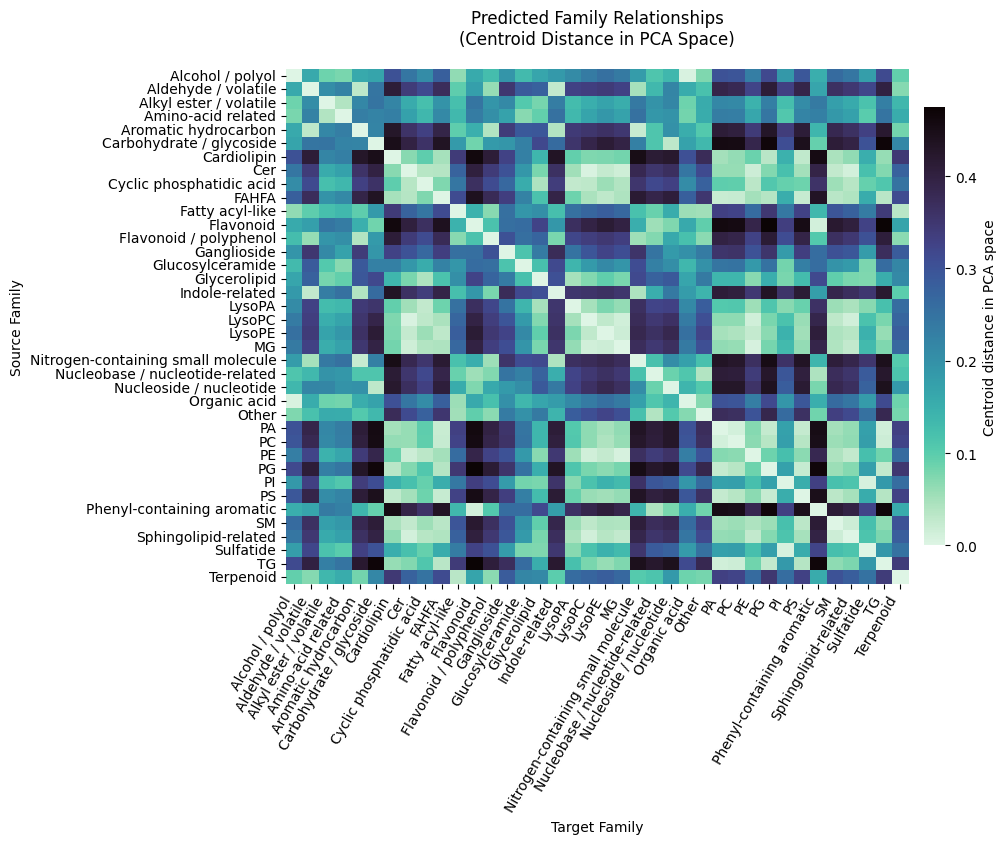

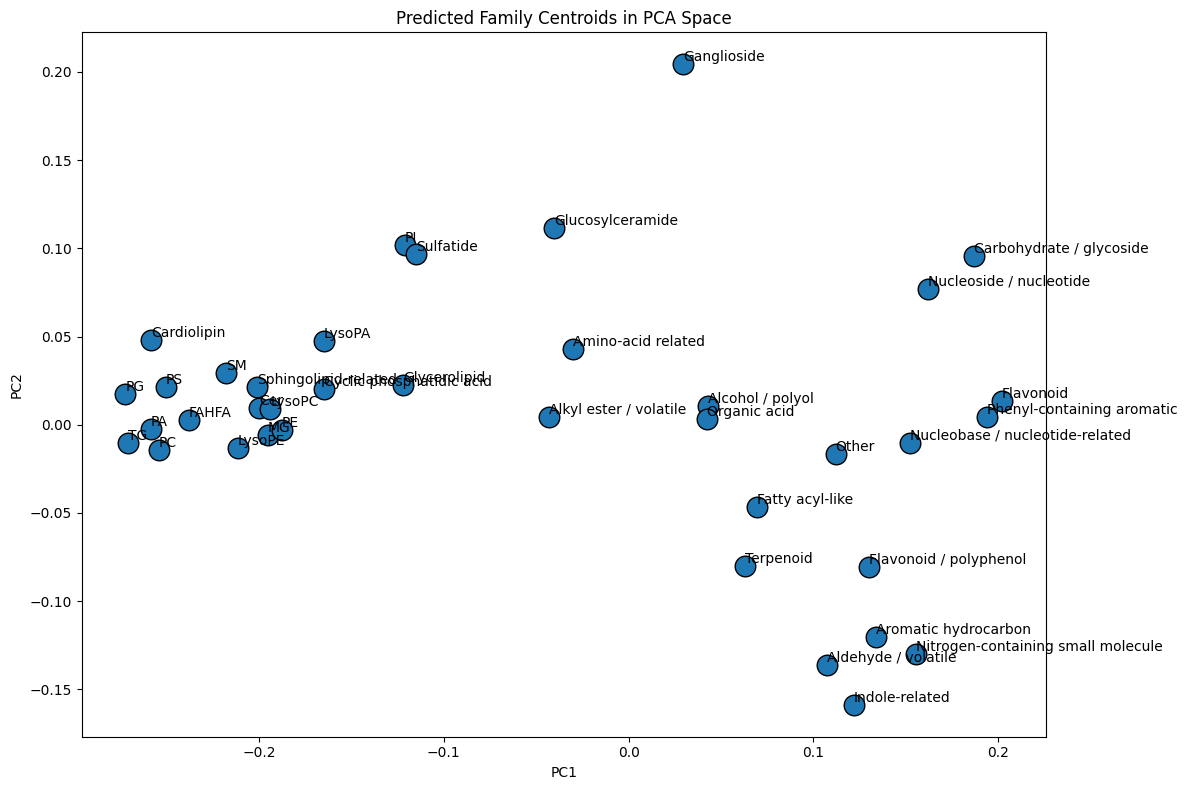

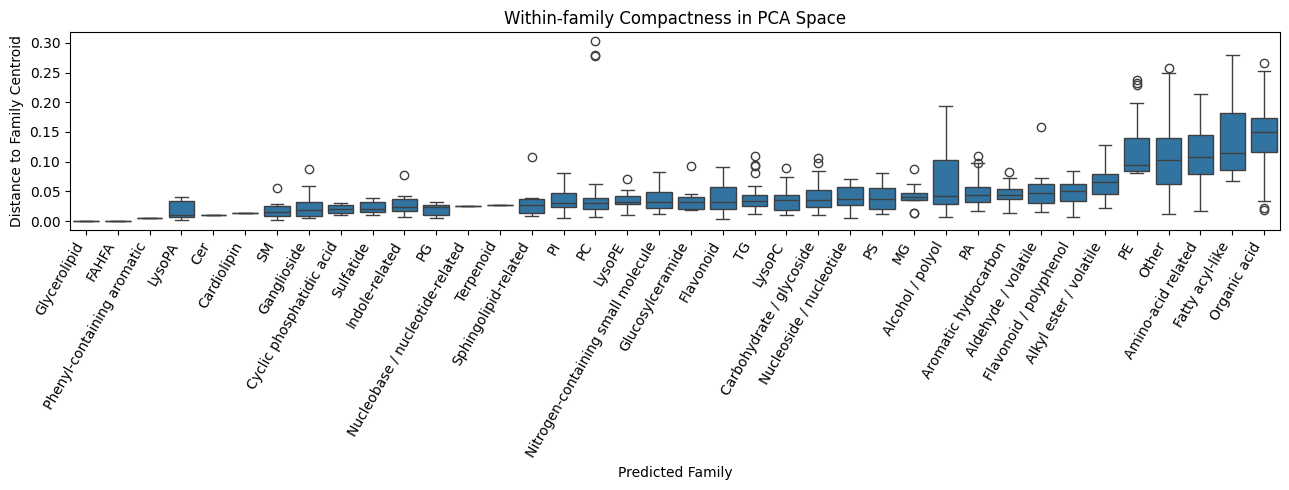

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# FAMILY RELATIONSHIPS FROM PCA COORDINATES
#
# FIXED VERSION:
#   - avoids reset_index name collision
#   - uses pred_family + PC1 + PC2 only
#   - computes family centroids
#   - computes centroid distances
#   - shows clustered heatmap
#   - shows centroid scatter
#   - shows within-family compactness boxplot
# ============================================================


# ------------------------------------------------------------
# COMPUTE FAMILY CENTROIDS IN PCA SPACE
# ------------------------------------------------------------
def compute_family_pca_centroids(
    mol_df,
    family_col="pred_family",
    pc_cols=("PC1", "PC2"),
    min_family_size=1,
):
    df = mol_df.copy()

    for c in [family_col, *pc_cols]:
        if c not in df.columns:
            raise KeyError(f"Required column missing: {c}")

    df = df[df[family_col].notna()].copy()
    df[family_col] = df[family_col].astype(str).str.strip()
    df = df[df[family_col] != ""].copy()

    fam_sizes = df[family_col].value_counts()
    keep_fams = fam_sizes[fam_sizes >= int(min_family_size)].index
    df = df[df[family_col].isin(keep_fams)].copy()

    centroids = (
        df.groupby(family_col)[list(pc_cols)]
        .mean()
        .rename(columns={pc_cols[0]: "centroid_PC1", pc_cols[1]: "centroid_PC2"})
    )

    counts = (
        df[family_col]
        .value_counts()
        .rename("family_size")
        .to_frame()
    )

    centroids = centroids.join(counts, how="left")
    return df, centroids


# ------------------------------------------------------------
# PAIRWISE EUCLIDEAN DISTANCE MATRIX BETWEEN CENTROIDS
# ------------------------------------------------------------
def compute_centroid_distance_matrix(centroids):
    xy = centroids[["centroid_PC1", "centroid_PC2"]].to_numpy(dtype=float)

    diff = xy[:, None, :] - xy[None, :, :]
    dist = np.sqrt((diff ** 2).sum(axis=2))

    dist_df = pd.DataFrame(
        dist,
        index=centroids.index,
        columns=centroids.index,
    )

    # IMPORTANT: avoid identical index/column names causing reset_index issues
    dist_df.index.name = "source_family"
    dist_df.columns.name = "target_family"

    return dist_df


# ------------------------------------------------------------
# EXTRACT TOP CLOSEST FAMILY PAIRS
# ------------------------------------------------------------
def extract_closest_family_pairs(dist_df, top_n=15):
    x = dist_df.copy()
    np.fill_diagonal(x.values, np.nan)

    # avoid index/column name collision by converting manually
    arr = x.to_numpy()
    row_names = x.index.astype(str).tolist()
    col_names = x.columns.astype(str).tolist()

    rows = []
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            if pd.isna(val):
                continue
            rows.append((row_names[i], col_names[j], float(val)))

    pairs = pd.DataFrame(rows, columns=["source_family", "target_family", "distance"])
    pairs = pairs.sort_values("distance", ascending=True).reset_index(drop=True)

    # remove symmetric duplicates
    seen = set()
    keep = []
    for _, row in pairs.iterrows():
        a = str(row["source_family"])
        b = str(row["target_family"])
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        keep.append(row)

    pairs = pd.DataFrame(keep).head(top_n).reset_index(drop=True)
    return pairs


# ------------------------------------------------------------
# PLOT 1: CLUSTERED HEATMAP OF FAMILY-CENTROID DISTANCES
# ------------------------------------------------------------
def plot_family_distance_heatmap(dist_df, figsize=(11, 9)):
    plt.figure(figsize=figsize)

    ax = sns.heatmap(
        dist_df,
        cmap="mako_r",
        square=False,
        linewidths=0.0,   # no cluster/grid lines
        linecolor=None,
        cbar_kws={
            "label": "Centroid distance in PCA space",
            "shrink": 0.85,
            "pad": 0.02,
        },
    )

    ax.set_title(
        "Predicted Family Relationships\n(Centroid Distance in PCA Space)",
        pad=18
    )
    ax.set_xlabel("Target Family")
    ax.set_ylabel("Source Family")

    plt.xticks(rotation=60, ha="right")
    plt.yticks(rotation=0)

    # important: prevents title / legend overlap
    plt.tight_layout(rect=[0, 0, 0.96, 0.95])
    plt.show()

    return ax


# ------------------------------------------------------------
# PLOT 2: FAMILY CENTROIDS OVER PCA SPACE
# ------------------------------------------------------------
def plot_family_centroids_scatter(
    mol_df,
    centroids,
    family_col="pred_family",
    centroid_size=220,
    figsize=(11, 8),
):
    plt.figure(figsize=figsize)

    # ONLY family centroids
    plt.scatter(
        centroids["centroid_PC1"],
        centroids["centroid_PC2"],
        s=centroid_size,   # constant size for all families
        edgecolor="black",
        linewidth=1.0,
        zorder=3,
    )

    for fam, row in centroids.iterrows():
        plt.text(
            row["centroid_PC1"],
            row["centroid_PC2"],
            str(fam),
            fontsize=10,
            ha="left",
            va="bottom",
        )

    plt.title("Predicted Family Centroids in PCA Space")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# PLOT 3: WITHIN-FAMILY COMPACTNESS
# ------------------------------------------------------------
def plot_family_compactness_boxplot(
    mol_df,
    centroids,
    family_col="pred_family",
    figsize=(12, 5),
):
    df = mol_df.copy()

    centroid_lookup = centroids[["centroid_PC1", "centroid_PC2"]].to_dict("index")

    dist_vals = []
    for _, row in df.iterrows():
        fam = str(row[family_col])
        if fam not in centroid_lookup:
            continue

        cx = centroid_lookup[fam]["centroid_PC1"]
        cy = centroid_lookup[fam]["centroid_PC2"]

        d = np.sqrt((row["PC1"] - cx) ** 2 + (row["PC2"] - cy) ** 2)
        dist_vals.append((fam, d))

    compact_df = pd.DataFrame(
        dist_vals,
        columns=["pred_family", "distance_to_family_centroid"]
    )

    order = (
        compact_df.groupby("pred_family")["distance_to_family_centroid"]
        .median()
        .sort_values()
        .index
    )

    plt.figure(figsize=figsize)
    sns.boxplot(
        data=compact_df,
        x="pred_family",
        y="distance_to_family_centroid",
        order=order,
    )
    plt.title("Within-family Compactness in PCA Space")
    plt.xlabel("Predicted Family")
    plt.ylabel("Distance to Family Centroid")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

    return compact_df


# ------------------------------------------------------------
# MAIN RUNNER
# ------------------------------------------------------------
def run_family_relationship_analysis(
    mol_df,
    family_col="pred_family",
    min_family_size=1,
    top_n_pairs=15,
):
    df_use, centroids = compute_family_pca_centroids(
        mol_df=mol_df,
        family_col=family_col,
        pc_cols=("PC1", "PC2"),
        min_family_size=min_family_size,
    )

    dist_df = compute_centroid_distance_matrix(centroids)
    closest_pairs = extract_closest_family_pairs(dist_df, top_n=top_n_pairs)

    heatmap_ax = plot_family_distance_heatmap(dist_df, figsize=(11, 9))
    plot_family_centroids_scatter(df_use, centroids, family_col=family_col, figsize=(12, 8))
    compact_df = plot_family_compactness_boxplot(
        df_use,
        centroids,
        family_col=family_col,
        figsize=(13, 5),
    )

    return {
        "filtered_df": df_use,
        "centroids": centroids,
        "distance_matrix": dist_df,
        "closest_pairs": closest_pairs,
        "compact_df": compact_df,
        "heatmap_ax": heatmap_ax,
    }


# ============================================================
# RUN
# ============================================================
results = run_family_relationship_analysis(
    mol_df_plot,
    family_col="pred_family",
    min_family_size=1,
    top_n_pairs=15,
)

C:\Users\eozturk7\AppData\Local\Temp\ipykernel_210948\3220939959.py:157: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




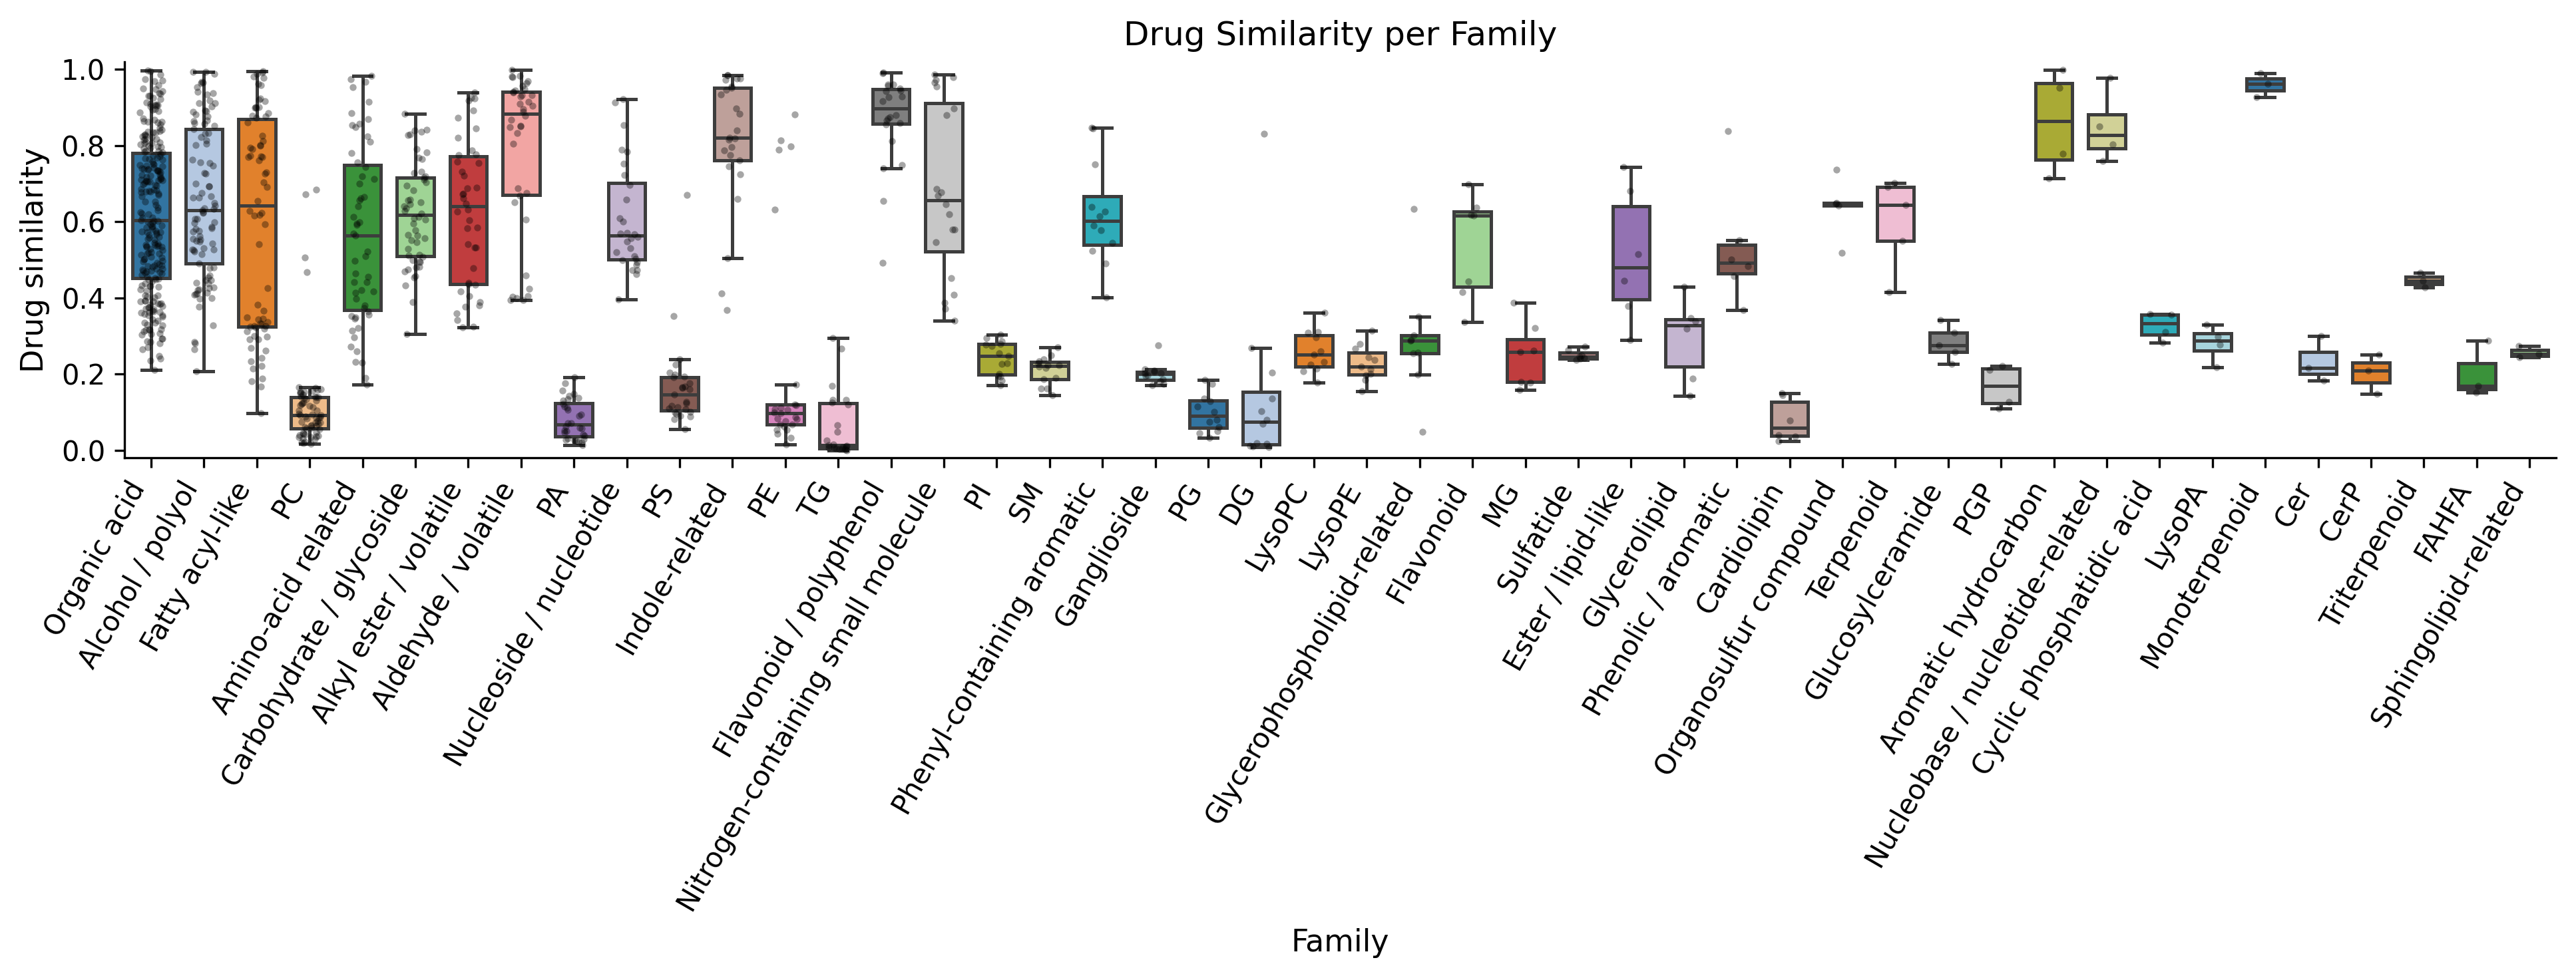

In [19]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# DRUG SIMILARITY
# ============================================================

def compute_drug_similarity(
    mol_df,
    k=3,
    use_cols=("PC1", "PC2"),
    score_mode="rank",   # "rank", "minmax", "raw"
):
    df = mol_df.copy()

    needed = list(use_cols) + ["has_drug_match"]
    for c in needed:
        if c not in df.columns:
            raise KeyError(f"Missing required column: {c}")

    df = df.dropna(subset=list(use_cols)).copy()
    df["has_drug_match"] = df["has_drug_match"].fillna(False).astype(bool)

    X = df[list(use_cols)].to_numpy(dtype=float)
    drug_mask = df["has_drug_match"].to_numpy()

    n_drugs = int(drug_mask.sum())
    if n_drugs == 0:
        raise ValueError("No drug-matched molecules found.")
    if n_drugs < k:
        raise ValueError(f"Not enough drug molecules for k={k}. Found only {n_drugs}.")

    nbrs = NearestNeighbors(n_neighbors=k).fit(X[drug_mask])
    dists, _ = nbrs.kneighbors(X)

    df["nearest_drug_dist"] = dists[:, 0]
    df["mean_k_drug_dist"] = dists.mean(axis=1)

    df["drug_similarity_raw"] = 1.0 / (1.0 + df["mean_k_drug_dist"])
    mean_dist = df["mean_k_drug_dist"].values

    if score_mode == "raw":
        df["drug_similarity"] = df["drug_similarity_raw"]

    elif score_mode == "minmax":
        dmin = np.min(mean_dist)
        dmax = np.max(mean_dist)
        if dmax == dmin:
            sim = np.ones_like(mean_dist)
        else:
            sim = 1.0 - (mean_dist - dmin) / (dmax - dmin)
        df["drug_similarity"] = sim

    elif score_mode == "rank":
        rank_pct = pd.Series(mean_dist).rank(method="average", pct=True, ascending=True).values
        df["drug_similarity"] = 1.0 - rank_pct

    else:
        raise ValueError("score_mode must be one of: 'rank', 'minmax', 'raw'")

    return df


# ============================================================
# FAMILY PALETTE
# ============================================================

def make_family_palette(df, family_col="pred_family", max_groups=20):
    fam = df[family_col].fillna("Unknown").astype(str).replace("", "Unknown")
    order = fam.value_counts().index.tolist()

    cmap = plt.get_cmap("tab20")
    palette = {}
    for i, g in enumerate(order):
        palette[g] = cmap(i % max_groups)

    return palette, order


# ============================================================
# SUMMARY STATISTICS
# ============================================================

def summarize_drug_similarity(df, family_col="pred_family"):
    stats = (
        df.groupby(family_col)["drug_similarity"]
        .agg(
            n="count",
            mean="mean",
            std="std",
            median="median",
            min="min",
            max="max",
        )
        .reset_index()
    )

    q1 = df.groupby(family_col)["drug_similarity"].quantile(0.25).reset_index(name="q1")
    q3 = df.groupby(family_col)["drug_similarity"].quantile(0.75).reset_index(name="q3")

    stats = stats.merge(q1, on=family_col).merge(q3, on=family_col)
    stats["iqr"] = stats["q3"] - stats["q1"]
    stats["sem"] = stats["std"] / np.sqrt(stats["n"])

    stats = stats.sort_values("median", ascending=False).reset_index(drop=True)
    return stats


# ============================================================
# BOXPLOT OF DRUG SIMILARITY BY FAMILY
# ============================================================

def plot_drug_similarity_by_family(
    mol_df,
    family_col="pred_family",
    k=3,
    use_cols=("PC1", "PC2"),
    score_mode="rank",
    figsize=(13, 5),
    show_points=True,
    only_non_drugs=False,
    min_family_size=3,
):
    df = compute_drug_similarity(
        mol_df,
        k=k,
        use_cols=use_cols,
        score_mode=score_mode,
    ).copy()

    if family_col not in df.columns:
        raise KeyError(f"Missing required family column: {family_col}")

    df[family_col] = df[family_col].fillna("Unknown").astype(str).replace("", "Unknown")

    if only_non_drugs:
        df = df[~df["has_drug_match"]].copy()

    fam_counts = df[family_col].value_counts()
    valid_fams = fam_counts[fam_counts >= min_family_size].index
    df = df[df[family_col].isin(valid_fams)].copy()

    palette, full_order = make_family_palette(df, family_col=family_col)
    order = [f for f in full_order if f in df[family_col].unique()]

    # summary statistics
    stats_df = summarize_drug_similarity(df, family_col=family_col)
    stats_df[family_col] = pd.Categorical(stats_df[family_col], categories=order, ordered=True)
    stats_df = stats_df.sort_values(family_col).reset_index(drop=True)

    plt.figure(figsize=figsize)

    ax = sns.boxplot(
        data=df,
        x=family_col,
        y="drug_similarity",
        order=order,
        palette=palette,
        width=0.7,
        showfliers=False,
        linewidth=1.2,
    )

    if show_points:
        sns.stripplot(
            data=df,
            x=family_col,
            y="drug_similarity",
            order=order,
            color="black",
            alpha=0.35,
            size=2.5,
            jitter=0.22,
        )

    plt.xticks(rotation=60, ha="right")
    plt.title("Drug Similarity per Family")
    plt.ylabel("Drug similarity")
    plt.xlabel("Family")

    if score_mode == "rank":
        plt.ylim(-0.02, 1.02)

    sns.despine()
    plt.tight_layout()
    plt.show()

    return df, stats_df


# ============================================================
# RUN
# ============================================================

df_sim, stats_sim = plot_drug_similarity_by_family(
    mol_df_plot,
    family_col="pred_chemical_family",
    k=3,
    score_mode="rank",
)

In [20]:
stats_sim

,pred_chemical_family,n,mean,std,median,min,max,q1,q3,iqr,sem
0,Organic acid,247,0.615040,0.200826,0.604525,0.209955,0.997285,0.451131,0.780543,0.329412,0.012778
1,Alcohol / polyol,97,0.651770,0.201756,0.630769,0.207240,0.994570,0.489593,0.843439,0.353846,0.020485
2,Fatty acyl-like,70,0.596884,0.281018,0.642081,0.096833,0.995475,0.324434,0.870136,0.545701,0.033588
3,PC,65,0.120738,0.129372,0.091403,0.016290,0.685068,0.056109,0.139367,0.083258,0.016047
4,Amino-acid related,55,0.565397,0.232176,0.563801,0.172851,0.982805,0.368326,0.749321,0.380995,0.031307
5,Carbohydrate / glycoside,52,0.620536,0.133590,0.617647,0.304977,0.883258,0.510407,0.716516,0.206109,0.018526
6,Alkyl ester / volatile,42,0.624154,0.190054,0.639819,0.323077,0.939367,0.436878,0.771041,0.334163,0.029326
7,Aldehyde / volatile,38,0.790141,0.207121,0.884163,0.393665,0.999095,0.670588,0.940950,0.270362,0.033599
8,PA,32,0.081024,0.051654,0.066516,0.013575,0.191855,0.035520,0.123529,0.088009,0.009131
9,Nucleoside / nucleotide,28,0.607789,0.142921,0.563348,0.395475,0.922172,0.501357,0.702715,0.201357,0.027010


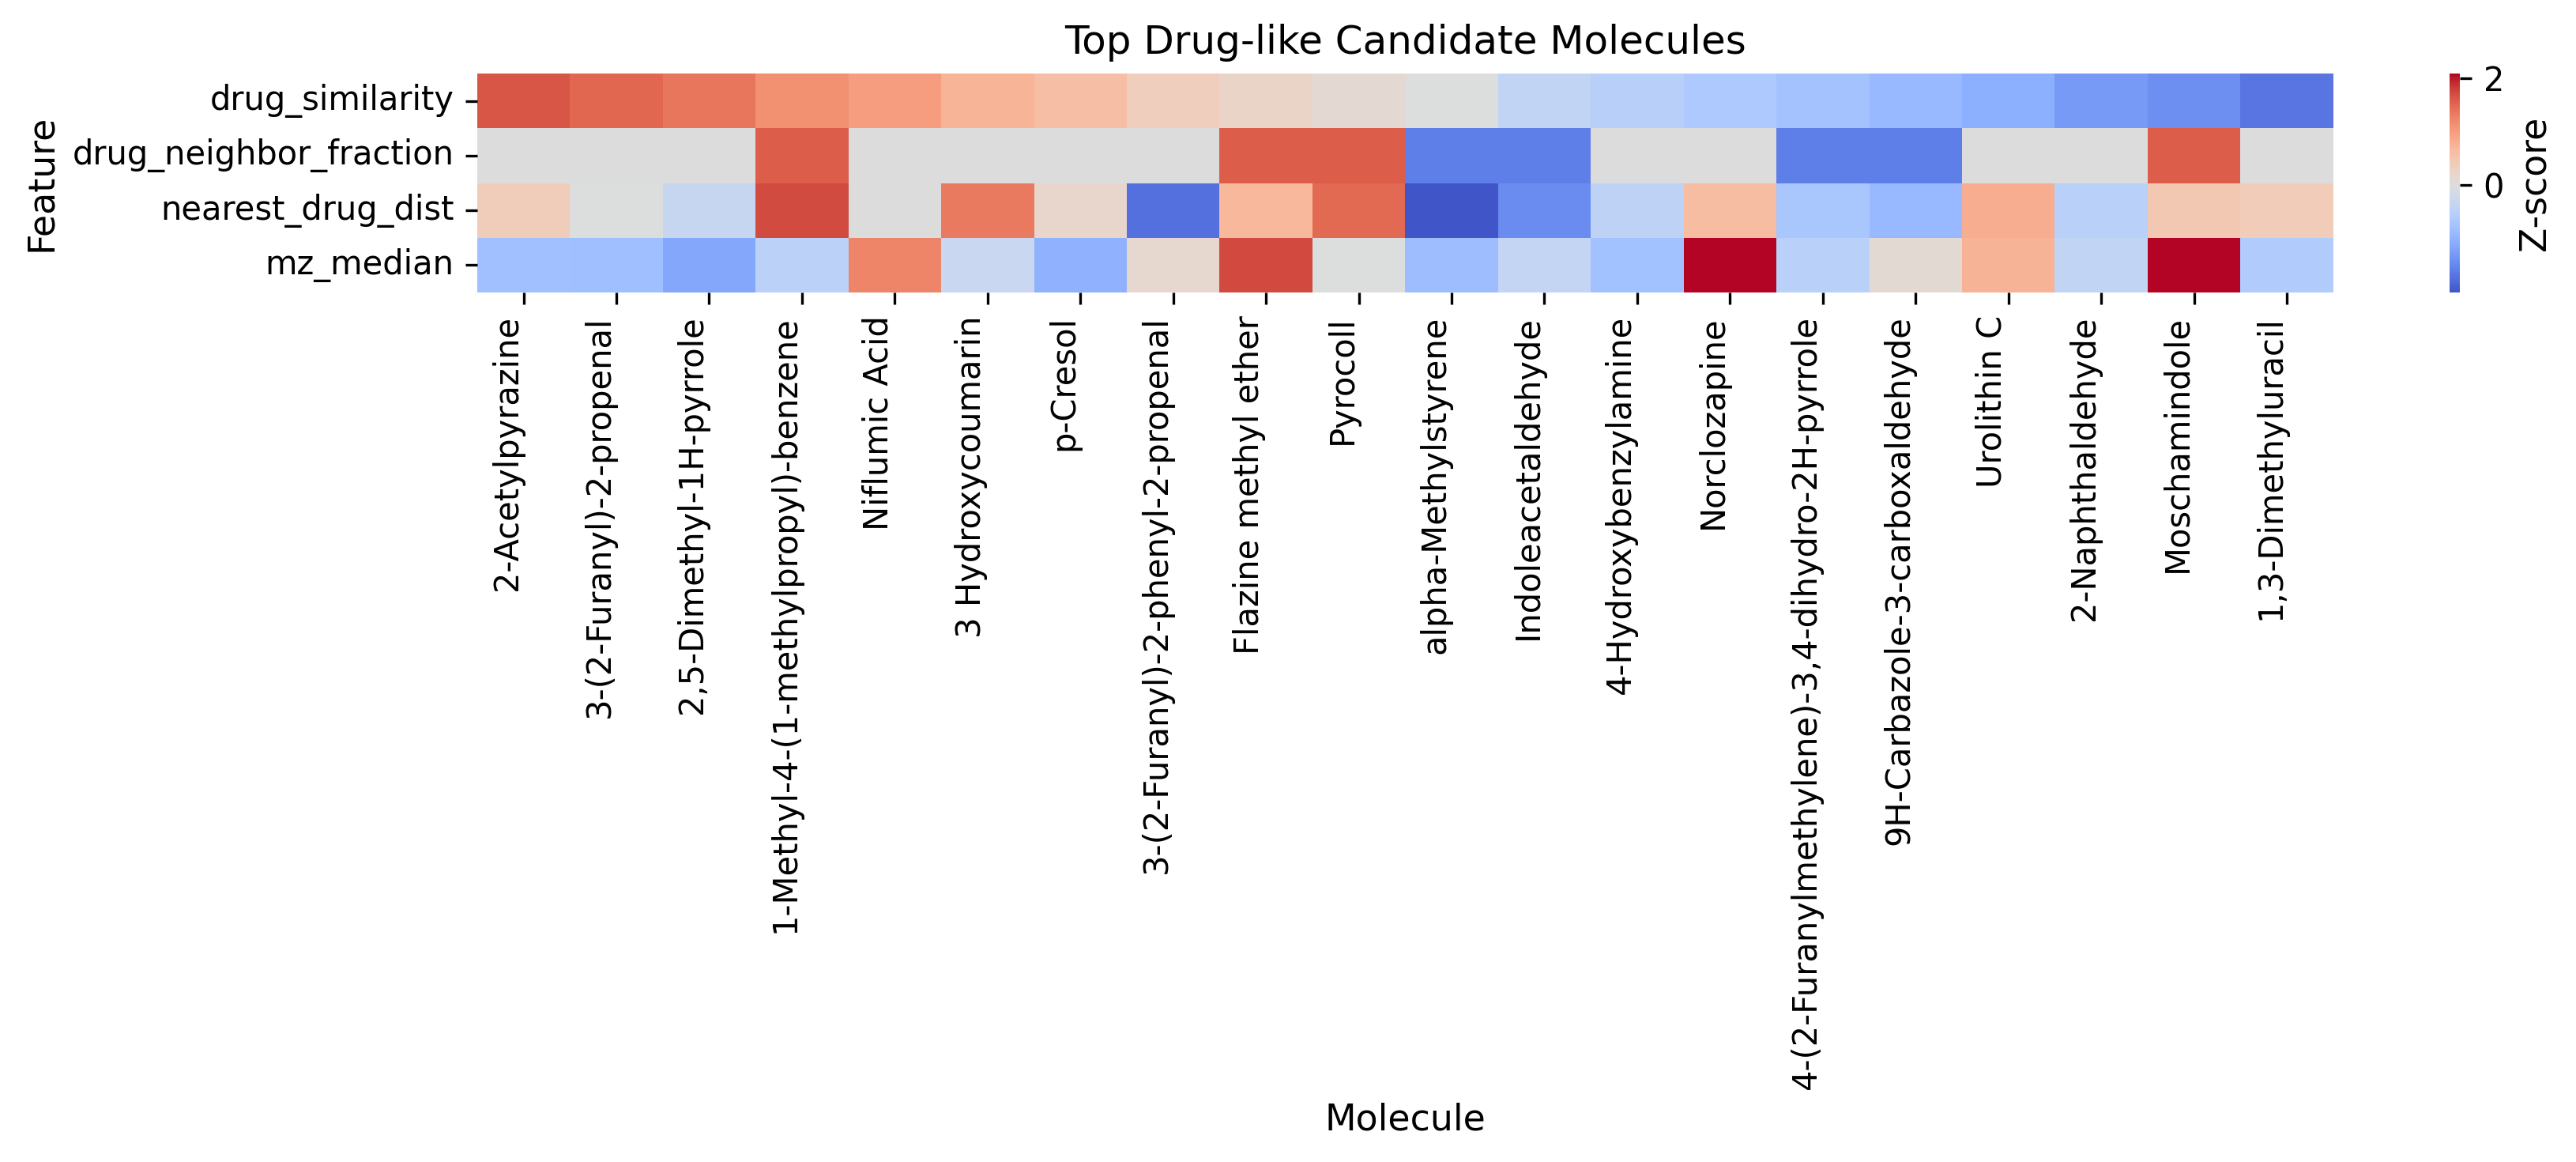

,molecule_name,drug_similarity,drug_neighbor_fraction,nearest_drug_dist,mz_median
115,2-Acetylpyrazine,0.998190,0.2,0.004157,123.055267
156,3-(2-Furanyl)-2-propenal,0.997285,0.2,0.005026,121.029465
106,"2,5-Dimethyl-1H-pyrrole",0.996380,0.2,0.005773,96.080757
70,1-Methyl-4-(1-methylpropyl)-benzene,0.994570,0.4,0.001133,149.132431
702,Niflumic Acid,0.993665,0.2,0.005007,283.068848
144,3 Hydroxycoumarin,0.991855,0.2,0.001956,163.038956
1092,p-Cresol,0.990950,0.2,0.004554,107.050201
155,3-(2-Furanyl)-2-phenyl-2-propenal,0.989140,0.2,0.008933,197.060799
466,Flazine methyl ether,0.988235,0.4,0.003443,321.088043
947,Pyrocoll,0.987330,0.4,0.001615,185.035614


In [31]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# DRUG-LIKENESS SCORING
# ============================================================

def compute_drug_likeness(
    mol_df,
    k=5,
    use_cols=("PC1", "PC2"),
    score_mode="rank",  # "rank", "minmax", "raw"
):
    df = mol_df.copy()

    required_cols = list(use_cols) + ["has_drug_match"]
    for c in required_cols:
        if c not in df.columns:
            raise KeyError(f"Missing required column: {c}")

    df = df.dropna(subset=list(use_cols)).copy()

    X = df[list(use_cols)].values.astype(float)
    drug_mask = df["has_drug_match"].fillna(False).astype(bool).values

    n_drugs = int(drug_mask.sum())
    if n_drugs == 0:
        raise ValueError("No drug molecules found.")
    if n_drugs < k:
        raise ValueError(f"Not enough drug molecules for k={k}. Found only {n_drugs}.")

    # fit only on known drugs
    drug_X = X[drug_mask]
    nbrs = NearestNeighbors(n_neighbors=k).fit(drug_X)
    dists, _ = nbrs.kneighbors(X)

    df["nearest_drug_dist"] = dists[:, 0]
    df["mean_k_drug_dist"] = dists.mean(axis=1)

    # original compressed similarity
    df["drug_similarity_raw"] = 1.0 / (1.0 + df["mean_k_drug_dist"])

    # --------------------------------------------------------
    # better 0-1 scaling
    # --------------------------------------------------------
    mean_dist = df["mean_k_drug_dist"].values

    if score_mode == "raw":
        df["drug_similarity"] = df["drug_similarity_raw"]

    elif score_mode == "minmax":
        dmin = np.min(mean_dist)
        dmax = np.max(mean_dist)
        if dmax == dmin:
            sim = np.ones_like(mean_dist)
        else:
            sim = 1.0 - (mean_dist - dmin) / (dmax - dmin)
        df["drug_similarity"] = sim

    elif score_mode == "rank":
        # closest distance => highest score
        rank_pct = pd.Series(mean_dist).rank(method="average", pct=True, ascending=True).values
        df["drug_similarity"] = 1.0 - rank_pct

    else:
        raise ValueError("score_mode must be one of: 'rank', 'minmax', 'raw'")

    return df


# ============================================================
# DRUG NEIGHBOR FRACTION
# ============================================================

def compute_drug_neighbor_fraction(df, k=5, use_cols=("PC1", "PC2"), include_self=False):
    df = df.copy()

    required_cols = list(use_cols) + ["has_drug_match"]
    for c in required_cols:
        if c not in df.columns:
            raise KeyError(f"Missing required column: {c}")

    X = df[list(use_cols)].values.astype(float)
    drug_mask = df["has_drug_match"].fillna(False).astype(bool).values

    n_neighbors = k + 1 if include_self else k
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(X)
    _, idxs = nbrs.kneighbors(X)

    frac = []
    for i, neighbors in enumerate(idxs):
        neigh = neighbors
        if include_self:
            neigh = neigh[neigh != i]
            neigh = neigh[:k]

        if len(neigh) == 0:
            frac.append(np.nan)
        else:
            frac.append(drug_mask[neigh].mean())

    df["drug_neighbor_fraction"] = frac
    return df


# ============================================================
# CANDIDATE HEATMAP
# ============================================================

def plot_candidate_heatmap(candidates):
    df = candidates.copy()

    num_cols = [
        "drug_similarity",
        "drug_neighbor_fraction",
        "nearest_drug_dist",
        "mz_median",
    ]

    existing_cols = [c for c in num_cols if c in df.columns]
    X = df[existing_cols].copy()

    # invert distance for interpretation (higher = better)
    if "nearest_drug_dist" in X.columns:
        X["nearest_drug_dist"] = -X["nearest_drug_dist"]

    # z-score normalize
    X_scaled = (X - X.mean()) / (X.std(ddof=0) + 1e-8)

    # -------------------------------
    # FLIP AXES
    # -------------------------------
    X_scaled = X_scaled.T   # transpose

    X_scaled.columns = df["molecule_name"]
    X_scaled.index.name = "Features"

    plt.figure(figsize=(12, 5))

    sns.heatmap(
        X_scaled,
        cmap="coolwarm",
        center=0,
        cbar_kws={"label": "Z-score"},
    )

    plt.xticks(rotation=90, ha="right")
    plt.yticks(rotation=0)

    plt.title("Top Drug-like Candidate Molecules")
    plt.xlabel("Molecule")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN
# ============================================================

df_dl = compute_drug_likeness(
    mol_df_plot,
    k=5,
    use_cols=("PC1", "PC2"),
    score_mode="rank",   # recommended
)

df_dl = compute_drug_neighbor_fraction(
    df_dl,
    k=5,
    use_cols=("PC1", "PC2"),
    include_self=False,
)

# do not rank actual drugs as candidates
candidates = (
    df_dl[df_dl["has_drug_match"] == False]
    .sort_values(
        ["drug_similarity", "drug_neighbor_fraction"],
        ascending=False
    )
    .head(20)
)

plot_candidate_heatmap(candidates)
candidates[['molecule_name','drug_similarity', 'drug_neighbor_fraction', 'nearest_drug_dist', 'mz_median']]

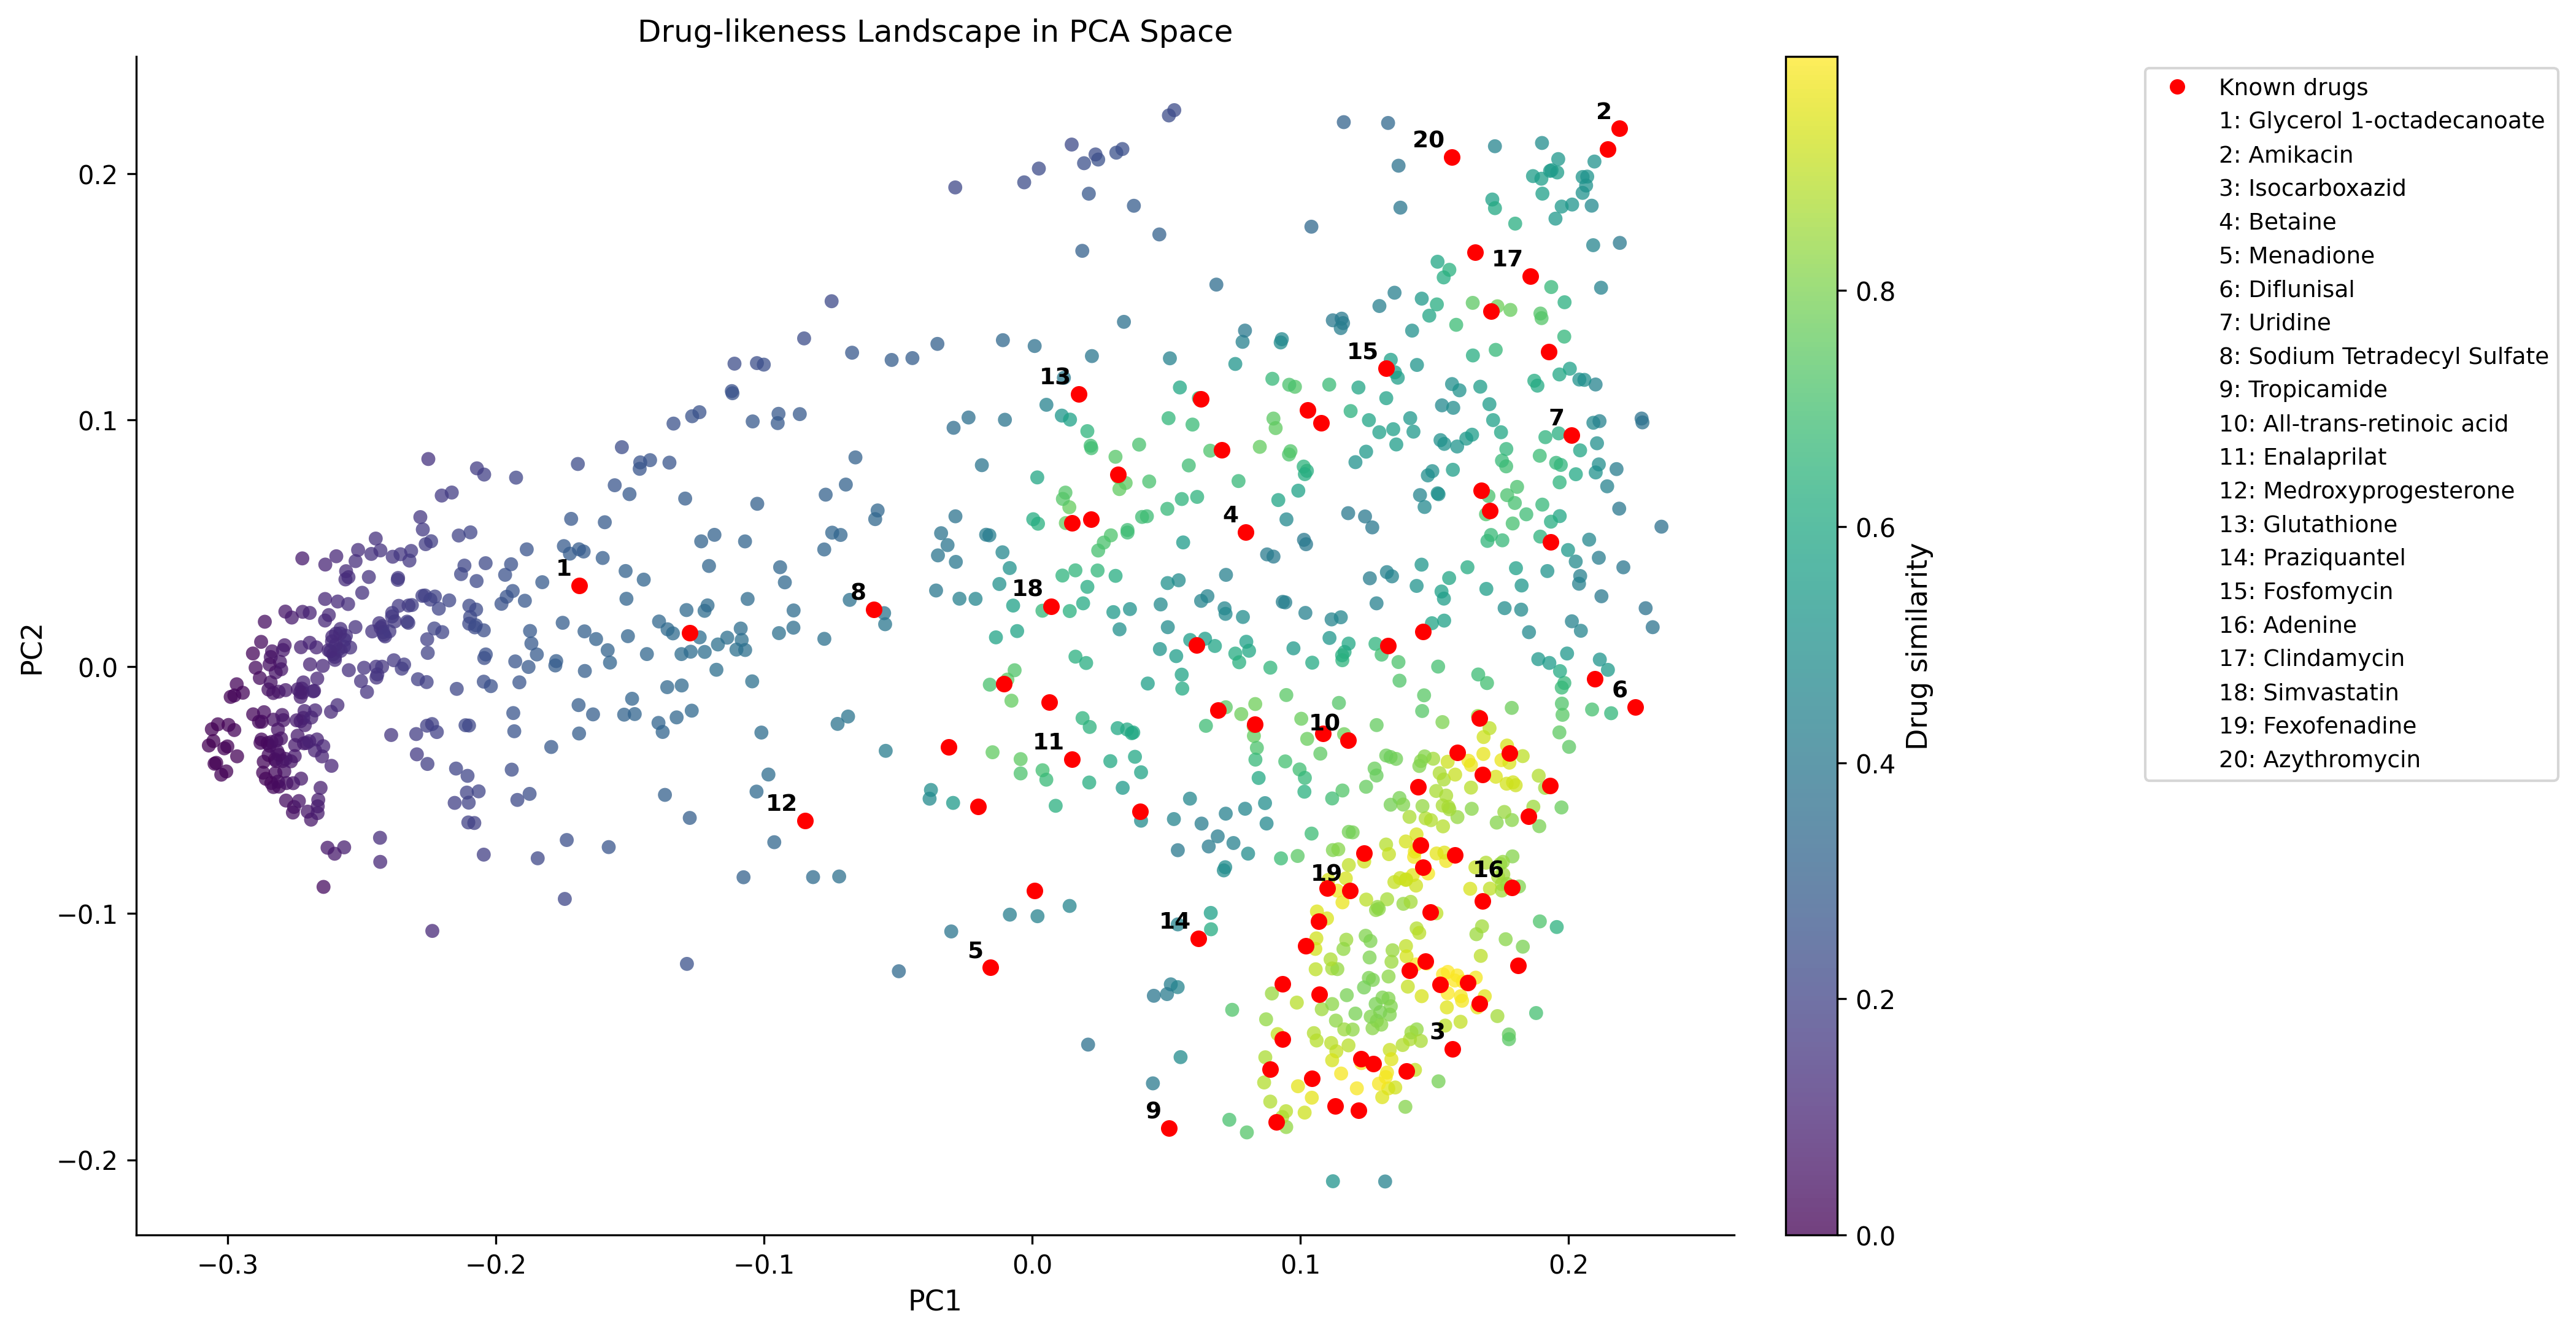


=== Annotated Drugs ===
 label_id             molecule_name
        1  Glycerol 1-octadecanoate
        2                  Amikacin
        3             Isocarboxazid
        4                   Betaine
        5                 Menadione
        6                Diflunisal
        7                   Uridine
        8 Sodium Tetradecyl Sulfate
        9               Tropicamide
       10   All-trans-retinoic acid
       11               Enalaprilat
       12       Medroxyprogesterone
       13               Glutathione
       14              Praziquantel
       15                Fosfomycin
       16                   Adenine
       17               Clindamycin
       18               Simvastatin
       19              Fexofenadine
       20              Azythromycin


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_drug_likeness_heatmap_with_numbered_drugs(
    df,
    x_col="PC1",
    y_col="PC2",
    score_col="drug_similarity",
    drug_col="has_drug_match",
    name_col="molecule_name",
    annotate_top_drugs=15,
    figsize_main=(14, 8),
    cmap="viridis",
    base_size=30,
    drug_size=42,
    title="Drug-likeness Landscape in PCA Space",
    label_dx_frac=0.005,
    label_dy_frac=0.005,
    legend_fontsize=9,
):
    plot_df = df.copy()

    needed = [x_col, y_col, score_col, drug_col, name_col]
    for c in needed:
        if c not in plot_df.columns:
            raise KeyError(f"Missing required column: {c}")

    plot_df = plot_df.dropna(subset=[x_col, y_col, score_col]).copy()
    plot_df[drug_col] = plot_df[drug_col].fillna(False).astype(bool)

    non_drug_df = plot_df[~plot_df[drug_col]].copy()
    drug_df = plot_df[plot_df[drug_col]].copy()

    # ---------------------------------------------------------
    # SCATTERED DRUG SELECTION
    # ---------------------------------------------------------
    def choose_scattered_points(df_points, n_pick, x_col, y_col):
        if len(df_points) == 0:
            return df_points.copy()

        n_pick = min(int(n_pick), len(df_points))
        coords = df_points[[x_col, y_col]].to_numpy(dtype=float)

        centroid = coords.mean(axis=0)
        d0 = np.sum((coords - centroid) ** 2, axis=1)
        chosen = [int(np.argmax(d0))]

        min_d2 = np.sum((coords - coords[chosen[0]]) ** 2, axis=1)

        while len(chosen) < n_pick:
            next_idx = int(np.argmax(min_d2))
            if next_idx in chosen:
                break
            chosen.append(next_idx)
            d2_new = np.sum((coords - coords[next_idx]) ** 2, axis=1)
            min_d2 = np.minimum(min_d2, d2_new)

        return df_points.iloc[chosen].copy().reset_index(drop=True)

    label_df = choose_scattered_points(
        drug_df,
        n_pick=annotate_top_drugs,
        x_col=x_col,
        y_col=y_col,
    )
    label_df["label_id"] = np.arange(1, len(label_df) + 1)

    # ---------------------------------------------------------
    # FIGURE + MANUAL LAYOUT CONTROL
    # ---------------------------------------------------------
    fig = plt.figure(figsize=figsize_main)

    # main axis
    ax = fig.add_axes([0.08, 0.1, 0.62, 0.8])  # left, bottom, width, height

    # colorbar axis
    cax = fig.add_axes([0.72, 0.1, 0.02, 0.8])

    # ---------------------------------------------------------
    # PLOT
    # ---------------------------------------------------------
    sc = ax.scatter(
        non_drug_df[x_col],
        non_drug_df[y_col],
        c=non_drug_df[score_col],
        cmap=cmap,
        s=base_size,
        alpha=0.75,
        linewidths=0,
        zorder=1,
    )

    ax.scatter(
        drug_df[x_col],
        drug_df[y_col],
        s=drug_size,
        c="red",
        alpha=1.0,
        linewidths=0,
        zorder=4,
    )

    # ---------------------------------------------------------
    # LABELS
    # ---------------------------------------------------------
    x_span = plot_df[x_col].max() - plot_df[x_col].min()
    y_span = plot_df[y_col].max() - plot_df[y_col].min()

    dx = label_dx_frac * x_span
    dy = label_dy_frac * y_span

    for _, row in label_df.iterrows():
        ax.text(
            row[x_col] - dx,
            row[y_col] + dy,
            str(int(row["label_id"])),
            fontsize=9,
            fontweight="bold",
            ha="right",
            va="bottom",
            color="black",
            zorder=6,
        )

    # ---------------------------------------------------------
    # COLORBAR (fixed position)
    # ---------------------------------------------------------
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label("Drug similarity")

    # ---------------------------------------------------------
    # LEGEND (separate column, no overlap)
    # ---------------------------------------------------------
    legend_handles = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor="red", markersize=7,
               label="Known drugs")
    ]

    for _, row in label_df.iterrows():
        legend_handles.append(
            Line2D([0], [0], linestyle="none",
                   label=f'{int(row["label_id"])}: {row[name_col]}')
        )

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.25, 1.0),  # pushed further right
        frameon=True,
        fontsize=legend_fontsize,
    )

    # ---------------------------------------------------------
    # FINAL
    # ---------------------------------------------------------
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    plt.show()

    print("\n=== Annotated Drugs ===")
    print(label_df[["label_id", name_col]].to_string(index=False))

    return label_df


# RUN
label_df = plot_drug_likeness_heatmap_with_numbered_drugs(
    df_dl,
    annotate_top_drugs=20,
)